<a href="https://colab.research.google.com/github/SaanchitaV/RagAllied-SARAGA-Dataset/blob/main/RagAllied.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing the mirdata, compiam and pandas libraries

*   ***mirdata*** - a general library for MIR (music information retrieval) datasets, though It's not Indian-music-specific; it's a standardized loader for dozens of research datasets (Saraga among them). It's whole job is to handle the annoying parts: downloading the data, validating if it's complete and uncorrupted (checksums), and giving a uniform Python interface to access raga, artist, pitch tracks, tonic, etc. as object attributes instead of parsing raw files and folder structures yourself. It exists because every MIR dataset ships its annotations in its own messy format, and mirdata normalizes that. For your census, mirdata is what loads Saraga and exposes the metadata fields.

*   ***compiam*** -  Computational Indian Art Music. This one is domain-specific, built by the MTG/CompMusic group (Serra's lab in Barcelona—the same people who made Saraga). It's a toolkit of methods for Carnatic and Hindustani music: tonic identification, predominant-melody/pitch extraction, raga recognition, rhythm/sama analysis, and it bundles access to the relevant datasets. Where mirdata gives you the data, compiam gives you the analysis tools tuned for this music specifically—including baseline implementations you'll want to compare against (e.g. their tonic-identification methods, which matter for your normalization step)



In [1]:
!pip install mirdata compiam pandas

Saraga Census
=============================================================
Purpose: audit the Saraga Carnatic dataset BEFORE any modeling, so you know
exactly what raga / artist / annotation depth you actually have. Every design
decision downstream (full learned retrieval vs. transition-vector floor,
first- vs second-order transitions, which allied pairs are evaluable) is
decided by the numbers this produces.

Run this in Google Colab (the dataset download is large and needs network).

PASS 1  -> raga inventory + per-raga recording/artist counts   (no pair list needed)
PASS 2  -> allied-pair depth overlay                           (fill in AFTER pass 1)

Author scaffold: structured for Saanchita's swara-retrieval / allied-raga IR project.

In [2]:
!pip install -q kagglehub

---


Downloading dataset directly from Kaggle to - /root/.cache/kagglehub/datasets

---

In [2]:
import kagglehub

path = kagglehub.dataset_download("desolationofsmaug/saraga-carnatic-music-dataset")
print("Path to dataset files:", path)

100%|██████████| 3.79G/3.79G [00:46<00:00, 87.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/desolationofsmaug/saraga-carnatic-music-dataset/versions/1




---
Checking how data is stored inside
the dataset - folder structure


---



In [3]:
import os

for root, dirs, files in os.walk(path):
    depth = root[len(path):].count(os.sep)
    if depth <= 2:
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root)}/")
        for f in files[:5]:
            print(f"{indent}  {f}")
        if len(files) > 5:
            print(f"{indent}  ... (+{len(files)-5} more files)")

1/
  carnatic/
    58/
      S Sundar - Geetha Vaadya Natana.ctonic.txt
      S Sundar - Geetha Vaadya Natana.mp3
      S Sundar - Geetha Vaadya Natana.tempo-manual.txt
      S Sundar - Geetha Vaadya Natana.json
      S Sundar - Geetha Vaadya Natana.pitch.txt
      ... (+1 more files)
    27/
      Sanjay Subrahmanyan - Chalamelara Saketha Rama.tempo-manual.txt
      Sanjay Subrahmanyan - Chalamelara Saketha Rama.mp3
      Sanjay Subrahmanyan - Chalamelara Saketha Rama.mphrases-manual.txt
      Sanjay Subrahmanyan - Chalamelara Saketha Rama.json
      Sanjay Subrahmanyan - Chalamelara Saketha Rama.pitch.txt
      ... (+5 more files)
    118/
      Kanakadurga Venkatesh - Neevada Negana.mp3
      Kanakadurga Venkatesh - Neevada Negana.pitch.txt
      Kanakadurga Venkatesh - Neevada Negana.ctonic.txt
      Kanakadurga Venkatesh - Neevada Negana.sama-manual.txt
      Kanakadurga Venkatesh - Neevada Negana.json
    15/
      Sanjay Subrahmanyan - Paarengum.sama-manual.txt
      Sanjay Subr

In [4]:
import json, os, glob

# find all json metadata files under the dataset
json_files = glob.glob(os.path.join(path, "**", "*.json"), recursive=True)
print(f"Found {len(json_files)} JSON metadata files\n")

# print the full content of one
with open(json_files[0]) as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2)[:2500])

Found 197 JSON metadata files

{
  "raaga": [
    {
      "uuid": "307630ce-768a-495c-a280-0b715f8904fd",
      "name": "N\u0101\u1e6dakapriya"
    }
  ],
  "form": [
    {
      "name": "Kriti"
    }
  ],
  "title": "Geetha Vaadya Natana",
  "work": [
    {
      "mbid": "2a106641-5c20-4271-a1f6-c01b60d01e37",
      "title": "Geetha Vaadya Natana"
    }
  ],
  "length": 2961000,
  "taala": [
    {
      "uuid": "c788c38a-b53a-48cb-b7bf-d11769260c4d",
      "name": "\u0100di"
    }
  ],
  "album_artists": [
    {
      "mbid": "e4b8f84f-e2ef-4398-969f-538649ffa15d",
      "name": "S Sundar"
    }
  ],
  "mbid": "cec6de46-c717-45b3-826f-58de5b935497",
  "artists": [
    {
      "instrument": {
        "mbid": "d92884b7-ee0c-46d5-96f3-918196ba8c5b",
        "name": "Voice"
      },
      "attributes": "additional",
      "lead": false,
      "artist": {
        "mbid": "1b654b28-7cf0-493c-84a3-132c68d73ac2",
        "name": "J.B. Keerthana"
      }
    },
    {
      "instrument": {
    

In [5]:
import glob, os

# what did kagglehub actually return?
print("path variable:", path if 'path' in dir() else "NOT DEFINED")

# does the hardcoded path exist?
dp = "/kaggle/input/saraga-carnatic-music-dataset"
print("hardcoded exists?", os.path.exists(dp))

# find json files from BOTH candidate roots
for root in [path if 'path' in dir() else None, dp]:
    if root and os.path.exists(root):
        n = len(glob.glob(os.path.join(root, "**", "*.json"), recursive=True))
        print(f"  {root} -> {n} json files")

path variable: /root/.cache/kagglehub/datasets/desolationofsmaug/saraga-carnatic-music-dataset/versions/1
hardcoded exists? False
  /root/.cache/kagglehub/datasets/desolationofsmaug/saraga-carnatic-music-dataset/versions/1 -> 197 json files


In [6]:
"""
Saraga Census -- Kaggle-mirror version
=============================================================
Reads Saraga Carnatic directly from the Kaggle dataset
(desolationofsmaug/saraga-carnatic-music-dataset), parsing the per-recording
.json metadata files. No mirdata dependency.

Run AFTER:
    import kagglehub
    path = kagglehub.dataset_download("desolationofsmaug/saraga-carnatic-music-dataset")

Then set DATA_PATH = path (or paste the printed path).

PASS 1 -> raga inventory + per-raga recording/artist counts  (no pair list needed)
PASS 2 -> allied-pair depth overlay                          (fill in AFTER pass 1)
-------------------------------------------------------------
"""

import os
import re
import json
import glob
import unicodedata
from collections import defaultdict

import pandas as pd


# =============================================================
# CONFIG  -- set DATA_PATH to the kagglehub path
# =============================================================
# DATA_PATH = None  # e.g. "/root/.cache/kagglehub/datasets/desolationofsmaug/..."
DATA_PATH = path
OUT_DIR = "/content/census_out"
os.makedirs(OUT_DIR, exist_ok=True)


# =============================================================
# NORMALIZATION
# =============================================================
def normalize_name(s):
    """Strip diacritics so 'Ṣanmukhapriya' == 'Shanmukhapriya'-ish.
    We fold to ASCII and lowercase for grouping, but keep a display version."""
    if not s:
        return "UNKNOWN"
    # NFKD decomposition drops combining marks
    decomposed = unicodedata.normalize("NFKD", s)
    ascii_form = decomposed.encode("ascii", "ignore").decode("ascii")
    ascii_form = ascii_form.strip()
    return ascii_form if ascii_form else s.strip()


def raga_key(name):
    """Grouping key: normalized + lowercased + spaces collapsed."""
    n = normalize_name(name).lower()
    n = re.sub(r"\s+", " ", n).strip()
    return n


# =============================================================
# PARSE ONE RECORDING
# =============================================================
def parse_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    # --- raga ---
    raga_disp = "UNKNOWN"
    raaga = meta.get("raaga") or meta.get("raga")
    if isinstance(raaga, list) and raaga:
        raga_disp = normalize_name(raaga[0].get("name"))
    elif isinstance(raaga, dict):
        raga_disp = normalize_name(raaga.get("name"))

    # --- lead artist: prefer the artist flagged lead==True in `artists`,
    #     fall back to album_artists ---
    lead_artist = None
    artists = meta.get("artists") or []
    for a in artists:
        if a.get("lead") and a.get("artist", {}).get("name"):
            lead_artist = a["artist"]["name"]
            break
    if not lead_artist:
        alb = meta.get("album_artists") or []
        if isinstance(alb, list) and alb:
            lead_artist = alb[0].get("name")
    lead_artist = normalize_name(lead_artist) if lead_artist else "UNKNOWN"

    # --- lead instrument / voice type (useful later, cheap to grab now) ---
    lead_instrument = "UNKNOWN"
    for a in artists:
        if a.get("lead"):
            lead_instrument = (a.get("instrument") or {}).get("name", "UNKNOWN")
            break

    # --- concert / form / taala ---
    def first_name(field):
        v = meta.get(field)
        if isinstance(v, list) and v:
            return normalize_name(v[0].get("name") or v[0].get("title"))
        if isinstance(v, dict):
            return normalize_name(v.get("name") or v.get("title"))
        return "UNKNOWN"

    concert = first_name("concert")
    form = first_name("form")
    taala = first_name("taala")

    # --- annotation coverage: check sibling files in the same folder ---
    folder = os.path.dirname(json_path)
    stem = os.path.splitext(os.path.basename(json_path))[0]
    siblings = os.listdir(folder)
    def has(suffix):
        return any(fn.startswith(stem) and fn.endswith(suffix) for fn in siblings)

    return {
        "track_id": os.path.relpath(folder, DATA_PATH),
        "title": meta.get("title", "UNKNOWN"),
        "raga": raga_disp,
        "raga_key": raga_key(raga_disp),
        "artist": lead_artist,
        "lead_instrument": lead_instrument,
        "concert": concert,
        "form": form,
        "taala": taala,
        "has_tonic": has(".ctonic.txt"),
        "has_pitch": has(".pitch.txt"),
        "has_pitch_vocal": has(".pitch-vocal.txt"),
        "has_phrases": has(".mphrases-manual.txt"),
        "has_sections": has(".sections-manual.txt"),
        "has_mp3": has(".mp3"),
    }


def build_metadata_table():
    assert DATA_PATH, "Set DATA_PATH to the kagglehub download path first."
    json_files = glob.glob(os.path.join(DATA_PATH, "**", "*.json"), recursive=True)
    print(f"Found {len(json_files)} JSON metadata files.")
    rows = []
    for jp in json_files:
        try:
            rows.append(parse_json(jp))
        except Exception as e:
            print(f"  [skip] {jp}: {e}")
    df = pd.DataFrame(rows)
    return df


# =============================================================
# PASS 1  --  RAGA INVENTORY
# =============================================================
def pass1_inventory(df):
    print("\n" + "=" * 60)
    print("PASS 1 : RAGA INVENTORY")
    print("=" * 60)
    print(f"Total recordings: {len(df)}")
    print(f"Distinct ragas:   {df['raga_key'].nunique()}")
    print(f"Distinct artists: {df['artist'].nunique()}")
    print(f"Distinct concerts:{df['concert'].nunique()}")

    per_raga = (
        df.groupby("raga_key")
          .agg(display_name=("raga", "first"),
               recordings=("track_id", "count"),
               artists=("artist", "nunique"),
               concerts=("concert", "nunique"))
          .sort_values("recordings", ascending=False)
    )

    print("\n--- Per-raga depth (all ragas) ---")
    with pd.option_context("display.max_rows", None):
        print(per_raga[["display_name", "recordings", "artists", "concerts"]])

    print("\n--- Annotation coverage ---")
    for col in ["has_tonic", "has_pitch", "has_pitch_vocal",
                "has_phrases", "has_sections", "has_mp3"]:
        print(f"  {col:18s}: {df[col].mean():.1%}")

    learnable = per_raga[(per_raga["artists"] >= 2) & (per_raga["recordings"] >= 3)]
    print(f"\nRagas with >=2 artists & >=3 recordings (learned-path eligible): "
          f"{len(learnable)} of {len(per_raga)}")
    print("\nLearned-eligible ragas:")
    print(learnable[["display_name", "recordings", "artists"]].to_string())

    per_raga.to_csv(os.path.join(OUT_DIR, "per_raga_depth.csv"))
    df.to_csv(os.path.join(OUT_DIR, "recordings_metadata.csv"), index=False)
    print(f"\nSaved: per_raga_depth.csv  and  recordings_metadata.csv")
    print(">>> Use per_raga_depth.csv as your MENU to build the allied-pair list. <<<")
    return per_raga


# =============================================================
# PASS 2  --  ALLIED-PAIR DEPTH  (fill in AFTER pass 1)
# =============================================================
# Use the raga_key spelling (normalized, lowercase) as it appears in
# per_raga_depth.csv's index. Group by why the pair is hard.
ALLIED_PAIRS = [
    # ("bilahari", "sankarabharanam", "scale_identical"),
    # ("saveri",   "gaula",           "same_janaka"),
]


def pass2_allied_pairs(per_raga):
    if not ALLIED_PAIRS:
        print("\n[PASS 2 skipped] ALLIED_PAIRS empty. Fill from per_raga_depth.csv, re-run.")
        return None

    print("\n" + "=" * 60)
    print("PASS 2 : ALLIED-PAIR DEPTH")
    print("=" * 60)

    def depth(rk):
        if rk in per_raga.index:
            r = per_raga.loc[rk]
            return int(r["recordings"]), int(r["artists"])
        return 0, 0

    rows = []
    for a, b, cat in ALLIED_PAIRS:
        ar, aa = depth(a); br, ba = depth(b)
        min_recs, min_art = min(ar, br), min(aa, ba)
        if min_recs == 0:
            status = "MISSING (one side absent)"
        elif min_art >= 2 and min_recs >= 3:
            status = "LEARNED-ELIGIBLE"
        elif min_recs >= 1:
            status = "FLOOR-ONLY"
        else:
            status = "UNKNOWN"
        rows.append(dict(raga_A=a, recs_A=ar, artists_A=aa,
                         raga_B=b, recs_B=br, artists_B=ba,
                         category=cat, min_recs=min_recs,
                         min_artists=min_art, status=status))

    pair_df = pd.DataFrame(rows).sort_values(["category", "min_artists"],
                                             ascending=[True, False])
    print(pair_df.to_string(index=False))
    pair_df.to_csv(os.path.join(OUT_DIR, "allied_pair_depth.csv"), index=False)
    print(f"\nSaved: allied_pair_depth.csv")
    print(">>> Decides: full learned stack vs. transition-vector floor. <<<")
    return pair_df


# =============================================================
# MAIN
# =============================================================
def main():
    df = build_metadata_table()
    per_raga = pass1_inventory(df)
    pass2_allied_pairs(per_raga)


if __name__ == "__main__":
    main()

Found 197 JSON metadata files.

PASS 1 : RAGA INVENTORY
Total recordings: 197
Distinct ragas:   97
Distinct artists: 17
Distinct concerts:19

--- Per-raga depth (all ragas) ---
                                    display_name  recordings  artists  \
raga_key                                                                
unknown                                  UNKNOWN          13        9   
ragamalika                            Ragamalika           8        7   
kamas                                      Kamas           7        4   
todi                                        Todi           7        7   
saurastram                            Saurastram           7        5   
behag                                      Behag           5        4   
bhairavi                                Bhairavi           5        4   
sanmukhapriya                      Sanmukhapriya           4        3   
surati                                    Surati           4        4   
mohanam             

In [7]:
"""
Diagnostic: inspect ragamalika + UNKNOWN-raga recordings.

Ragamalika = "garland of ragas" -- a single piece deliberately moving through
MANY ragas. So these recordings are multi-raga by nature; the census collapsed
each to a single raga label, which is wrong/uninformative for them. This script
re-opens their JSONs to show the FULL raaga list per recording.

UNKNOWN = the census found no raaga field. We re-open those to check whether
raga info is hiding in another field (or genuinely absent).

Run AFTER the census, in the same notebook (DATA_PATH already set), OR set it here.
"""

import os
import json
import glob
import unicodedata

import pandas as pd


# reuse DATA_PATH from the census if it's in scope; else set it:
try:
    DATA_PATH
except NameError:
    DATA_PATH = "/kaggle/input/saraga-carnatic-music-dataset"


def norm(s):
    if not s:
        return "UNKNOWN"
    d = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii").strip()
    return d if d else s.strip()


def all_ragas(meta):
    """Return the FULL list of raga names on a recording (not just the first)."""
    raaga = meta.get("raaga") or meta.get("raga") or []
    if isinstance(raaga, dict):
        raaga = [raaga]
    return [norm(r.get("name")) for r in raaga if isinstance(r, dict)]


def lead_artist(meta):
    for a in (meta.get("artists") or []):
        if a.get("lead") and a.get("artist", {}).get("name"):
            return norm(a["artist"]["name"])
    alb = meta.get("album_artists") or []
    return norm(alb[0]["name"]) if alb else "UNKNOWN"


json_files = glob.glob(os.path.join(DATA_PATH, "**", "*.json"), recursive=True)

ragamalika_rows = []
unknown_rows = []

for jp in json_files:
    with open(jp, encoding="utf-8") as f:
        meta = json.load(f)
    ragas = all_ragas(meta)
    title = meta.get("title", "UNKNOWN")
    artist = lead_artist(meta)

    # ragamalika: either labeled 'ragamalika' OR has >1 raga listed
    is_ragamalika = (any(r.lower() == "ragamalika" for r in ragas)
                     or len(ragas) > 1)
    if is_ragamalika:
        ragamalika_rows.append({
            "title": title, "artist": artist,
            "n_ragas": len(ragas),
            "ragas": ", ".join(ragas) if ragas else "(none listed)",
        })

    # unknown: no raga field at all, or empty
    if not ragas:
        # dump the top-level keys so we can see what IS there
        unknown_rows.append({
            "title": title, "artist": artist,
            "available_keys": ", ".join(meta.keys()),
        })


print("=" * 60)
print(f"RAGAMALIKA / MULTI-RAGA recordings: {len(ragamalika_rows)}")
print("=" * 60)
rdf = pd.DataFrame(ragamalika_rows)
with pd.option_context("display.max_colwidth", 120, "display.max_rows", None):
    print(rdf.to_string(index=False))

print("\n" + "=" * 60)
print(f"UNKNOWN-raga recordings: {len(unknown_rows)}")
print("=" * 60)
if unknown_rows:
    udf = pd.DataFrame(unknown_rows)
    with pd.option_context("display.max_colwidth", 120, "display.max_rows", None):
        print(udf.to_string(index=False))
else:
    print("None -- all recordings had a raga field.")

RAGAMALIKA / MULTI-RAGA recordings: 8
                  title               artist  n_ragas      ragas
   Muruga Muruga Muruga V. Shankaranarayanan        1 Ragamalika
   Vandu Ketpaar Illayo               Mahati        1 Ragamalika
          Geeta Nayakan Akkarai Subhalakshmi        1 Ragamalika
         Aaniraimekkani     Sumithra Vasudev        1 Ragamalika
      Sanchara Dhadhara       Vignesh Ishwar        1 Ragamalika
Karuvutranaal Mudalaaga  Sanjay Subrahmanyan        1 Ragamalika
           Nera Nammiti             S Sundar        1 Ragamalika
    Chinnanchiru Kiliye               Mahati        1 Ragamalika

UNKNOWN-raga recordings: 13
                     title                      artist                                                                 available_keys
                  Shlokham         Vasundara Rajagopal raaga, form, title, work, length, taala, album_artists, mbid, artists, concert
                   Tillana                  KP Nandini raaga, form, title, work,

---
Stage 1 - Parse .pitch.txt file and make every pitch relative to tonic using .ctonic.txt file - DEPRECATED, DO NOT RUN
---
Right now each recording exists as an audio file plus a .pitch.txt file, which is just a long list of numbers: at every tiny slice of time (every ~4 milliseconds), what frequency was the singer's voice at, in Hertz. So it's the melody, but written as raw pitch numbers—like a heart-rate monitor trace of the voice going up and down.
The problem: those raw Hertz numbers are useless for comparing across recordings. Two singers singing the exact same phrase in the same raga will have totally different Hertz numbers, because one sings higher than the other (different tonic). It's like two people telling the same story, one in a deep voice, one in a high voice—same words, different absolute pitch.
Stage 1 fixes that in two moves:

Make it relative to the tonic. Every recording has a .ctonic.txt telling us that singer's "Sa" (home note). We measure every pitch as distance from that singer's Sa, not in absolute Hertz. Now both singers' versions of the same phrase look the same. This is the "everyone tells the story in the same key" step.
Turn the continuous wobble into swaras. The pitch is a continuous wavy line. We snap it to the nearest swara position (Sa, Ri, Ga, Ma, Pa, Da, Ni and their variants)—12 positions per octave. Now the wavy line becomes a sequence of swara symbols: like turning a hummed melody into written notation.

The output: every recording becomes a string of swaras, e.g. Sa Sa Ri Ga Ga Ma Pa.... That's your "melodic sentence." Once you have these, every downstream thing—the baselines, the language model (A), the retrieval (B)—operates on these sequences. This is the foundation the whole project stands on.

Finds every recording with a pitch track, reads its tonic, converts each f0 value to cents relative to that tonic (1200·log₂(f0/tonic)), folds to one octave, snaps to the nearest of 12 swara positions, lightly median-filters first to tame gamaka jitter, then produces both a frame-level peek and a run-length-collapsed "note-level" sequence. Writes everything to swara_sequences.jsonl, tagged with raga/artist from your census metadata, and prints a sanity check of the first few.


In [ ]:
"""
Stage 1 -- Feature Extraction: recordings -> swara sequences
=============================================================
Converts each Saraga recording's f0 contour (.pitch.txt) into a
tonic-normalized, swara-quantized symbolic sequence -- the "melodic sentence"
that all downstream stages (baselines, language model, retrieval) operate on.

Runs in the SAME notebook as the census. Assumes:
    - `path`  (or DATA_PATH) points at the Kaggle dataset
    - recordings_metadata.csv exists from the census (for raga/artist tags)

Outputs, to OUT_DIR:
    - swara_sequences.jsonl   : one record per recording with both
                                frame-level and run-length-collapsed sequences
-------------------------------------------------------------
"""
"""
import os
import glob
import json
import math

import numpy as np
import pandas as pd


# =============================================================
# CONFIG
# =============================================================
try:
    DATA_PATH
except NameError:
    DATA_PATH = "/kaggle/input/saraga-carnatic-music-dataset"

OUT_DIR = "/content/census_out"           # same as census; change if on Kaggle
os.makedirs(OUT_DIR, exist_ok=True)

# --- swara quantization config ---
# 12 semitone positions per octave. We label them with Carnatic swara-position
# names (the 12 chromatic swarasthanas). These are POSITION labels, not raga-
# specific swara names -- raga context isn't applied here, and shouldn't be.
SWARA_LABELS = [
    "S",    # 0    Sa
    "R1",   # 100  Suddha Ri
    "R2",   # 200  Chatusruti Ri / G1
    "G2",   # 300  Sadharana Ga / R3
    "G3",   # 400  Antara Ga
    "M1",   # 500  Suddha Ma
    "M2",   # 600  Prati Ma
    "P",    # 700  Pa
    "D1",   # 800  Suddha Da
    "D2",   # 900  Chatusruti Da / N1
    "N2",   # 1000 Kaisiki Ni / D3
    "N3",   # 1100 Kakali Ni
]
# note: several positions are enharmonic (R2/G1, R3/G2, D2/N1, D3/N2). We use one
# label per POSITION; raga-aware relabeling can happen later if needed.

SILENCE_TOKEN = "_"        # unvoiced / no pitch
MEDIAN_FILTER_WIN = 5      # frames; light smoothing to tame gamaka jitter before binning
MIN_RUN_FRAMES = 3         # for the collapsed sequence: ignore runs shorter than this


# =============================================================
# FILE HELPERS
# =============================================================
def find_recording_dirs():
    """Every folder that contains a .pitch.txt is a recording."""
    pitch_files = glob.glob(os.path.join(DATA_PATH, "**", "*.pitch.txt"), recursive=True)
    return pitch_files


def load_tonic(folder, stem):
    """Read the .ctonic.txt (a single float, the tonic in Hz)."""
    ctonic = os.path.join(folder, stem + ".ctonic.txt")
    if not os.path.exists(ctonic):
        return None
    with open(ctonic) as f:
        txt = f.read().strip().split()
    try:
        return float(txt[0])
    except (ValueError, IndexError):
        return None


def load_pitch(pitch_path):
    """Read .pitch.txt -> array of f0 in Hz.
    Saraga pitch files are usually 'time<TAB>freq' per line; freq=0 => unvoiced.
    We defensively take the LAST numeric column as freq."""
    freqs = []
    with open(pitch_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            try:
                freqs.append(float(parts[-1]))
            except ValueError:
                continue
    return np.array(freqs, dtype=float)


# =============================================================
# CORE: f0 -> swara sequence
# =============================================================
def median_filter(x, win):
    if win <= 1:
        return x
    pad = win // 2
    xp = np.pad(x, pad, mode="edge")
    return np.array([np.median(xp[i:i + win]) for i in range(len(x))])


def f0_to_swaras(f0_hz, tonic_hz):
    """Return (frame_swaras, cents) where frame_swaras is a list of swara-position
    labels (or SILENCE_TOKEN) at frame rate."""
    swaras = []
    cents_out = []
    for f in f0_hz:
        if f <= 0 or tonic_hz <= 0:
            swaras.append(SILENCE_TOKEN)
            cents_out.append(np.nan)
            continue
        cents = 1200.0 * math.log2(f / tonic_hz)
        pc = cents % 1200.0                       # fold to one octave
        idx = int(round(pc / 100.0)) % 12         # nearest of 12 positions
        swaras.append(SWARA_LABELS[idx])
        cents_out.append(cents)
    return swaras, np.array(cents_out)


def collapse_runs(frame_swaras, min_run=MIN_RUN_FRAMES):
    """Run-length collapse: merge consecutive identical swaras into a single
    'note', dropping ultra-short runs (transient jitter). Silence splits phrases."""
    collapsed = []
    i = 0
    n = len(frame_swaras)
    while i < n:
        j = i
        while j < n and frame_swaras[j] == frame_swaras[i]:
            j += 1
        run_len = j - i
        sym = frame_swaras[i]
        if sym != SILENCE_TOKEN and run_len >= min_run:
            collapsed.append(sym)
        elif sym == SILENCE_TOKEN and run_len >= min_run:
            collapsed.append(SILENCE_TOKEN)  # keep silences as phrase boundaries
        i = j
    # collapse repeated silence tokens
    dedup = []
    for s in collapsed:
        if s == SILENCE_TOKEN and dedup and dedup[-1] == SILENCE_TOKEN:
            continue
        dedup.append(s)
    return dedup


# =============================================================
# BUILD
# =============================================================
def build_sequences():
    # load census metadata to attach raga/artist by track folder
    meta_csv = os.path.join(OUT_DIR, "recordings_metadata.csv")
    meta = pd.read_csv(meta_csv) if os.path.exists(meta_csv) else None

    pitch_files = find_recording_dirs()
    print(f"Found {len(pitch_files)} recordings with pitch tracks.")

    out_path = os.path.join(OUT_DIR, "swara_sequences.jsonl")
    n_ok, n_skip = 0, 0
    with open(out_path, "w") as out:
        for pf in pitch_files:
            folder = os.path.dirname(pf)
            base = os.path.basename(pf)
            stem = base[:-len(".pitch.txt")]

            tonic = load_tonic(folder, stem)
            if tonic is None:
                n_skip += 1
                continue
            f0 = load_pitch(pf)
            if len(f0) == 0:
                n_skip += 1
                continue

            # smooth voiced frames lightly before quantizing (tame gamaka jitter)
            voiced = f0 > 0
            f0_s = f0.copy()
            if voiced.sum() > MEDIAN_FILTER_WIN:
                f0_s[voiced] = median_filter(f0[voiced], MEDIAN_FILTER_WIN)

            frame_swaras, cents = f0_to_swaras(f0_s, tonic)
            collapsed = collapse_runs(frame_swaras)

            track_id = os.path.relpath(folder, DATA_PATH)
            raga = artist = None
            if meta is not None:
                row = meta[meta["track_id"] == track_id]
                if len(row):
                    raga = row.iloc[0].get("raga")
                    artist = row.iloc[0].get("artist")

            rec = {
                "track_id": track_id,
                "stem": stem,
                "raga": raga,
                "artist": artist,
                "tonic_hz": tonic,
                "n_frames": int(len(f0)),
                "voiced_frac": float(voiced.mean()),
                # frame-level sequence kept as a compact string (join with space
                # would be huge; store as run-length below + a downsampled peek)
                "collapsed_seq": collapsed,              # note-level "melodic sentence"
                "collapsed_len": len(collapsed),
                # a small sanity peek at the raw frame sequence (first 200 frames)
                "frame_peek": frame_swaras[:200],
            }
            out.write(json.dumps(rec) + "\n")
            n_ok += 1

    print(f"Wrote {n_ok} sequences ({n_skip} skipped) -> {out_path}")
    return out_path


# =============================================================
# QUICK SANITY CHECK
# =============================================================
def sanity_check(jsonl_path, k=3):
    print("\n--- Sanity check: first few sequences ---")
    with open(jsonl_path) as f:
        for i, line in enumerate(f):
            if i >= k:
                break
            rec = json.loads(line)
            seq = rec["collapsed_seq"]
            print(f"\n[{rec['raga']}] {rec['stem']}  (tonic={rec['tonic_hz']:.1f}Hz, "
                  f"voiced={rec['voiced_frac']:.0%}, len={rec['collapsed_len']})")
            print("  ", " ".join(seq[:60]), "...")


if __name__ == "__main__":
    p = build_sequences()
    sanity_check(p)
  """

**V2 version of Stage 1 code**

# Stage 1 → Stage 1 v2: Change Log & Rationale

## Where we are in the project

**Phase: Feature Extraction / Data Preprocessing** — the foundation layer.

To be precise about the taxonomy, since these terms get used loosely:

- This is **not yet** the IR, ML, or NLP part. Those come later and all depend on
  this output.
- What we are doing is **converting raw pitch data into a symbolic representation**
  (swara sequences) that the downstream stages consume. In the pipeline this is
  Stage 1 of 6 (Census → **Feature Extraction** → Baselines → Language Model →
  Retrieval → Evaluation).
- Strictly, it spans two sub-activities: **preprocessing** (cleaning the f0
  contour) and **feature extraction** (deriving swara sequences + gamaka
  descriptors from it). They live together here because the cleaning choices and
  the features are tightly coupled.

Why this phase matters disproportionately: every later stage — the self-supervised
language model (ML/NLP), the dense retrieval (IR), the evaluation — operates on the
sequences produced here. A representation error introduced now propagates into
every result downstream. This is why we verify by ear before proceeding.

---

## Summary of the change

Stage 1 (v1) produced swara sequences by hard-binning each pitch frame to the
nearest of 12 swara positions, with light smoothing. Inspection revealed spurious
swaras — notes appearing in a raga's sequence that do not belong to it (e.g. M2
and G2 surfacing in Vasanta, which has neither). Investigation showed these were
not the raga's notes but **gamaka excursions** — the pitch oscillating through
neighbouring positions during ornamentation — being mislabelled as distinct notes.

Stage 1 v2 addresses this **without using the raga label to modify the data**
(which would leak the target and erase the gamaka signal). It does so via
stronger *raga-blind* cleaning, explicit *gamaka profiling*, and *diagnostic-only*
comparison against raga theory.

---

## Change 1 — Stronger raga-blind smoothing

**What changed:** `MEDIAN_FILTER_WIN` 5 → 21 frames; introduced `MIN_DWELL_FRAMES`
(10) replacing the looser `MIN_RUN_FRAMES` (3).

**What it does:** widens the median filter applied to the f0 contour *before*
quantization, and requires a pitch region to be held for ≥10 frames before it
counts as a note. Together these collapse short gamaka oscillations onto the
central (dwelt-upon) swara instead of emitting a jitter of neighbouring symbols.

**Why it is needed:** the v1 spurious-note problem was transient excursions
surviving as notes. A wider smoothing window and a minimum dwell requirement
remove that transient jitter using only the **signal's own properties** (how
stable and how sustained a pitch is) — never the raga label.

**Why raga-blind specifically:** if we used each raga's known notes to decide what
to keep, we would (a) leak the answer into a model whose job is to *learn* raga
structure, making any evaluation circular, and (b) delete the gamaka, which is the
very information that distinguishes ragas sharing the same notes. Cleaning must
therefore depend only on the signal, not on the label.

---

## Change 2 — Gamaka profiling (new)

**What changed:** each note in the collapsed sequence now carries
`gamaka_cents_std` (spread of pitch within the note, in cents) and `drift_cents`
(net pitch movement across the note).

**What it does:** instead of discarding the oscillation around a swara, it
**measures and records it** as a per-note descriptor.

**Why it is needed:** gamaka is not noise — it is the highest-information content
in Carnatic melody, and often the *only* thing separating two ragas with identical
note sets. Deleting it to obtain "clean notes" would remove the signal the project
depends on. Capturing it as a feature means a downstream model can *use* the
oscillation profile to tell ragas apart, rather than being handed a flattened
scale. This converts what v1 treated as a defect (wobble) into an asset (a
discriminative feature).

---

## Change 3 — Dominance histogram (new)

**What changed:** each recording now emits `swara_hist_pct` — the percentage of
voiced frames spent on each of the 12 swara positions.

**What it does:** gives a quantitative view of which swaras dominate a recording,
replacing eyeball inspection of the raw sequence.

**Why it is needed:** to judge whether a spurious swara is a real problem or benign
gamaka transit, we need magnitude, not presence. "M2 appears" is uninformative;
"M2 is 3% of frames" (benign) vs. "M2 is 30%" (a genuine problem) is actionable.
The histogram makes the verification objective and fast.

---

## Change 4 — `analyze_against_theory` (new, diagnostic only)

**What it does:** given a raga's theoretical notes, it measures each recording's
**on-scale %** (energy on notes belonging to the raga) vs. **excursion %** (energy
off them entirely), and flags recordings with unusually high excursion.

**What the metric means:** high excursion % is *not* automatically an error — heavy
gamaka legitimately lives off-scale. The metric is used to (a) spot **pitch-tracker
failures** (e.g. octave errors producing impossible notes) and (b) **compare**
gamaka intensity across recordings/ragas. It is a health check and a comparison
tool, never a cleaning step.

**Why it is needed:** it lets us distinguish two causes of off-note energy that
look identical in the raw sequence — genuine ornamentation vs. extraction error —
by cross-referencing against what the raga *should* contain. This is the one
legitimate use of raga theory in this phase: to **analyse the output**, never to
**modify the input**.

**Critical boundary:** this function reads the sequences and reports numbers. It
does not, and must not, alter them. Using theory to measure is sound; using theory
to rewrite the data would reintroduce the label-leak and gamaka-erasure problems
Change 1 was designed to avoid.

---

## Change 5 — Directional theory + `analyze_directional` (new, diagnostic only)

**What changed:** `RAGA_THEORY` moved from a flat swara **set** to a **directional**
structure — separate ordered `arohana` (ascent) and `avarohana` (descent) — and a
new `analyze_directional` function consumes it.

**Why the set was wrong:** a swara can be legal in one direction and illegal in the
other. Bilahari ascends `S R2 G3 P D2 S` (no Ma, no Ni) but descends
`S N3 D2 P M1 G3 R2 S` (Ma and Ni present). A flat set {S R2 G3 M1 P D2 N3} asserts
Ma and Ni are freely available, which is false — they are descent-only. The set
representation erases this asymmetry, and the asymmetry is itself part of the
raga's grammar.

**What the metric does:** it walks the *ordered* sequence and, for each step,
checks directional legality — an ascending move should land on a swara legal in
arohana, a descending move on one legal in avarohana — reporting the fraction of
direction-consistent notes.

**Why it is needed:** it catches a class of error the histogram cannot — a note
sung in the *wrong direction* — because the histogram is directionless. This is a
concrete, measurable instance of the project's central thesis: raga identity lies
in movement (here, direction), not merely in the note set.

**Known limitation (documented, not a bug):** simple aro/avaro does not model
**vakra** (zigzag) ragas, whose legal ascent is non-monotonic. For such ragas the
metric will report artificially low consistency. Low directional consistency
therefore means *either* a tracking error *or* a raga whose grammar exceeds the
aro/avaro model — domain judgement decides which. This limitation is itself
informative: it demonstrates the ladder the project climbs — note-set ⊂ aro/avaro
⊂ full sanchara — where each rung captures grammar the previous one misses.

---

## Net effect

| Aspect | v1 | v2 |
|---|---|---|
| Smoothing | light (win=5) | stronger, raga-blind (win=21) |
| Note threshold | 3 frames | 10 frames (dwell) |
| Gamaka | discarded as jitter | measured & retained as a feature |
| Dominance view | none | per-recording swara histogram |
| Theory use | none | diagnostic only (on-scale %, directional %) |
| Theory shape | — | directional (aro/avaro), not a flat set |
| Data modified by theory? | — | **never** |

The guiding principle across all changes: **clean using the signal, analyse using
the theory, and never let the theory rewrite the data.** This keeps the
self-supervised learning honest (no label leak) and preserves gamaka (the
discriminative signal) while still removing genuine extraction noise.

---

## Verification gate before proceeding

Stage 1 v2 is not "done" until the output is validated by ear against musical
knowledge:

1. Do the **dominant swaras** of each recording match the raga's actual notes,
   with off-notes reduced to a clear minority?
2. Does **excursion %** track how gamaka-heavy each raga is known to be?
3. Does **directional consistency %** align with expectation — high for
   straightforward ragas, low for known vakra ragas?

If these three align with musical judgement, the representation is trustworthy and
we advance to Stage 2 (baselines: bag-of-notes and swara-transition vectors). If
they do not, we tune the raga-blind knobs (smoothing width, dwell threshold) —
never the theory-based cleaning, which we do not do.

In [8]:
"""
Stage 1 (v2) -- Feature Extraction with raga-BLIND cleaning
=============================================================
Converts f0 contours -> tonic-normalized swara sequences.

KEY PRINCIPLE: all cleaning uses ONLY the signal's own properties
(smoothing, dwell time, stability). The raga label is NEVER used to modify
the sequence -- that would leak the answer into self-supervised training and
erase the gamaka that carries raga identity.

The arohana/avarohana list appears ONLY in an analysis function that MEASURES
excursion / checks pitch-tracker health. It never touches the extracted sequence.

Outputs to OUT_DIR:
    - swara_sequences.jsonl    (collapsed seq + gamaka profile + histogram)
    - Optional printed analysis comparing histograms to theory (diagnostic only)
-------------------------------------------------------------
"""

import os
import glob
import json
import math

import numpy as np
import pandas as pd


# =============================================================
# CONFIG
# =============================================================
try:
    DATA_PATH
except NameError:
    DATA_PATH = "/kaggle/input/saraga-carnatic-music-dataset"

OUT_DIR = "/content/census_out"
os.makedirs(OUT_DIR, exist_ok=True)

SWARA_LABELS = ["S", "R1", "R2", "G2", "G3", "M1",
                "M2", "P", "D1", "D2", "N2", "N3"]
# positions in cents: index * 100
SILENCE_TOKEN = "_"

# --- raga-BLIND cleaning knobs (tune these; none use the raga label) ---
MEDIAN_FILTER_WIN = 21     # frames; wider => collapses gamaka oscillation onto
                           # the central swara before binning. Was 5 (too light).
MIN_DWELL_FRAMES  = 10     # a swara must be held >= this many frames to count
                           # as a note in the collapsed sequence. Was 3.
STABILITY_CENTS   = 35     # a region is "stable" if its cents std < this


# =============================================================
# FILE HELPERS  (unchanged)
# =============================================================
def load_tonic(folder, stem):
    p = os.path.join(folder, stem + ".ctonic.txt")
    if not os.path.exists(p):
        return None
    with open(p) as f:
        t = f.read().strip().split()
    try:
        return float(t[0])
    except (ValueError, IndexError):
        return None


def load_pitch(pitch_path):
    freqs = []
    with open(pitch_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            try:
                freqs.append(float(parts[-1]))
            except ValueError:
                continue
    return np.array(freqs, dtype=float)


def median_filter(x, win):
    if win <= 1:
        return x
    pad = win // 2
    xp = np.pad(x, pad, mode="edge")
    return np.array([np.median(xp[i:i + win]) for i in range(len(x))])


# =============================================================
# CORE: f0 -> cents -> swaras  (raga-blind)
# =============================================================
def f0_to_cents(f0_hz, tonic_hz):
    cents = np.full(len(f0_hz), np.nan)
    voiced = (f0_hz > 0) & (tonic_hz > 0)
    cents[voiced] = 1200.0 * np.log2(f0_hz[voiced] / tonic_hz)
    return cents


def cents_to_swara_idx(c):
    if np.isnan(c):
        return None
    pc = c % 1200.0
    return int(round(pc / 100.0)) % 12


def extract_sequence(f0_hz, tonic_hz):
    """Return collapsed note-level sequence + per-note gamaka profile.

    A 'note' = a run of frames that stay near the same swara long enough
    (>= MIN_DWELL_FRAMES). For each note we record the dominant swara AND the
    spread of cents within it (the gamaka width) + direction of drift. This
    KEEPS the gamaka as signal instead of deleting it.
    """
    # smooth voiced frames (raga-blind) to tame oscillation before binning
    f0_s = f0_hz.copy()
    voiced = f0_hz > 0
    if voiced.sum() > MEDIAN_FILTER_WIN:
        f0_s[voiced] = median_filter(f0_hz[voiced], MEDIAN_FILTER_WIN)

    cents = f0_to_cents(f0_s, tonic_hz)
    frame_swara = [cents_to_swara_idx(c) for c in cents]

    notes = []          # list of dicts: {swara, dwell, gamaka_cents_std, drift}
    collapsed = []      # just the swara labels (the "melodic sentence")
    i, n = 0, len(frame_swara)
    while i < n:
        s = frame_swara[i]
        j = i
        while j < n and frame_swara[j] == s:
            j += 1
        run = j - i
        if s is None:
            # silence run -> phrase boundary (dedup handled after)
            if run >= MIN_DWELL_FRAMES:
                collapsed.append(SILENCE_TOKEN)
                notes.append({"swara": SILENCE_TOKEN})
        else:
            if run >= MIN_DWELL_FRAMES:
                seg = cents[i:j]
                seg = seg[~np.isnan(seg)]
                gwidth = float(np.nanstd(seg)) if len(seg) else 0.0
                drift = float(seg[-1] - seg[0]) if len(seg) >= 2 else 0.0
                lbl = SWARA_LABELS[s]
                collapsed.append(lbl)
                notes.append({
                    "swara": lbl,
                    "dwell": run,
                    "gamaka_cents_std": round(gwidth, 1),
                    "drift_cents": round(drift, 1),
                })
        i = j

    # dedup consecutive silences
    dclean, dnotes = [], []
    for lbl, nd in zip(collapsed, notes):
        if lbl == SILENCE_TOKEN and dclean and dclean[-1] == SILENCE_TOKEN:
            continue
        dclean.append(lbl)
        dnotes.append(nd)

    # swara histogram over voiced FRAMES (dominance check, raga-blind)
    hist = {lbl: 0 for lbl in SWARA_LABELS}
    for s in frame_swara:
        if s is not None:
            hist[SWARA_LABELS[s]] += 1
    total = sum(hist.values()) or 1
    hist_pct = {k: round(100.0 * v / total, 1) for k, v in hist.items()}

    return dclean, dnotes, hist_pct, float(voiced.mean())


# =============================================================
# BUILD
# =============================================================
def build_sequences():
    meta_csv = os.path.join(OUT_DIR, "recordings_metadata.csv")
    meta = pd.read_csv(meta_csv) if os.path.exists(meta_csv) else None

    pitch_files = glob.glob(os.path.join(DATA_PATH, "**", "*.pitch.txt"),
                            recursive=True)
    print(f"Found {len(pitch_files)} recordings with pitch tracks.")

    out_path = os.path.join(OUT_DIR, "swara_sequences.jsonl")
    n_ok, n_skip = 0, 0
    with open(out_path, "w") as out:
        for pf in pitch_files:
            folder = os.path.dirname(pf)
            stem = os.path.basename(pf)[:-len(".pitch.txt")]
            tonic = load_tonic(folder, stem)
            f0 = load_pitch(pf)
            if tonic is None or len(f0) == 0:
                n_skip += 1
                continue

            seq, notes, hist, voiced_frac = extract_sequence(f0, tonic)

            track_id = os.path.relpath(folder, DATA_PATH)
            raga = artist = None
            if meta is not None:
                row = meta[meta["track_id"] == track_id]
                if len(row):
                    raga = row.iloc[0].get("raga")
                    artist = row.iloc[0].get("artist")

            out.write(json.dumps({
                "track_id": track_id, "stem": stem,
                "raga": raga, "artist": artist,
                "tonic_hz": tonic, "voiced_frac": voiced_frac,
                "collapsed_seq": seq,
                "collapsed_len": len(seq),
                "notes": notes,               # gamaka profile per note
                "swara_hist_pct": hist,       # dominance histogram
            }) + "\n")
            n_ok += 1

    print(f"Wrote {n_ok} sequences ({n_skip} skipped) -> {out_path}")
    return out_path


# =============================================================
# SANITY + DOMINANCE CHECK
# =============================================================
def sanity_check(jsonl_path, k=3):
    print("\n--- Sanity check (sequence + dominant swaras) ---")
    with open(jsonl_path) as f:
        for i, line in enumerate(f):
            if i >= k:
                break
            r = json.loads(line)
            hist = r["swara_hist_pct"]
            top = sorted(hist.items(), key=lambda kv: -kv[1])[:8]
            print(f"\n[{r['raga']}] {r['stem']}  (voiced={r['voiced_frac']:.0%})")
            print("   seq :", " ".join(r["collapsed_seq"][:50]), "...")
            print("   top swaras:", ", ".join(f"{s}={p}%" for s, p in top if p > 0))


# =============================================================
# ANALYSIS ONLY -- arohana/avarohana comparison (NEVER modifies data)
# =============================================================
# Theory is DIRECTIONAL: arohana (ascent) and avarohana (descent) are stored
# separately, because a swara legal in descent may be illegal in ascent
# (e.g. Bilahari: Ma & Ni appear only in avarohana). A flat SET would erase
# this asymmetry -- which is itself a core part of sanchara.
#
# Format: raga_key -> {"aro": [ordered swara positions up],
#                      "avaro": [ordered swara positions down]}
# The UNION of aro+avaro = all swaras that appear anywhere.
# Still DIAGNOSTIC ONLY -- never used to modify a sequence.
RAGA_THEORY = {
    "bilahari": {
        "aro":   ["S", "R2", "G3", "P", "D2", "S"],
        "avaro": ["S", "N3", "D2", "P", "M1", "G3", "R2", "S"],
    },
    "mohanam": {
        "aro":   ["S", "R2", "G3", "P", "D2", "S"],
        "avaro": ["S", "D2", "P", "G3", "R2", "S"],
    },
    "mohana": {
        "aro":   ["S", "R2", "G3", "P", "D2", "S"],
        "avaro": ["S", "D2", "P", "G3", "R2", "S"],
    },
    "vasantha": {
        "aro":   ["S", "M1", "G3", "M1", "D2", "N2", "S"],
        "avaro": ["S", "N2", "D2", "M1", "G3", "R1", "S"],
    },
    "behag": {
        "aro":   ["S", "G3", "M1", "P", "N3", "D2", "N3", "S"],
        "avaro": ["S", "N3", "D2", "P", "M2", "G3", "M1", "G3", "R2", "S"],
    },
    "kapi": {
        "aro":   ["S", "R2", "M1", "P", "N2", "S"],
        "avaro": ["S", "N2", "D2", "N2", "P", "M1", "G2", "R2", "S"],
    },
    "dwijawanti":{
        "aro":   ["S", "R2", "G3", "M1", "P", "D2", "S"],
        "avaro": ["S", "N2", "D2", "P", "M1", "G3", "M1", "R2", "G2", "R2", "S"],
    },
    "goula": {
        "aro":   ["S", "R2", "M1", "P", "N3", "S"],
        "avaro": ["S", "N3", "P", "M1", "R2", "G3", "M1", "R2", "S"],
    },
    "saveri":{
        "aro":   ["S", "R2", "M1", "P", "D2", "S"],
        "avaro": ["S", "N3", "D2", "P", "M1", "G3", "R2", "S"],
    },
    "malahari": {
        "aro":   ["S", "R2", "M1", "P", "D2", "S"],
        "avaro": ["S", "D2", "P", "M1", "G3", "R2", "S"],
    },
    "mayamalawagowla": {
        "aro":   ["S", "R2", "G3", "M1", "P", "D2", "N3", "S"],
        "avaro": ["S", "N3", "D2", "P", "M1", "G3", "R2", "S"],
    },
    "padi":{
        "aro":   ["S", "R2", "M1", "P", "N3", "S"],
        "avaro": ["S", "N3", "P", "D2", "P", "M1", "R2", "S"],
    }
}


def _theory_sets(entry):
    """Return (all_swaras, aro_set, avaro_set) from a directional entry."""
    aro = set(entry.get("aro", []))
    avaro = set(entry.get("avaro", []))
    return (aro | avaro), aro, avaro


def analyze_against_theory(jsonl_path):
    """Diagnostic. Measures:
      - on-scale % (energy on swaras that appear anywhere in the raga)
      - excursion % (energy off the raga's notes entirely -> gamaka or tracking err)
    Directional legality (a swara appearing in the WRONG direction) needs the
    ordered sequence, not just the histogram -- see analyze_directional() below.
    """
    if not RAGA_THEORY:
        print("\n[analysis skipped] RAGA_THEORY empty. Fill directional "
              "aro/avaro to measure on-scale vs. excursion.")
        return
    print("\n--- On-scale vs. excursion energy (DIAGNOSTIC ONLY) ---")
    rows = []
    with open(jsonl_path) as f:
        for line in f:
            r = json.loads(line)
            rk = (r["raga"] or "").strip().lower()
            if rk not in RAGA_THEORY:
                continue
            all_sw, _, _ = _theory_sets(RAGA_THEORY[rk])
            hist = r["swara_hist_pct"]
            on = sum(v for k, v in hist.items() if k in all_sw)
            off = sum(v for k, v in hist.items() if k not in all_sw and k != SILENCE_TOKEN)
            rows.append({
                "raga": r["raga"], "stem": r["stem"][:40],
                "on_scale_%": round(on, 1), "excursion_%": round(off, 1),
                "flag": "CHECK" if off > 25 else "",
            })
    if rows:
        print(pd.DataFrame(rows).to_string(index=False))
        print("\nNote: high excursion% is NOT necessarily wrong -- gamaka lives "
              "off-scale. Use to spot tracking errors, not to clean.")


def analyze_directional(jsonl_path):
    """Diagnostic. Uses the ORDERED sequence to check directional legality:
    for each ascending step (pitch rising), is the swara legal in arohana?
    for each descending step, legal in avarohana? Reports the fraction of
    direction-consistent notes. This is where aro/avaro SEPARATION matters --
    it catches a swara sung in the 'wrong' direction, which the histogram can't.
    Still diagnostic only.
    """
    if not RAGA_THEORY:
        return
    order = {lbl: i for i, lbl in enumerate(SWARA_LABELS)}
    print("\n--- Directional legality (DIAGNOSTIC ONLY) ---")
    rows = []
    with open(jsonl_path) as f:
        for line in f:
            r = json.loads(line)
            rk = (r["raga"] or "").strip().lower()
            if rk not in RAGA_THEORY:
                continue
            _, aro, avaro = _theory_sets(RAGA_THEORY[rk])
            seq = [s for s in r["collapsed_seq"] if s != SILENCE_TOKEN]
            legal = total = 0
            for a, b in zip(seq, seq[1:]):
                if a not in order or b not in order:
                    continue
                # ascending step -> b should be legal in arohana;
                # descending step -> b should be legal in avarohana
                if order[b] > order[a]:
                    total += 1; legal += (b in aro)
                elif order[b] < order[a]:
                    total += 1; legal += (b in avaro)
            if total:
                rows.append({
                    "raga": r["raga"], "stem": r["stem"][:40],
                    "direction_consistent_%": round(100.0 * legal / total, 1),
                })
    if rows:
        print(pd.DataFrame(rows).to_string(index=False))
        print("\nLower % = more notes sung against the raga's directional grammar. "
              "Some is normal (vakra phrases, gamaka); very low may = tracking error "
              "OR a genuinely vakra raga the simple aro/avaro model doesn't capture.")


if __name__ == "__main__":
    p = build_sequences()
    sanity_check(p)
    analyze_against_theory(p)
    analyze_directional(p)

Found 197 recordings with pitch tracks.
Wrote 197 sequences (0 skipped) -> /content/census_out/swara_sequences.jsonl

--- Sanity check (sequence + dominant swaras) ---

[Natakapriya] S Sundar - Geetha Vaadya Natana  (voiced=75%)
   seq : _ R2 G2 R2 G2 S N2 M2 N2 M2 P N2 P M1 _ D2 N2 P D1 N2 D2 D1 P N2 D1 _ M1 N2 P N2 N3 N2 S G2 R2 G2 S R1 D2 N2 N3 N2 M1 N2 M2 R1 M1 M2 M1 M2 ...
   top swaras: S=21.4%, M1=19.8%, R2=15.1%, P=9.3%, N2=8.6%, M2=5.3%, G2=5.1%, D2=4.3%

[Margahindolam] Sanjay Subrahmanyan - Chalamelara Saketha Rama  (voiced=76%)
   seq : _ R2 M1 R2 M1 R2 M1 _ M2 P M2 P _ M1 G3 G2 D1 M1 _ M1 R2 G2 G3 G2 _ S R2 _ M1 G2 R2 R1 S _ P _ M1 R2 M1 G2 M2 M1 G2 R2 G2 _ S R2 M1 G3 ...
   top swaras: S=20.4%, P=14.3%, M1=14.0%, D1=13.2%, R2=9.7%, N2=9.4%, G2=7.8%, D2=3.4%

[Saranga] Kanakadurga Venkatesh - Neevada Negana  (voiced=72%)
   seq : _ P M2 P M2 P G2 R2 _ G3 M1 G2 P M2 M1 M2 P _ G2 M2 P _ P M2 P M2 P G2 R2 _ M1 G3 M1 G2 P M1 P _ P _ N2 D1 N2 D2 S D2 D1 N3 P M2 ...
   top swara

In [10]:
import pandas as pd

per_raga = pd.read_csv("/content/census_out/per_raga_depth.csv")

# full list, sorted by how much data each has
print(f"Total distinct ragas: {len(per_raga)}\n")
# print(per_raga[["raga_key", "display_name", "recordings", "artists"]].to_string(index=False))
ragas = per_raga["raga_key"].tolist()
print(ragas)

Total distinct ragas: 97

['unknown', 'ragamalika', 'kamas', 'todi', 'saurastram', 'behag', 'bhairavi', 'sanmukhapriya', 'surati', 'mohanam', 'kalyani', 'ritigaula', 'harikambhoji', 'jonpuri', 'kanada', 'sankarabharanam', 'saveri', 'sindhubhairavi', 'begada', 'kambhoji', 'manirangu', 'kedaragaula', 'kumudakriya', 'karnataka devagandhari', 'kuntalavarali', 'lalita', 'abhogi', 'margahindolam', 'nadanamakriya', 'nata', 'nilambari', 'padi', 'karaharapriya', 'sahana', 'sriranjani', 'suddadhanyasi', 'purnacandrika', 'madhyamavati', 'kapi', 'jaganmohini', 'gaula', 'hamir kalyani', 'amrtavarsini', 'kalgada', 'saranga', 'sarasvati manohari', 'saramati', 'cittaranjani', 'cakravakam', 'sencurutti', 'simhendra madhyamam', 'brndavana saranga', 'des', 'sindhumandari', 'sri', 'sucaritra', 'bhusavali', 'sama', 'sudda saveri', 'bahudari', 'bagesri', 'tanarupi', 'tillang', 'anandabhairavi', 'vagadisvari', 'vakulabharanam', 'varali', 'vasanta', 'devagandhari', 'dhanyasi', 'salaga bhairavi', 'hamsanandi',

In [11]:
import json
with open("/content/census_out/swara_sequences.jsonl") as f:
    for line in f:
        r = json.loads(line)
        if (r["raga"] or "").lower() == "mohanam":
            hist = r["swara_hist_pct"]
            top = sorted(hist.items(), key=lambda kv:-kv[1])
            print(f"\n{r['stem'][:45]}")
            print("  ", ", ".join(f"{s}={p}%" for s,p in top if p>0))


Ashwath Narayanan - Evarura
   S=20.4%, P=14.0%, G3=13.4%, D2=13.0%, R2=12.8%, G2=6.4%, N2=5.3%, R1=3.7%, M1=3.3%, N3=3.3%, D1=2.5%, M2=1.9%

V. Shankaranarayanan - Shloka
   G3=24.6%, R2=19.6%, S=15.5%, P=15.1%, D2=10.6%, G2=4.7%, R1=2.8%, N3=2.7%, D1=1.5%, N2=1.4%, M2=0.9%, M1=0.6%

Chaitra Sairam - Rakta Ganapatim
   P=18.0%, S=16.1%, G3=13.9%, D2=13.3%, G2=8.5%, R2=7.9%, N3=4.8%, N2=4.3%, M1=3.9%, D1=3.6%, M2=3.2%, R1=2.4%

Sumithra Vasudev - Mati Matiki
   S=25.0%, P=18.9%, G3=15.4%, D2=10.6%, R2=9.3%, G2=5.6%, N2=4.2%, M1=2.7%, D1=2.5%, N3=2.3%, R1=2.1%, M2=1.5%


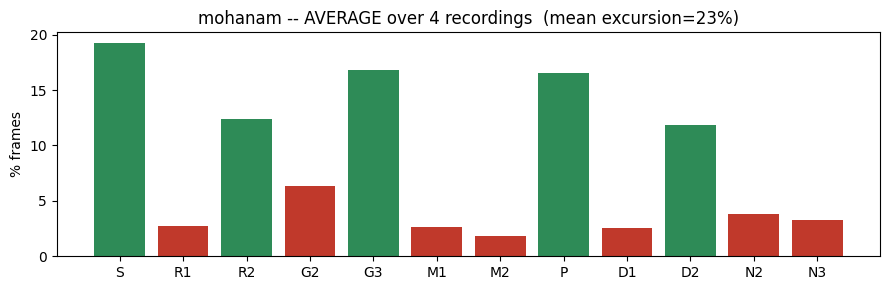

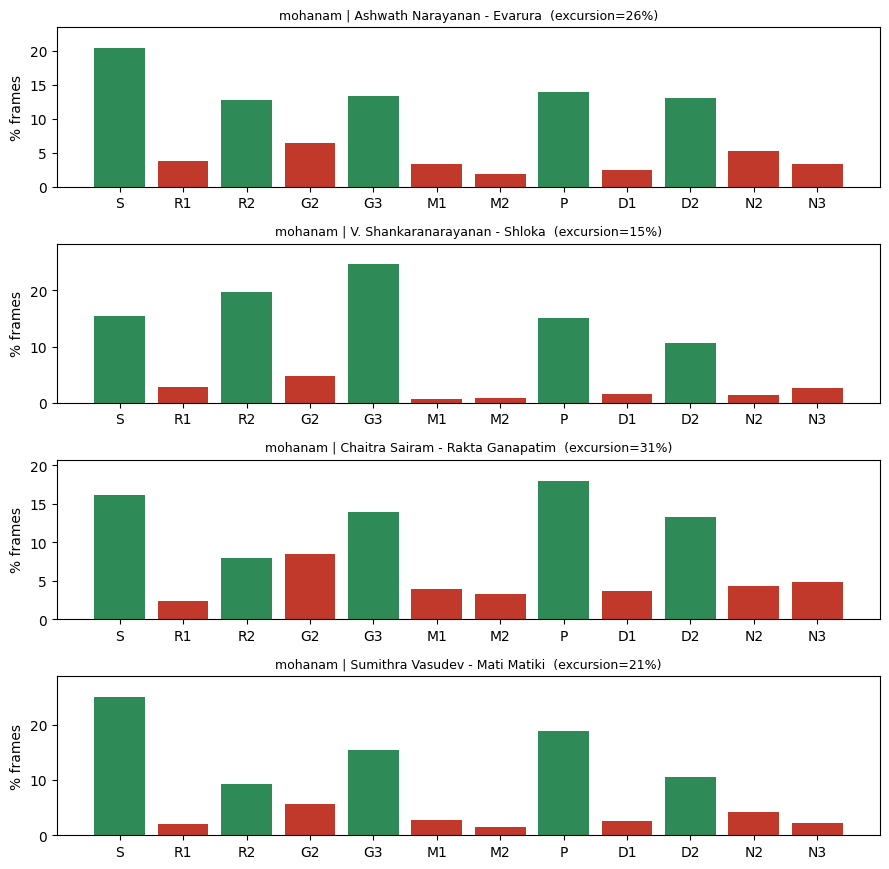

In [12]:
"""
Visualize swara histograms -- spot which notes leak, and how much.

Bars = % of voiced frames on each of the 12 swara positions.
Green bars  = swaras that belong to the raga (per RAGA_THEORY union).
Red bars    = off-scale swaras (excursion / possible tracking error).
This makes "which notes are leaking and how badly" obvious at a glance.

Run after Stage 1 v2 (needs swara_sequences.jsonl). Fill RAGA_THEORY_VIS
with the ragas you want to inspect.
"""

import json
import numpy as np
import matplotlib.pyplot as plt

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
SWARA_ORDER = ["S", "R1", "R2", "G2", "G3", "M1",
               "M2", "P", "D1", "D2", "N2", "N3"]

# swaras that BELONG to each raga (union of aro+avaro). Fill from your knowledge.
RAGA_THEORY_VIS = {
    "mohanam": {"S", "R2", "G3", "P", "D2"},          # pentatonic: no Ma, no Ni
    "behag":   {"S", "G3", "M1", "P", "N3", "R2", "D2", "M2"},  # example - verify
    # add more as you like
}


def load_by_raga(raga_name):
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if (r.get("raga") or "").lower() == raga_name.lower():
                recs.append(r)
    return recs


def plot_raga(raga_name, max_recs=6):
    recs = load_by_raga(raga_name)
    if not recs:
        print(f"No recordings found for {raga_name}")
        return
    legal = {s.upper() for s in RAGA_THEORY_VIS.get(raga_name.lower(), set())}

    n = min(len(recs), max_recs)
    fig, axes = plt.subplots(n, 1, figsize=(9, 2.2 * n), squeeze=False)
    for i in range(n):
        r = recs[i]
        hist = r["swara_hist_pct"]
        vals = [hist.get(s, 0) for s in SWARA_ORDER]
        colors = ["#2e8b57" if s in legal else "#c0392b" for s in SWARA_ORDER]
        ax = axes[i][0]
        ax.bar(SWARA_ORDER, vals, color=colors)
        off = sum(v for s, v in zip(SWARA_ORDER, vals) if s not in legal)
        ax.set_title(f"{raga_name} | {r['stem'][:45]}  "
                     f"(excursion={off:.0f}%)", fontsize=9)
        ax.set_ylabel("% frames")
        ax.set_ylim(0, max(vals) * 1.15 if vals else 1)
    plt.tight_layout()
    plt.show()


def plot_raga_average(raga_name):
    """Average histogram across all recordings of a raga -- the raga's
    'fingerprint'. Cleaner signal than any single recording."""
    recs = load_by_raga(raga_name)
    if not recs:
        print(f"No recordings for {raga_name}")
        return
    legal = {s.upper() for s in RAGA_THEORY_VIS.get(raga_name.lower(), set())}
    mat = np.array([[r["swara_hist_pct"].get(s, 0) for s in SWARA_ORDER]
                    for r in recs])
    mean = mat.mean(axis=0)
    colors = ["#2e8b57" if s in legal else "#c0392b" for s in SWARA_ORDER]
    plt.figure(figsize=(9, 3))
    plt.bar(SWARA_ORDER, mean, color=colors)
    off = sum(v for s, v in zip(SWARA_ORDER, mean) if s not in legal)
    plt.title(f"{raga_name} -- AVERAGE over {len(recs)} recordings  "
              f"(mean excursion={off:.0f}%)")
    plt.ylabel("% frames")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # inspect Mohanam -- the cleanest diagnostic (pentatonic, no Ma/Ni)
    plot_raga_average("mohanam")
    plot_raga("mohanam", max_recs=4)

In [12]:
seq_ragas = set()
with open(SEQ_PATH) as f:
    for line in f:
        r = json.loads(line)
        rk = (r.get("raga") or "").lower()
        if rk not in ("unknown","ragamalika",""): seq_ragas.add(rk)

missing = sorted(rk for rk in seq_ragas if rk not in T)
print(f"{len(missing)} Saraga ragas have NO theory match:")
for m in missing: print("  ", m)

NameError: name 'T' is not defined

Loaded theory for 95 ragas.

0 Saraga ragas still UNMATCHED (fill these into ALIASES):


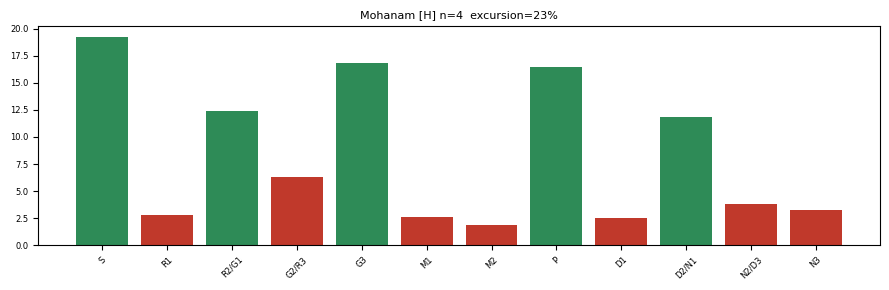

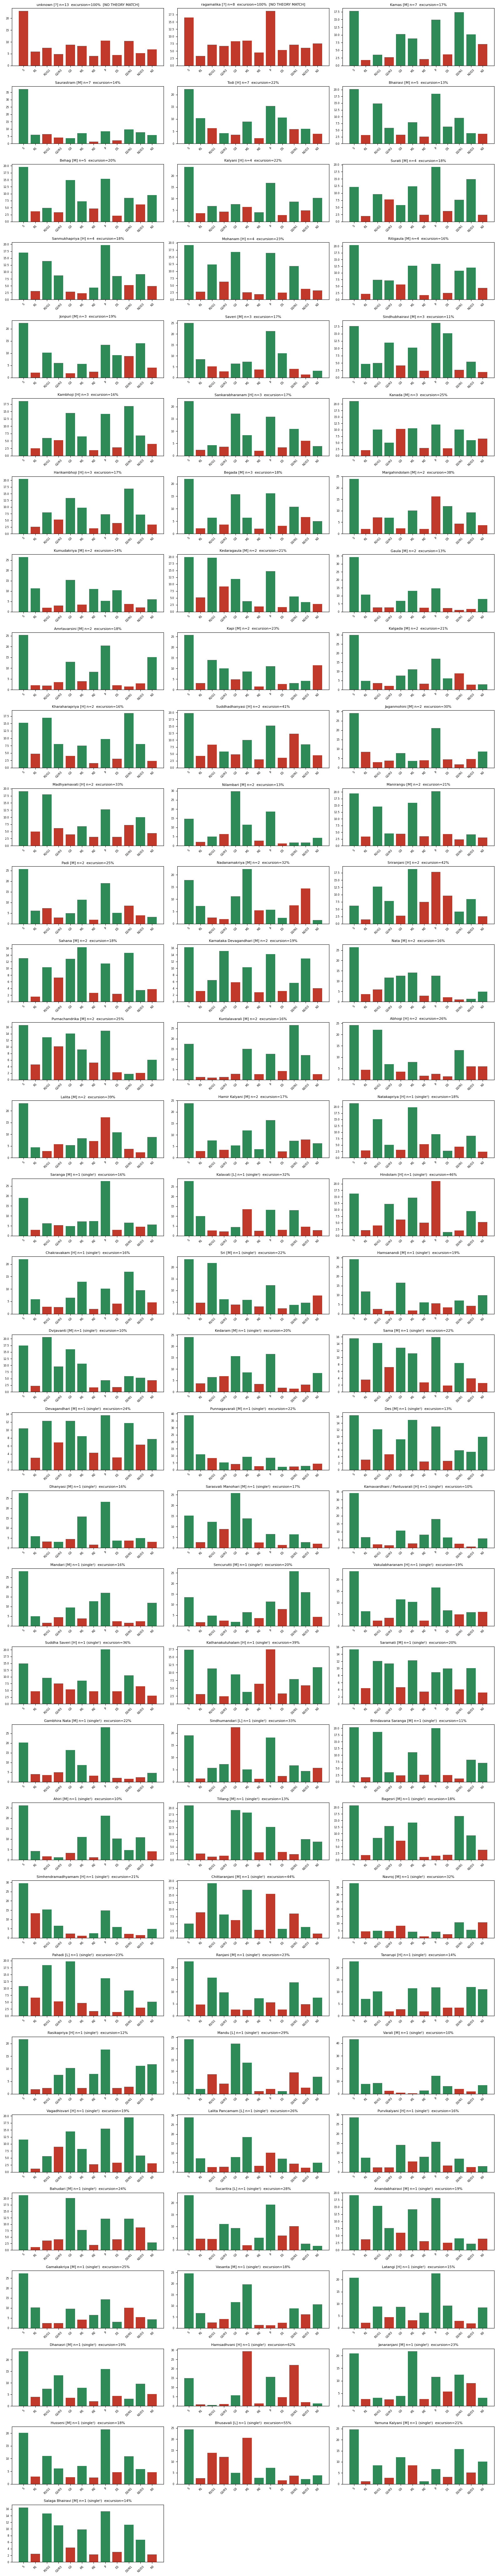

Saved grid -> /content/census_out/all_ragas_histograms.png


In [13]:
"""
COMBINED CELL (corrected): raga-theory loader + enharmonic-aware visualizer.

Requires:
  - /content/census_out/swara_sequences.jsonl        (from Stage 1 v2)
  - /content/carnatic_ragas_arohana_avarohana.xlsx   (upload it; adjust path)
"""

import os
import re
import json
import unicodedata
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =============================================================
# PATHS
# =============================================================
XLSX_PATH = "/content/carnatic_ragas_arohana_avarohana.xlsx"
SEQ_PATH  = "/content/census_out/swara_sequences.jsonl"
assert os.path.exists(XLSX_PATH), f"Spreadsheet not found at {XLSX_PATH}"
assert os.path.exists(SEQ_PATH),  f"Sequences not found at {SEQ_PATH}"


# =============================================================
# NAME ALIASES : Saraga spelling -> spreadsheet _key() spelling
# (extend this from the 'still unmatched' printout at the bottom)
# =============================================================
ALIASES = {
    "karaharapriya":              "kharaharapriya",
    "suddadhanyasi":              "suddhadhanyasi",
    "cakravakam":                 "chakravakam",
    "simhendra madhyamam":        "simhendramadhyamam",
    "brndavana saranga":          "brindavana saranga",
    "sudda saveri":               "suddha saveri",
    "vagadisvari":                "vagadhisvari",
    "kamavardani/pantuvarali":    "kamavardhani / pantuvarali",
    "purnacandrika":              "purnachandrika",
    "cittaranjani":               "chittaranjani",
}


# =============================================================
# 12 pitch positions
# =============================================================
POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]

SYMBOL_TO_POS = {
    "S": "S", "R1": "R1",
    "R2": "R2", "G1": "R2",
    "R3": "G2", "G2": "G2",
    "G3": "G3", "M1": "M1", "M2": "M2", "P": "P", "D1": "D1",
    "D2": "D2", "N1": "D2",
    "D3": "N2", "N2": "N2",
    "N3": "N3",
}

POS12_DISPLAY = {
    "S": "S", "R1": "R1", "R2": "R2/G1", "G2": "G2/R3", "G3": "G3",
    "M1": "M1", "M2": "M2", "P": "P", "D1": "D1", "D2": "D2/N1",
    "N2": "N2/D3", "N3": "N3",
}
DISPLAY_LABELS = [POS12_DISPLAY[p] for p in POS12]


# =============================================================
# LOAD RAGA THEORY
# =============================================================
def _key(name):
    d = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", d).strip().lower()


def _parse_scale(scale_str):
    labels = []
    for tok in scale_str.split():
        t = unicodedata.normalize("NFKD", tok).encode("ascii", "ignore").decode("ascii").strip()
        if not t:
            labels.append("S")
            continue
        t = t.upper()
        if t in SYMBOL_TO_POS:
            labels.append(SYMBOL_TO_POS[t])
    return labels


def load_raga_theory(xlsx_path=XLSX_PATH):
    df = pd.read_excel(xlsx_path, sheet_name="Ragas")
    theory = {}
    for _, row in df.iterrows():
        name = str(row["Raga"]).strip()
        if not name or name.lower() == "nan":
            continue
        aro = _parse_scale(str(row["Arohana"]))
        avaro = _parse_scale(str(row["Avarohana"]))
        theory[_key(name)] = {
            "display": name, "aro": aro, "avaro": avaro,
            "all": set(aro) | set(avaro),
            "confidence": str(row.get("Confidence", "")).strip(),
            "notes": str(row.get("Notes", "")).strip(),
        }
    return theory


T = load_raga_theory()
print(f"Loaded theory for {len(T)} ragas.")


# =============================================================
# HELPERS  (alias applied BEFORE lookup in T)
# =============================================================
def theory_entry(raga_key):
    """Return the theory dict for a Saraga raga key, applying the alias map."""
    key = ALIASES.get(raga_key, raga_key)
    return T.get(key)


def _legal_positions(raga_key):
    entry = theory_entry(raga_key)
    return set(entry["all"]) if entry else set()


def load_by_raga():
    by = defaultdict(list)
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            rk = (r.get("raga") or "").lower()
            by[rk].append(r)
    return by


_BY_RAGA = load_by_raga()


# =============================================================
# PLOTTING
# =============================================================
def plot_raga_average(raga_key, ax=None):
    recs = _BY_RAGA.get(raga_key, [])
    if not recs:
        if ax is None:
            print(f"No recordings for {raga_key}")
        return
    legal = _legal_positions(raga_key)
    mat = np.array([[r["swara_hist_pct"].get(s, 0) for s in POS12] for r in recs])
    mean = mat.mean(axis=0)
    colors = ["#2e8b57" if s in legal else "#c0392b" for s in POS12]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 3))
    ax.bar(DISPLAY_LABELS, mean, color=colors)
    off = sum(v for s, v in zip(POS12, mean) if s not in legal)

    entry = theory_entry(raga_key) or {}
    disp = entry.get("display", raga_key)
    conf = entry.get("confidence", "?")
    matched = "" if entry else "  [NO THEORY MATCH]"
    tag = f"n={len(recs)}" + (" (single!)" if len(recs) == 1 else "")
    ax.set_title(f"{disp} [{conf}] {tag}  excursion={off:.0f}%{matched}", fontsize=8)
    ax.tick_params(labelsize=6)
    ax.tick_params(axis="x", rotation=45)
    if standalone:
        plt.tight_layout(); plt.show()


def plot_all(save_path="/content/census_out/all_ragas_histograms.png"):
    ordered = sorted(_BY_RAGA.items(), key=lambda kv: -len(kv[1]))
    cols = 3
    rows = (len(ordered) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 2.5 * rows))
    axes = axes.flatten()
    i = -1
    for i, (rk, _) in enumerate(ordered):
        plot_raga_average(rk, ax=axes[i])
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"Saved grid -> {save_path}")


# =============================================================
# DIAGNOSTIC: which Saraga ragas still have NO theory match?
# =============================================================
def report_unmatched():
    seq_ragas = {rk for rk in _BY_RAGA if rk not in ("unknown", "ragamalika", "")}
    missing = sorted(rk for rk in seq_ragas if theory_entry(rk) is None)
    print(f"\n{len(missing)} Saraga ragas still UNMATCHED "
          f"(fill these into ALIASES):")
    for m in missing:
        print(f"   '{m}': '',")
    return missing


# =============================================================
# RUN
# =============================================================
report_unmatched()               # fix names first
plot_raga_average("mohanam")     # control
plot_all()                       # full wall

# Stage 2 — Baselines: Bag-of-Notes & Swara-Transition Retrieval

## Where we are in the project

**Phase: Information Retrieval — baseline representations & first evaluation.**

This is the first stage that is genuinely **IR**. Stage 1 (feature extraction)
turned recordings into swara sequences; Stage 2 turns those sequences into
**vector representations**, defines a **similarity function**, runs **retrieval**,
and measures it with **IR metrics**. That quartet — represent, score, retrieve,
evaluate — is the core loop of information retrieval.

Pipeline position: Census → Feature Extraction → **Baselines (here)** → Language
Model → Dense Retrieval → Evaluation.

Why baselines come before the learned model: the project's central claim is that
**movement (sanchara) matters beyond the note-set**. To show a learned model
captures movement, we first need simple reference points that (a) capture only
note-content and (b) capture only first-order movement. These are the strawman and
the floor the learned model must beat. Without them, a good learned result is
unfalsifiable — you cannot claim improvement without a baseline to improve over.

---

## What Stage 2 builds

### Baseline 1 — Bag-of-Notes (the strawman)
- **Representation:** a 12-dimensional vector — the proportion of each swara
  position in a recording.
- **What it captures:** *what notes* are present, and how often.
- **What it ignores:** order, movement, gamaka — everything sequential.
- **Expected weakness:** it cannot distinguish ragas that share a scale but differ
  in movement (allied ragas). This failure is the point — it motivates everything
  after it. It is the "bag of words" of this project.

### Baseline 2 — Swara-Transition Matrix (the floor)
- **Representation:** a 12×12 first-order Markov matrix, row-normalized, flattened
  to 144 dimensions — P(next swara | current swara).
- **What it captures:** *which swara follows which* — the first computational
  shadow of sanchara.
- **Why it should beat Baseline 1:** movement carries raga identity that raw
  note-content does not. If it wins, the project's core premise is demonstrated at
  the simplest possible level, before any deep learning.
- **What it still misses:** long-range phrase structure, gamaka shape, directional
  (aroha/avaroha) asymmetry beyond immediate transitions. These are what the
  learned model (Stage 4) exists to capture.

---

## Evaluation

**Task:** same-raga retrieval (query-by-example). Each recording is a query; all
others are ranked by cosine similarity of their vectors. A retrieved recording is
**relevant** if it shares the query's raga.

**Why query-by-example:** it is the honest IR framing of "does this representation
place musically-similar recordings near each other," and it needs no training — so
it fairly evaluates the *representation itself*, not a classifier fit on top.

**Metrics:**
- **Precision@k** (k = 1, 3, 5): fraction of the top-k that are same-raga.
- **MAP** (mean average precision): rewards ranking all relevant items high.
- **MRR** (mean reciprocal rank): how high the *first* correct hit appears.

**Query eligibility:** only recordings whose raga has ≥2 recordings are used as
queries — otherwise no correct answer exists to retrieve. This automatically
excludes the singleton-raga tail and keeps the metric meaningful.

**Similarity:** cosine over L2-normalized vectors — standard for this kind of
sparse count/probability representation, and scale-invariant.

---

## What the results will tell us

1. **Absolute level.** With ~20 evaluable ragas, random P@1 is low; scores well
   above chance mean the representations carry real raga signal.
2. **The key comparison — does Baseline 2 beat Baseline 1?**
   - *If yes:* movement helps over note-content alone — core premise supported at
     baseline level. This is a genuine, reportable finding on its own.
   - *If roughly equal:* first-order transitions are insufficient; the learned
     model has clear, well-motivated work to do. Also informative.
3. **The benchmark.** Whatever these numbers are, they are the bar Stage 4's
   learned representation must clear. Improvement is defined relative to them.

---

## Honest limitations (documented, not hidden)

- **First-order only.** The transition matrix sees pairs, not phrases. Ragas
  distinguished by longer characteristic movement will still be confused.
- **Direction-blind aggregate.** A transition matrix mixes ascending and
  descending contexts; it does not separately model aroha vs avaroha the way the
  theory (and Stage 1's directional diagnostic) does.
- **No gamaka shape.** The per-note gamaka descriptors from Stage 1 are not yet
  used here; these baselines operate on the collapsed symbolic sequence only.
- **Small data.** Absolute metric values are on a modest collection; trends and
  relative comparisons are more trustworthy than any single number.

These limitations are not flaws to apologize for — each one names a specific thing
the learned model is designed to address, so Stage 2 also functions as the
motivation for Stage 4.

---

## Output

- `stage2_baseline_results.csv` — the metrics table for both representations.
- Serves as the benchmark row(s) that all later results are compared against.

---

## Next

**Stage 3 (optional refinement) / Stage 4 (the learned model).** Depending on the
baseline gap: if first-order transitions already help meaningfully, proceed to the
self-supervised swara language model, whose learned representation should capture
the longer-range and directional structure these baselines cannot. The baseline
table defines exactly what "better" has to mean.

In [14]:
"""
Stage 2 -- Baselines: bag-of-notes & swara-transition retrieval
=============================================================
Builds the two DELIBERATELY-SIMPLE representations the learned model (Stage 4)
must beat, and runs the first real IR evaluation on them.

  Baseline 1  BAG-OF-NOTES  (swara-presence vector)
              12-d: how much of each swara a recording contains.
              Captures WHAT notes, not MOVEMENT. Confuses allied ragas. Strawman.

  Baseline 2  TRANSITION MATRIX  (first-order Markov)
              12x12 -> 144-d flattened: P(next swara | current swara).
              Captures MOVEMENT (which swara follows which) -> encodes early
              sanchara. The "floor" the learned model must exceed.

EVALUATION: same-raga retrieval (query-by-example).
  For each recording, rank all others by similarity; check whether same-raga
  recordings come back on top. Metrics: Precision@k, MAP, MRR.

  Split note: for a fair test we evaluate on the well-populated ragas only, and
  report per-raga so single-recording ragas (no same-raga target) are excluded.

Requires: swara_sequences.jsonl (Stage 1 v2).
-------------------------------------------------------------
"""

import os
import json
from collections import defaultdict

import numpy as np
import pandas as pd

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
OUT_DIR = "/content/census_out"

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
IDX = {s: i for i, s in enumerate(POS12)}
SIL = "_"


# =============================================================
# LOAD
# =============================================================
def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and (r["raga"].lower() not in ("unknown", "ragamalika")):
                recs.append(r)
    return recs


# =============================================================
# REPRESENTATIONS
# =============================================================
def bag_of_notes(seq):
    """12-d normalized count of swaras (silence ignored)."""
    v = np.zeros(12)
    for s in seq:
        if s in IDX:
            v[IDX[s]] += 1
    tot = v.sum()
    return v / tot if tot > 0 else v


def transition_matrix(seq):
    """12x12 row-normalized first-order transition probs, flattened to 144-d.
    Silence breaks continuity (no transition across a phrase boundary)."""
    M = np.zeros((12, 12))
    prev = None
    for s in seq:
        if s == SIL or s not in IDX:
            prev = None
            continue
        cur = IDX[s]
        if prev is not None:
            M[prev, cur] += 1
        prev = cur
    # row-normalize
    rowsum = M.sum(axis=1, keepdims=True)
    rowsum[rowsum == 0] = 1
    M = M / rowsum
    return M.flatten()


def build_representations(recs):
    bon = np.array([bag_of_notes(r["collapsed_seq"]) for r in recs])
    trans = np.array([transition_matrix(r["collapsed_seq"]) for r in recs])
    ragas = [r["raga"].lower() for r in recs]
    artists = [r.get("artist", "UNKNOWN") for r in recs]
    return bon, trans, ragas, artists


# =============================================================
# RETRIEVAL EVAL
# =============================================================
def cosine_sim_matrix(X):
    norm = np.linalg.norm(X, axis=1, keepdims=True)
    norm[norm == 0] = 1
    Xn = X / norm
    return Xn @ Xn.T


def evaluate(X, ragas, name, ks=(1, 3, 5)):
    """Query-by-example: each recording queries the rest, ranked by cosine.
    Relevant = same raga. Only queries whose raga has >=2 recordings count
    (otherwise there is no correct answer to retrieve)."""
    sim = cosine_sim_matrix(X)
    n = len(ragas)
    raga_counts = defaultdict(int)
    for r in ragas:
        raga_counts[r] += 1

    precisions = {k: [] for k in ks}
    aps, rrs = [], []
    evaluable = 0

    for i in range(n):
        if raga_counts[ragas[i]] < 2:
            continue  # no same-raga target exists
        evaluable += 1
        order = np.argsort(-sim[i])
        order = order[order != i]  # drop self
        rel = np.array([ragas[j] == ragas[i] for j in order], dtype=int)

        for k in ks:
            precisions[k].append(rel[:k].sum() / k)

        # average precision
        if rel.sum() > 0:
            cum = np.cumsum(rel)
            prec_at = cum / (np.arange(len(rel)) + 1)
            aps.append((prec_at * rel).sum() / rel.sum())
            # reciprocal rank
            first = np.argmax(rel) + 1
            rrs.append(1.0 / first)

    row = {"representation": name, "evaluable_queries": evaluable}
    for k in ks:
        row[f"P@{k}"] = round(np.mean(precisions[k]), 3)
    row["MAP"] = round(np.mean(aps), 3)
    row["MRR"] = round(np.mean(rrs), 3)
    return row


# =============================================================
# MAIN
# =============================================================
def main():
    recs = load_records()
    print(f"Loaded {len(recs)} labelled recordings "
          f"({len(set(r['raga'].lower() for r in recs))} ragas).")

    bon, trans, ragas, artists = build_representations(recs)

    results = [
        evaluate(bon,   ragas, "bag_of_notes (strawman)"),
        evaluate(trans, ragas, "transition_matrix (floor)"),
    ]
    df = pd.DataFrame(results)
    print("\n=== Same-raga retrieval (higher = better) ===")
    print(df.to_string(index=False))
    df.to_csv(os.path.join(OUT_DIR, "stage2_baseline_results.csv"), index=False)
    print(f"\nSaved -> {os.path.join(OUT_DIR, 'stage2_baseline_results.csv')}")

    print("\nInterpretation:")
    print("- If transition_matrix beats bag_of_notes, MOVEMENT already helps over")
    print("  note-content alone -- the core premise, shown at baseline level.")
    print("- These are the numbers the learned model (Stage 4) must exceed.")


if __name__ == "__main__":
    main()

Loaded 176 labelled recordings (95 ragas).

=== Same-raga retrieval (higher = better) ===
           representation  evaluable_queries   P@1  P@3   P@5   MAP   MRR
  bag_of_notes (strawman)                123 0.423 0.29 0.233 0.423 0.519
transition_matrix (floor)                123 0.431 0.32 0.237 0.418 0.547

Saved -> /content/census_out/stage2_baseline_results.csv

Interpretation:
- If transition_matrix beats bag_of_notes, MOVEMENT already helps over
  note-content alone -- the core premise, shown at baseline level.
- These are the numbers the learned model (Stage 4) must exceed.


# Results — Interpretation & Implications

## The numbers

| Representation | Eval queries | P@1 | P@3 | P@5 | MAP | MRR |
|---|---|---|---|---|---|---|
| Bag-of-notes (strawman) | 123 | 0.423 | 0.290 | 0.233 | **0.423** | 0.519 |
| Transition matrix (floor) | 123 | **0.431** | **0.320** | **0.237** | 0.418 | **0.547** |

176 labelled recordings across 95 ragas; 123 queries evaluable (raga has ≥2 recordings).

---

## What the results mean

### 1. Both representations carry real raga signal
With 95 ragas in the collection, chance-level P@1 is on the order of 1–5%.
Both representations achieve **~42% P@1** — the single nearest neighbour is the
same raga more than 40% of the time. So the swara sequences produced in Stage 1
are musically meaningful: raga identity survives the pitch→swara extraction. This
validates the feature-extraction pipeline from a retrieval standpoint, not just by
eye.

### 2. The two baselines are effectively tied
Transition matrix edges bag-of-notes on P@1, P@3, P@5, and MRR, but loses on MAP,
and **every margin is 1–3 points** — within noise for 123 queries. The honest
reading is **not** "movement beats note-content." It is: **first-order movement and
raw note-content perform about the same at the aggregate level.**

We deliberately do not overclaim the transition win. The gaps are too small to
support the thesis on their own.

### 3. Why the tie is expected — and why it *motivates* the project
A 12×12 transition matrix aggregated over a whole recording is still a coarse view
of movement. It discards exactly the things that carry raga identity:
- **Direction** — it mixes ascending and descending contexts into one matrix, so
  aroha/avaroha asymmetry (Bilahari-type ragas) is invisible.
- **Phrase length** — sancara are multi-note gestures; first-order transitions see
  only adjacent pairs.
- **Gamaka shape** — the oscillation profiles captured in Stage 1 are not used
  here.

Moreover, most of the 95 ragas have **distinct note-sets**, so bag-of-notes already
separates them — and where note-content alone suffices, movement adds nothing. The
place movement *should* matter is the minority of **allied ragas** (same scale,
different movement), and their effect is **diluted** in an average taken over all
ragas.

**Conclusion:** the aggregate tie is evidence for a precise claim — *shallow,
direction-blind, aggregated movement is not enough*. That is the strongest possible
motivation for a sequence model (Stage 4) that captures direction, longer phrases,
and context.

---

## How this affects the study

1. **The evaluation must be sharpened.** The aggregate metric hides the effect that
   matters. The next step (Stage 3) restricts evaluation to **allied / same-scale
   confusions**, where movement should separate what note-content cannot. If the
   transition matrix beats bag-of-notes *there*, the premise is supported on the
   cases that actually test it — a far stronger result than the aggregate.

2. **The benchmark is set.** Stage 4's learned model must (a) exceed ~0.42 P@1
   overall, and — more importantly — (b) separate allied-raga clusters that the
   baselines conflate. "Better" is now concretely defined.

3. **A negative-to-precise reframing.** "The baselines tied" is not a dead end; it
   converts into "here are the exact confusions shallow methods cannot resolve,"
   which is a sharper and more publishable framing than a raw accuracy number.

4. **Reporting integrity.** Carrying the honest tie (rather than spinning the
   1-point transition win) is itself a strength — it demonstrates evaluation rigor,
   which is exactly what an MIR-evaluation audience (e.g. ISMIR reviewers) rewards.

---

## One-line summary

The baselines prove the sequences carry raga signal but show that **crude movement
≈ note-content on average** — so the real question is whether movement helps **on
allied ragas specifically**, which is what Stage 3 isolates and Stage 4 is built to
exploit.

# Stage 3 — Confusion Analysis: Where Does Movement Matter?

## Where we are in the project

**Phase: Information Retrieval — diagnostic / error analysis.**

Stage 2 evaluated the baselines in aggregate and found a tie. Stage 3 does not add
a new representation; it **interrogates** the Stage 2 result to find out *where* the
representations succeed and fail — specifically, whether the movement signal helps
on the cases that theoretically require it (allied ragas). This is error analysis,
the step that turns a flat metric into an understanding of the model's behaviour.

Pipeline position: Census → Feature Extraction → Baselines → **Confusion Analysis
(here)** → Language Model → Dense Retrieval → Evaluation.

---

## What Stage 3 does

The aggregate P@1 in Stage 2 averages over all 95 ragas. Most ragas have distinct
note-sets, so note-content alone separates them and movement contributes nothing
*there*. Any benefit of movement should appear only on **allied ragas** — ragas
that share a scale but differ in sanchara. Averaged over everything, that effect is
diluted. Stage 3 removes the dilution three ways:

1. **Confusion pairs (A).** For each representation, record which raga is wrongly
   retrieved as the top-1, and how often. This surfaces *which* ragas are actually
   being confused, and each pair is annotated with its scale-overlap (Jaccard of
   note-sets).

2. **Scale-overlap stratification (B).** Split query ragas by whether they live in
   a **high-overlap neighbourhood** (share ≥80% of notes with some other raga —
   i.e. allied) vs. low-overlap. Compare bag-of-notes and transition-matrix P@1
   *within each stratum*. This is the direct test: does movement help where notes
   overlap?

3. **Interpretation against theory.** Cross-check whether the confused pairs are
   the ones music theory predicts to be hard.

---



In [15]:
"""
Stage 3 -- Confusion analysis: where does movement beat note-content?
=============================================================
Stage 2 showed bag-of-notes and transition-matrix tie ON AVERAGE. That average is
dominated by ragas with distinct note-sets, where note-content already suffices.
The premise of the project -- movement (sanchara) carries identity beyond notes --
should show up specifically on ALLIED ragas (same/similar scale, different
movement). This stage isolates those cases.

Three analyses:
  (A) Confusion pairs: which ragas get retrieved for which? Surfaces the ragas
      each representation actually confuses.
  (B) Scale-overlap stratification: split raga PAIRS by how much their note-sets
      overlap (Jaccard). Compare bag-of-notes vs transition ON HIGH-OVERLAP pairs
      (the allied cases) vs low-overlap pairs. Movement should help more on high
      overlap.
  (C) Same-melakarta / same-scale clusters: retrieval error rate within known
      allied clusters, per representation.

Requires: swara_sequences.jsonl, and the raga theory loader (for scale overlap).
Uses the SAME representations as Stage 2 (imported/redefined here).
-------------------------------------------------------------
"""

import os
import re
import json
import unicodedata
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
XLSX_PATH = "/content/carnatic_ragas_arohana_avarohana.xlsx"
OUT_DIR = "/content/census_out"

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
IDX = {s: i for i, s in enumerate(POS12)}
SIL = "_"

# reuse the alias map from the visualizer (extend if needed)
ALIASES = {
    "karaharapriya":              "kharaharapriya",
    "suddadhanyasi":              "suddhadhanyasi",
    "cakravakam":                 "chakravakam",
    "simhendra madhyamam":        "simhendramadhyamam",
    "brndavana saranga":          "brindavana saranga",
    "sudda saveri":               "suddha saveri",
    "vagadisvari":                "vagadhisvari",
    "kamavardani/pantuvarali":    "kamavardhani / pantuvarali",
    "purnacandrika":              "purnachandrika",
    "cittaranjani":               "chittaranjani",
}

SYMBOL_TO_POS = {
    "S": "S", "R1": "R1", "R2": "R2", "G1": "R2", "R3": "G2", "G2": "G2",
    "G3": "G3", "M1": "M1", "M2": "M2", "P": "P", "D1": "D1", "D2": "D2",
    "N1": "D2", "D3": "N2", "N2": "N2", "N3": "N3",
}


# ---------- theory (for scale overlap) ----------
def _key(name):
    d = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", d).strip().lower()


def _parse_scale(s):
    out = []
    for tok in str(s).split():
        t = unicodedata.normalize("NFKD", tok).encode("ascii", "ignore").decode("ascii").strip().upper()
        if not t:
            out.append("S")
        elif t in SYMBOL_TO_POS:
            out.append(SYMBOL_TO_POS[t])
    return out


def load_theory():
    df = pd.read_excel(XLSX_PATH, sheet_name="Ragas")
    T = {}
    for _, row in df.iterrows():
        name = str(row["Raga"]).strip()
        if not name or name.lower() == "nan":
            continue
        allsw = set(_parse_scale(row["Arohana"])) | set(_parse_scale(row["Avarohana"]))
        T[_key(name)] = allsw
    return T


T = load_theory()


def scale_set(raga_key):
    return T.get(ALIASES.get(raga_key, raga_key), set())


# ---------- representations (same as Stage 2) ----------
def bag_of_notes(seq):
    v = np.zeros(12)
    for s in seq:
        if s in IDX:
            v[IDX[s]] += 1
    tot = v.sum()
    return v / tot if tot else v


def transition_matrix(seq):
    M = np.zeros((12, 12))
    prev = None
    for s in seq:
        if s == SIL or s not in IDX:
            prev = None
            continue
        c = IDX[s]
        if prev is not None:
            M[prev, c] += 1
        prev = c
    rs = M.sum(1, keepdims=True); rs[rs == 0] = 1
    return (M / rs).flatten()


def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def cos(X):
    n = np.linalg.norm(X, axis=1, keepdims=True); n[n == 0] = 1
    Xn = X / n
    return Xn @ Xn.T


# =============================================================
# (A) CONFUSION PAIRS
# =============================================================
def confusion_pairs(X, ragas, name, top=15):
    sim = cos(X)
    n = len(ragas)
    counts = Counter(ragas)
    confusions = Counter()
    for i in range(n):
        if counts[ragas[i]] < 2:
            continue
        order = np.argsort(-sim[i])
        order = order[order != i]
        top1 = ragas[order[0]]
        if top1 != ragas[i]:
            pair = tuple(sorted([ragas[i], top1]))
            confusions[pair] += 1
    print(f"\n[{name}] most frequent top-1 CONFUSIONS (retrieved wrong raga):")
    for (a, b), c in confusions.most_common(top):
        j = len(scale_set(a) & scale_set(b))
        u = len(scale_set(a) | scale_set(b)) or 1
        print(f"   {a:22s} <-> {b:22s}  x{c}   scale_overlap={j/u:.2f}")
    return confusions


# =============================================================
# (B) STRATIFY BY SCALE OVERLAP
# =============================================================
def stratified_by_overlap(bon, trans, ragas):
    """For each query, does the top-1 share the query's raga? Bucket queries by
    whether the *confusing* raga (top-1 if wrong) has high scale overlap. Compare
    the two representations on high- vs low-overlap difficulty."""
    def per_rep(X):
        sim = cos(X)
        counts = Counter(ragas)
        # bucket: for wrong top-1s, is the wrong raga high-overlap (allied) or not
        hi_correct = hi_total = lo_correct = lo_total = 0
        for i in range(len(ragas)):
            if counts[ragas[i]] < 2:
                continue
            order = np.argsort(-sim[i]); order = order[order != i]
            top1 = ragas[order[0]]
            correct = int(top1 == ragas[i])
            # difficulty proxy: max scale-overlap this raga has with ANY other raga
            # (allied ragas live in high-overlap neighbourhoods)
            ov = max((len(scale_set(ragas[i]) & scale_set(r)) /
                      (len(scale_set(ragas[i]) | scale_set(r)) or 1))
                     for r in set(ragas) if r != ragas[i])
            if ov >= 0.8:
                hi_total += 1; hi_correct += correct
            else:
                lo_total += 1; lo_correct += correct
        hi = hi_correct / hi_total if hi_total else float("nan")
        lo = lo_correct / lo_total if lo_total else float("nan")
        return hi, lo, hi_total, lo_total

    b_hi, b_lo, hn, ln = per_rep(bon)
    t_hi, t_lo, _, _ = per_rep(trans)
    print("\n=== P@1 stratified by scale-overlap neighbourhood ===")
    print(f"(high-overlap = ragas that share >=80% of notes with some other raga; "
          f"n_hi={hn}, n_lo={ln})")
    df = pd.DataFrame([
        {"representation": "bag_of_notes",      "P@1_high_overlap": round(b_hi, 3), "P@1_low_overlap": round(b_lo, 3)},
        {"representation": "transition_matrix", "P@1_high_overlap": round(t_hi, 3), "P@1_low_overlap": round(t_lo, 3)},
    ])
    print(df.to_string(index=False))
    print("\nKey question: does transition_matrix beat bag_of_notes in the "
          "HIGH-overlap column? That is where movement should matter.")
    df.to_csv(os.path.join(OUT_DIR, "stage3_overlap_stratified.csv"), index=False)
    return df


# =============================================================
# MAIN
# =============================================================
def main():
    recs = load_records()
    ragas = [r["raga"].lower() for r in recs]
    bon = np.array([bag_of_notes(r["collapsed_seq"]) for r in recs])
    trans = np.array([transition_matrix(r["collapsed_seq"]) for r in recs])

    print(f"Loaded {len(recs)} recordings, {len(set(ragas))} ragas.")

    # (A) what gets confused
    confusion_pairs(bon,   ragas, "bag_of_notes")
    confusion_pairs(trans, ragas, "transition_matrix")

    # (B) does movement help specifically on high-overlap (allied) ragas?
    stratified_by_overlap(bon, trans, ragas)

    print("\nInterpretation:")
    print("- If the SAME allied pairs are confused by bag_of_notes but NOT by")
    print("  transition_matrix, that is direct evidence movement separates them.")
    print("- If transition_matrix's P@1 advantage concentrates in the HIGH-overlap")
    print("  column, the aggregate tie was hiding a real effect on allied ragas.")


if __name__ == "__main__":
    main()

Loaded 176 recordings, 95 ragas.

[bag_of_notes] most frequent top-1 CONFUSIONS (retrieved wrong raga):
   behag                  <-> kalyani                 x3   scale_overlap=0.75
   begada                 <-> kambhoji                x3   scale_overlap=0.75
   margahindolam          <-> sindhubhairavi          x2   scale_overlap=0.62
   bhairavi               <-> husseni                 x2   scale_overlap=0.88
   amrtavarsini           <-> mandari                 x2   scale_overlap=0.83
   behag                  <-> kanada                  x2   scale_overlap=0.56
   saramati               <-> sindhubhairavi          x2   scale_overlap=0.88
   madhyamavati           <-> manirangu               x2   scale_overlap=0.83
   kamas                  <-> kambhoji                x2   scale_overlap=1.00
   nilambari              <-> sankarabharanam         x2   scale_overlap=0.88
   bhairavi               <-> kanada                  x2   scale_overlap=0.88
   behag                  <-> hamir ka

## Stage 3 - Results

### (A) The confusions are musically correct

The most-confused pairs are genuine allied ragas — ragas that share scales and that
even trained listeners separate by movement, not notes:

| Confused pair | Scale overlap |
|---|---|
| harikambhoji ↔ kambhoji | 1.00 |
| karaharapriya ↔ ritigaula | 1.00 |
| kamas ↔ kambhoji | 1.00 |
| kalgada ↔ saveri | 1.00 |
| madhyamavati ↔ manirangu | 0.83 |
| behag ↔ hamir kalyani | 0.88 |

This is itself a finding: **content-based swara representations confuse precisely
the allied-raga pairs that theory predicts.** The system fails on the *right*
cases — evidence the representations behave musically, not randomly.

### (B) Movement does NOT help on allied ragas — it hurts

| Representation | P@1 (high-overlap / allied, n=119) | P@1 (low-overlap, n=4) |
|---|---|---|
| bag_of_notes | **0.303** | 0.75 |
| transition_matrix | 0.193 | 1.00 |

On the allied ragas — the cases that were supposed to favour movement —
**note-content (0.303) beats first-order transitions (0.193).** This is the
opposite of the hypothesis, and it is reported as-is.

*(The low-overlap column has only 4 queries and is not interpretable; it is
excluded from any conclusion.)*

---

## What this means (the corrected finding)

The hypothesis was "movement separates allied ragas." The data says: **naive,
first-order movement modelling is too noisy to help, and on allied ragas that noise
costs more than the faint movement signal gains.**

The mechanism is estimation, not music:
- A 12×12 transition matrix has **144 parameters** estimated from a *single*
  recording's note-runs — sparse and noisy, especially after run-length collapsing.
- Bag-of-notes has **12 parameters** — far more stably estimated.
- On allied ragas the true distinction is subtle, so the transition matrix's
  estimation noise swamps the signal, and it underperforms the simpler
  representation.

So the movement information exists in principle, but **first-order Markov is both
too crude (only adjacent pairs) and too data-hungry (144 params/recording) to
recover it reliably.**

---

## Why this strengthens the project

This is a better motivation for the learned model than the result we expected:

- It shows note-content is a **surprisingly strong** baseline — a non-obvious,
  reportable result.
- It shows naive movement modelling **actively fails** on the hard cases, and
  explains *why* (estimation noise, first-order limitation).
- It therefore **precisely specifies what the learned model must do**: pool
  statistical strength across recordings (not 144 independent params each),
  capture patterns **longer than pairs**, and encode **direction**. A sequence
  model addresses exactly these three failure modes.

The Stage 4 mandate is now concrete and evidence-backed: *recover the movement
signal that first-order statistics cannot, on the allied ragas where content-based
methods top out at ~0.30 P@1.*

---

## Honest limitations

- **Low-overlap stratum is tiny (n=4)** — ignored in all conclusions.
- **Single-recording estimation** is the transition matrix's core weakness; a
  fairer movement baseline might pool transitions per raga, but that would leak the
  label — so we leave it as an honest per-recording baseline.
- **Small collection** overall; trends are more trustworthy than absolute values.

---

## One-line summary

The baselines confuse exactly the theoretically-allied ragas, and on those ragas
**content beats naive movement** because first-order transitions are too noisy to
estimate per recording — which is the precise, evidence-backed reason a *learned*
sequence model (Stage 4) is needed.

# Stage 4a — Swara Language Model: LSTM

## Where we are in the project

**Phase: Machine Learning / NLP — the core contribution begins here.**

Stages 1–3 were feature extraction, baseline IR, and error analysis. Stage 4 is
where the project becomes a *learning* project: a neural sequence model is trained
on the swara sequences, and its learned representations are used for retrieval.
This is the "A" component of the project design (the swara language model), and the
first stage involving model training of any kind.

Stage 4 is split into two parts sharing one pipeline:
- **4a (this stage):** LSTM encoder — the robust, small-data-friendly architecture.
- **4b (next):** tiny Transformer — same objective, same data, same evaluation;
  only the encoder swaps. The 4a-vs-4b comparison ("at what data scale does a
  Transformer beat an LSTM on symbolic music?") is itself a reportable result.

Pipeline position: Census → Feature Extraction → Baselines → Confusion Analysis →
**Swara LM: LSTM (here)** → Swara LM: Transformer → Comparison & Final Evaluation.

---

## What Stage 4a builds

### The idea in one paragraph
A language model learns the grammar of text by predicting the next word; nothing is
labelled, yet grammar emerges because predicting well *requires* it. Stage 4a does
the same on melody: an LSTM is trained to predict the **next swara** given the
preceding swaras. To predict well in Carnatic music, the model must internalise
sanchara — which movements are permitted, expected, characteristic — because that
is what governs what comes next. **No raga labels are used at any point in
training.** The model's hidden states then serve as recording embeddings for
retrieval, evaluated identically to the baselines.

### Why this addresses the Stage 3 failure specifically
Stage 3 showed first-order transitions *lose* to note-content on allied ragas, and
diagnosed why: 144 parameters estimated per single recording is too noisy, and
adjacent-pair statistics are too crude. The LSTM addresses all three failure modes:

| First-order failure | LSTM answer |
|---|---|
| Per-recording estimation (noisy) | **One model pooled over all recordings** — statistical strength is shared |
| Only adjacent pairs | **Recurrent state carries longer context** — multi-note phrases |
| Direction-blind | **Sequential processing is inherently directional** — ascent and descent are different contexts |

### Design choices (driven by the 176-recording constraint)
- **Deliberately small:** 1-layer LSTM, 64 hidden units, 32-d embeddings,
  dropout 0.3. A large model would memorise this collection instantly.
- **Window training:** sequences are sliced into overlapping 64-token windows,
  turning 176 recordings into thousands of training examples — the standard trick
  that makes neural training feasible on small corpora.
- **Held-out-ARTIST validation:** whole artists are excluded from training and
  used for validation. Low validation loss therefore means the model learned
  *swara grammar that generalises across performers*, not memorised recordings or
  singer idiosyncrasies. This is the anti-cheating measure carried through from
  the project's design principles.
- **Early stopping** on that held-out-artist loss, so training halts when
  generalisation stops improving.

### From language model to retrieval
After training, each recording is embedded by running its swara sequence through
the LSTM and **mean-pooling the hidden states**. Retrieval is cosine similarity
over these embeddings, evaluated with the *identical* protocol to Stages 2/3
(same queries, same metrics: P@k, MAP, MRR), so all numbers are directly
comparable to the baselines.

---

## What the results will mean

The benchmark: bag-of-notes P@1 = 0.423, transition matrix P@1 = 0.431 (aggregate);
on allied ragas specifically, content = 0.303, naive movement = 0.193.

Three outcomes, all reportable:

1. **LSTM beats the baselines** — the learned representation recovered movement
   signal that per-recording first-order statistics could not. The project's
   central premise is supported, with the mechanism identified (pooled estimation,
   longer context, directionality).

2. **LSTM ties the baselines** — at this data scale, learned sequence
   representations do not add over note-content. An honest scale finding, and the
   4b comparison plus the allied-raga stratum become the deciding evidence.

3. **LSTM loses** — 176 recordings is below the threshold where sequence LMs help;
   a clean negative result about data requirements for symbolic-music
   representation learning, directly relevant to low-resource MIR.

**The decisive secondary analysis:** even if the aggregate ties, the question that
matters is the **allied-raga (high-overlap) stratum**, where content topped out at
0.303 and naive movement failed at 0.193. If the LSTM lifts that number, it
recovered exactly the signal the project set out to capture — that is the headline
result regardless of the aggregate.

**Training diagnostics to record:** the train/validation loss curves. Falling
together = learning grammar; diverging = overfitting (early stopping catches it,
but the epoch at which it occurs is itself data about how much signal the corpus
supports). Validation perplexity is reported as the language-modelling quality
measure, independent of retrieval.

---

## Honest limitations

- **Mean-pooling** hidden states is the simplest possible sequence-to-embedding
  reduction; it may wash out phrase-level detail. (Refinements — attention pooling,
  max-pooling, CLS-style summaries — are 4b/later options.)
- **The embedding is trained for prediction, not retrieval.** There is no
  contrastive or metric-learning objective; retrieval quality is an emergent
  property. This is deliberate (keeps training label-free) but means retrieval is
  an indirect use of the representation.
- **Small collection** remains the binding constraint; all conclusions are about
  this data scale.

---

## Outputs

- `stage4a_lstm_results.csv` — retrieval metrics for the LSTM embeddings.
- `stage4a_lstm_embeddings.npy` — per-recording embeddings (for 4b comparison and
  allied-raga stratified analysis).
- `stage4a_lstm.pt` — trained model weights.
- Training log (epoch losses, early-stop point, best held-out-artist perplexity).

---

## One-line summary

Stage 4a trains a small, label-free LSTM to predict the next swara — forcing it to
learn sanchara — and tests whether its pooled, directional, longer-context
representation recovers the movement signal on allied ragas that first-order
statistics provably could not.

In [16]:
"""
Stage 4a -- Swara Language Model: LSTM
=============================================================
Trains a small LSTM on next-swara prediction (self-supervised, NO raga labels),
then uses its hidden states as recording embeddings for retrieval, evaluated
exactly like Stages 2/3 so results are directly comparable.

Design choices driven by the small collection (176 recordings):
  - Small model (1-layer LSTM, modest hidden size) + dropout + early stopping
  - Training on overlapping WINDOWS of the swara sequences (176 recordings ->
    thousands of training examples)
  - Held-out-ARTIST validation split: the model is validated on artists it never
    trained on, so low val loss means swara grammar, not memorised recordings
  - Same retrieval evaluation (cosine, P@k / MAP / MRR + allied-raga stratum)

Stage 4b will swap the encoder for a tiny Transformer, reusing everything else,
so the LSTM-vs-Transformer comparison is apples-to-apples.

Requires: swara_sequences.jsonl. Install: pip install torch (GPU runtime helps).
-------------------------------------------------------------
"""

import os
import json
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
OUT_DIR = "/content/census_out"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ---------------- vocabulary ----------------
POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
PAD, SIL = "<pad>", "_"
VOCAB = [PAD, SIL] + POS12
STOI = {s: i for i, s in enumerate(VOCAB)}
VSIZE = len(VOCAB)

# ---------------- hyperparams (small on purpose) ----------------
WINDOW = 64          # swara tokens per training window
STRIDE = 32          # overlap between windows
EMB_DIM = 32
HID_DIM = 64
DROPOUT = 0.3
BATCH = 64
LR = 3e-3
MAX_EPOCHS = 60
PATIENCE = 6         # early stopping on held-out-artist val loss
VAL_ARTIST_FRAC = 0.2


# =============================================================
# DATA
# =============================================================
def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def encode(seq):
    return [STOI[s] for s in seq if s in STOI]


def make_windows(ids, window=WINDOW, stride=STRIDE):
    out = []
    for start in range(0, max(1, len(ids) - window), stride):
        w = ids[start:start + window + 1]     # +1: next-token targets
        if len(w) >= 8:                        # skip tiny tails
            out.append(w)
    return out


class WindowDataset(Dataset):
    def __init__(self, windows):
        self.windows = windows

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, i):
        w = self.windows[i]
        x = torch.full((WINDOW,), STOI[PAD], dtype=torch.long)
        y = torch.full((WINDOW,), -100, dtype=torch.long)   # -100 = ignore in loss
        n = len(w) - 1
        x[:n] = torch.tensor(w[:-1])
        y[:n] = torch.tensor(w[1:])
        return x, y


def artist_split(recs, frac=VAL_ARTIST_FRAC):
    """Hold out whole ARTISTS for validation -- the anti-cheating split."""
    artists = sorted({r.get("artist", "UNKNOWN") for r in recs})
    rng = random.Random(SEED)
    rng.shuffle(artists)
    n_val = max(1, int(len(artists) * frac))
    val_artists = set(artists[:n_val])
    train = [r for r in recs if r.get("artist") not in val_artists]
    val = [r for r in recs if r.get("artist") in val_artists]
    return train, val, val_artists


# =============================================================
# MODEL
# =============================================================
class SwaraLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VSIZE, EMB_DIM, padding_idx=STOI[PAD])
        self.lstm = nn.LSTM(EMB_DIM, HID_DIM, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(DROPOUT)
        self.head = nn.Linear(HID_DIM, VSIZE)

    def forward(self, x):
        h, _ = self.lstm(self.emb(x))
        return self.head(self.drop(h)), h    # logits, hidden states

    @torch.no_grad()
    def embed_sequence(self, ids, max_len=2048):
        """Mean-pooled hidden state over the (truncated) sequence -> embedding."""
        self.eval()
        ids = ids[:max_len]
        x = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
        _, h = self.forward(x)
        return h.squeeze(0).mean(0).cpu().numpy()


# =============================================================
# TRAIN
# =============================================================
def train_model(train_recs, val_recs):
    tr_windows, va_windows = [], []
    for r in train_recs:
        tr_windows += make_windows(encode(r["collapsed_seq"]))
    for r in val_recs:
        va_windows += make_windows(encode(r["collapsed_seq"]))
    print(f"Train windows: {len(tr_windows)}   Val windows (held-out artists): {len(va_windows)}")

    tr_dl = DataLoader(WindowDataset(tr_windows), batch_size=BATCH, shuffle=True)
    va_dl = DataLoader(WindowDataset(va_windows), batch_size=BATCH)

    model = SwaraLSTM().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = nn.CrossEntropyLoss(ignore_index=-100)

    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr_loss, nb = 0.0, 0
        for x, y in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, _ = model(x)
            loss = lossf(logits.reshape(-1, VSIZE), y.reshape(-1))
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item(); nb += 1
        model.eval()
        va_loss, vb = 0.0, 0
        with torch.no_grad():
            for x, y in va_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits, _ = model(x)
                va_loss += lossf(logits.reshape(-1, VSIZE), y.reshape(-1)).item(); vb += 1
        tr_loss /= max(nb, 1); va_loss /= max(vb, 1)
        print(f"epoch {epoch:02d}  train_loss={tr_loss:.3f}  "
              f"val_loss(held-out artists)={va_loss:.3f}  ppl={math.exp(va_loss):.2f}")
        if va_loss < best_val - 1e-3:
            best_val, best_state, bad = va_loss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"Early stop at epoch {epoch} (no val improvement for {PATIENCE}).")
                break
    model.load_state_dict(best_state)
    print(f"Best held-out-artist val loss: {best_val:.3f} (ppl {math.exp(best_val):.2f})")
    return model


# =============================================================
# RETRIEVAL EVALUATION  (identical protocol to Stage 2/3)
# =============================================================
def cosine(X):
    n = np.linalg.norm(X, axis=1, keepdims=True); n[n == 0] = 1
    Xn = X / n
    return Xn @ Xn.T


def evaluate_retrieval(X, ragas, name, ks=(1, 3, 5)):
    sim = cosine(X)
    counts = Counter(ragas)
    precisions = {k: [] for k in ks}
    aps, rrs = [], []
    evaluable = 0
    for i in range(len(ragas)):
        if counts[ragas[i]] < 2:
            continue
        evaluable += 1
        order = np.argsort(-sim[i]); order = order[order != i]
        rel = np.array([ragas[j] == ragas[i] for j in order], dtype=int)
        for k in ks:
            precisions[k].append(rel[:k].sum() / k)
        if rel.sum():
            cum = np.cumsum(rel)
            prec_at = cum / (np.arange(len(rel)) + 1)
            aps.append((prec_at * rel).sum() / rel.sum())
            rrs.append(1.0 / (np.argmax(rel) + 1))
    row = {"representation": name, "evaluable_queries": evaluable}
    for k in ks:
        row[f"P@{k}"] = round(float(np.mean(precisions[k])), 3)
    row["MAP"] = round(float(np.mean(aps)), 3)
    row["MRR"] = round(float(np.mean(rrs)), 3)
    return row


# =============================================================
# MAIN
# =============================================================
def main():
    recs = load_records()
    print(f"Loaded {len(recs)} recordings, {len(set(r['raga'].lower() for r in recs))} ragas. Device: {DEVICE}")

    train_recs, val_recs, val_artists = artist_split(recs)
    print(f"Held-out validation artists ({len(val_artists)}): {sorted(val_artists)}")

    model = train_model(train_recs, val_recs)

    # embed ALL recordings with the trained model, evaluate retrieval on all
    embs = np.array([model.embed_sequence(encode(r["collapsed_seq"])) for r in recs])
    ragas = [r["raga"].lower() for r in recs]

    result = evaluate_retrieval(embs, ragas, "lstm_lm_embedding")
    df = pd.DataFrame([result])
    print("\n=== Retrieval with LSTM-LM embeddings ===")
    print(df.to_string(index=False))
    print("\nBaselines to beat (Stage 2): bag_of_notes P@1=0.423, transitions P@1=0.431")
    df.to_csv(os.path.join(OUT_DIR, "stage4a_lstm_results.csv"), index=False)

    # save embeddings + model for Stage 4b comparison and further analysis
    np.save(os.path.join(OUT_DIR, "stage4a_lstm_embeddings.npy"), embs)
    torch.save(model.state_dict(), os.path.join(OUT_DIR, "stage4a_lstm.pt"))
    print(f"\nSaved results, embeddings, model -> {OUT_DIR}")


if __name__ == "__main__":
    main()

Loaded 176 recordings, 95 ragas. Device: cpu
Held-out validation artists (3): ['Kanakadurga Venkatesh', 'Mahati', 'S Sundar']
Train windows: 19279   Val windows (held-out artists): 3654
epoch 01  train_loss=2.110  val_loss(held-out artists)=2.038  ppl=7.67
epoch 02  train_loss=2.034  val_loss(held-out artists)=2.016  ppl=7.51
epoch 03  train_loss=2.019  val_loss(held-out artists)=2.009  ppl=7.46
epoch 04  train_loss=2.011  val_loss(held-out artists)=2.003  ppl=7.41
epoch 05  train_loss=2.004  val_loss(held-out artists)=2.002  ppl=7.40
epoch 06  train_loss=2.000  val_loss(held-out artists)=2.001  ppl=7.39
epoch 07  train_loss=1.996  val_loss(held-out artists)=1.995  ppl=7.35
epoch 08  train_loss=1.994  val_loss(held-out artists)=1.994  ppl=7.34
epoch 09  train_loss=1.991  val_loss(held-out artists)=1.993  ppl=7.34
epoch 10  train_loss=1.989  val_loss(held-out artists)=1.992  ppl=7.33
epoch 11  train_loss=1.988  val_loss(held-out artists)=1.993  ppl=7.34
epoch 12  train_loss=1.986  val_l

In [17]:
"""
Stage 4b -- Swara Language Model: tiny Transformer
=============================================================
Identical pipeline to Stage 4a (same data, same windows, same next-swara
objective, same held-out-artist validation, same retrieval evaluation) with ONE
change: the LSTM encoder is replaced by a small causal Transformer.

Purpose: complete the architecture comparison. Expectation (stated in advance):
the Transformer will likely fail retrieval the same way the LSTM did, because the
failure was OBJECTIVE misalignment (generative prediction learns shared grammar,
not discriminative identity), not architecture. Confirming that is itself a clean
result; refuting it (Transformer wins) would be even more interesting.

Requires: swara_sequences.jsonl. GPU recommended.
-------------------------------------------------------------
"""

import os
import json
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
OUT_DIR = "/content/census_out"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
PAD, SIL = "<pad>", "_"
VOCAB = [PAD, SIL] + POS12
STOI = {s: i for i, s in enumerate(VOCAB)}
VSIZE = len(VOCAB)

# ---- hyperparams: kept deliberately tiny, matched in spirit to 4a ----
WINDOW = 64
STRIDE = 32
EMB_DIM = 32
N_HEADS = 4
N_LAYERS = 2
FF_DIM = 64
DROPOUT = 0.3
BATCH = 64
LR = 1e-3            # transformers prefer lower LR than the LSTM's 3e-3
MAX_EPOCHS = 60
PATIENCE = 6
VAL_ARTIST_FRAC = 0.2


# ---------------- data (identical to 4a) ----------------
def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def encode(seq):
    return [STOI[s] for s in seq if s in STOI]


def make_windows(ids, window=WINDOW, stride=STRIDE):
    out = []
    for start in range(0, max(1, len(ids) - window), stride):
        w = ids[start:start + window + 1]
        if len(w) >= 8:
            out.append(w)
    return out


class WindowDataset(Dataset):
    def __init__(self, windows):
        self.windows = windows
    def __len__(self):
        return len(self.windows)
    def __getitem__(self, i):
        w = self.windows[i]
        x = torch.full((WINDOW,), STOI[PAD], dtype=torch.long)
        y = torch.full((WINDOW,), -100, dtype=torch.long)
        n = len(w) - 1
        x[:n] = torch.tensor(w[:-1])
        y[:n] = torch.tensor(w[1:])
        return x, y


def artist_split(recs, frac=VAL_ARTIST_FRAC):
    artists = sorted({r.get("artist", "UNKNOWN") for r in recs})
    rng = random.Random(SEED)
    rng.shuffle(artists)
    n_val = max(1, int(len(artists) * frac))
    val_artists = set(artists[:n_val])
    train = [r for r in recs if r.get("artist") not in val_artists]
    val = [r for r in recs if r.get("artist") in val_artists]
    return train, val, val_artists


# ---------------- model ----------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=WINDOW + 8):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SwaraTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VSIZE, EMB_DIM, padding_idx=STOI[PAD])
        self.pos = PositionalEncoding(EMB_DIM)
        layer = nn.TransformerEncoderLayer(
            d_model=EMB_DIM, nhead=N_HEADS, dim_feedforward=FF_DIM,
            dropout=DROPOUT, batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=N_LAYERS)
        self.head = nn.Linear(EMB_DIM, VSIZE)

    def forward(self, x):
        # causal mask so position i attends only to <= i (autoregressive LM)
        L = x.size(1)
        mask = torch.triu(torch.ones(L, L, device=x.device), diagonal=1).bool()
        pad_mask = (x == STOI[PAD])
        h = self.enc(self.pos(self.emb(x)), mask=mask,
                     src_key_padding_mask=pad_mask)
        return self.head(h), h

    @torch.no_grad()
    def embed_sequence(self, ids, max_len=1024):
        """Mean-pooled hidden states (same reduction as 4a for fair comparison).
        Long sequences are chunked into WINDOW-size pieces and chunk embeddings
        averaged (the causal transformer has a fixed context length)."""
        self.eval()
        ids = ids[:max_len]
        chunks = [ids[i:i + WINDOW] for i in range(0, len(ids), WINDOW)]
        vecs = []
        for c in chunks:
            if len(c) < 4:
                continue
            x = torch.tensor(c, dtype=torch.long, device=DEVICE).unsqueeze(0)
            _, h = self.forward(x)
            vecs.append(h.squeeze(0).mean(0).cpu().numpy())
        return np.mean(vecs, axis=0) if vecs else np.zeros(EMB_DIM)


# ---------------- train (identical loop to 4a) ----------------
def train_model(train_recs, val_recs):
    tr_windows, va_windows = [], []
    for r in train_recs:
        tr_windows += make_windows(encode(r["collapsed_seq"]))
    for r in val_recs:
        va_windows += make_windows(encode(r["collapsed_seq"]))
    print(f"Train windows: {len(tr_windows)}   Val windows (held-out artists): {len(va_windows)}")

    tr_dl = DataLoader(WindowDataset(tr_windows), batch_size=BATCH, shuffle=True)
    va_dl = DataLoader(WindowDataset(va_windows), batch_size=BATCH)

    model = SwaraTransformer().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = nn.CrossEntropyLoss(ignore_index=-100)

    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr_loss, nb = 0.0, 0
        for x, y in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits, _ = model(x)
            loss = lossf(logits.reshape(-1, VSIZE), y.reshape(-1))
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item(); nb += 1
        model.eval()
        va_loss, vb = 0.0, 0
        with torch.no_grad():
            for x, y in va_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits, _ = model(x)
                va_loss += lossf(logits.reshape(-1, VSIZE), y.reshape(-1)).item(); vb += 1
        tr_loss /= max(nb, 1); va_loss /= max(vb, 1)
        print(f"epoch {epoch:02d}  train_loss={tr_loss:.3f}  "
              f"val_loss(held-out artists)={va_loss:.3f}  ppl={math.exp(va_loss):.2f}")
        if va_loss < best_val - 1e-3:
            best_val, best_state, bad = va_loss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"Early stop at epoch {epoch}.")
                break
    model.load_state_dict(best_state)
    print(f"Best held-out-artist val loss: {best_val:.3f} (ppl {math.exp(best_val):.2f})")
    return model


# ---------------- retrieval eval (identical to 4a) ----------------
def cosine(X):
    n = np.linalg.norm(X, axis=1, keepdims=True); n[n == 0] = 1
    return (X / n) @ (X / n).T


def evaluate_retrieval(X, ragas, name, ks=(1, 3, 5)):
    sim = cosine(X)
    counts = Counter(ragas)
    precisions = {k: [] for k in ks}
    aps, rrs = [], []
    evaluable = 0
    for i in range(len(ragas)):
        if counts[ragas[i]] < 2:
            continue
        evaluable += 1
        order = np.argsort(-sim[i]); order = order[order != i]
        rel = np.array([ragas[j] == ragas[i] for j in order], dtype=int)
        for k in ks:
            precisions[k].append(rel[:k].sum() / k)
        if rel.sum():
            cum = np.cumsum(rel)
            prec_at = cum / (np.arange(len(rel)) + 1)
            aps.append((prec_at * rel).sum() / rel.sum())
            rrs.append(1.0 / (np.argmax(rel) + 1))
    row = {"representation": name, "evaluable_queries": evaluable}
    for k in ks:
        row[f"P@{k}"] = round(float(np.mean(precisions[k])), 3)
    row["MAP"] = round(float(np.mean(aps)), 3)
    row["MRR"] = round(float(np.mean(rrs)), 3)
    return row


# ---------------- main ----------------
def main():
    recs = load_records()
    print(f"Loaded {len(recs)} recordings. Device: {DEVICE}")
    train_recs, val_recs, val_artists = artist_split(recs)
    print(f"Held-out validation artists: {sorted(val_artists)}")

    model = train_model(train_recs, val_recs)

    embs = np.array([model.embed_sequence(encode(r["collapsed_seq"])) for r in recs])
    ragas = [r["raga"].lower() for r in recs]

    result = evaluate_retrieval(embs, ragas, "transformer_lm_embedding")
    df = pd.DataFrame([result])
    print("\n=== Retrieval with Transformer-LM embeddings ===")
    print(df.to_string(index=False))
    print("\nComparison: bag_of_notes=0.423, transitions=0.431, lstm_lm=0.179 (P@1)")
    df.to_csv(os.path.join(OUT_DIR, "stage4b_transformer_results.csv"), index=False)
    np.save(os.path.join(OUT_DIR, "stage4b_transformer_embeddings.npy"), embs)
    torch.save(model.state_dict(), os.path.join(OUT_DIR, "stage4b_transformer.pt"))
    print(f"Saved -> {OUT_DIR}")


if __name__ == "__main__":
    main()

Loaded 176 recordings. Device: cpu
Held-out validation artists: ['Kanakadurga Venkatesh', 'Mahati', 'S Sundar']
Train windows: 19279   Val windows (held-out artists): 3654


/tmp/ipykernel_1398/3814999353.py:129: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(layer, num_layers=N_LAYERS)


epoch 01  train_loss=2.204  val_loss(held-out artists)=2.104  ppl=8.19
epoch 02  train_loss=2.087  val_loss(held-out artists)=2.079  ppl=7.99
epoch 03  train_loss=2.068  val_loss(held-out artists)=2.066  ppl=7.89
epoch 04  train_loss=2.057  val_loss(held-out artists)=2.062  ppl=7.86
epoch 05  train_loss=2.051  val_loss(held-out artists)=2.054  ppl=7.80
epoch 06  train_loss=2.044  val_loss(held-out artists)=2.050  ppl=7.77
epoch 07  train_loss=2.041  val_loss(held-out artists)=2.045  ppl=7.73
epoch 08  train_loss=2.037  val_loss(held-out artists)=2.044  ppl=7.72
epoch 09  train_loss=2.034  val_loss(held-out artists)=2.040  ppl=7.69
epoch 10  train_loss=2.031  val_loss(held-out artists)=2.035  ppl=7.65
epoch 11  train_loss=2.028  val_loss(held-out artists)=2.032  ppl=7.63
epoch 12  train_loss=2.026  val_loss(held-out artists)=2.031  ppl=7.62
epoch 13  train_loss=2.024  val_loss(held-out artists)=2.028  ppl=7.60
epoch 14  train_loss=2.023  val_loss(held-out artists)=2.026  ppl=7.58
epoch 

# Stage 5 — Contrastive Fine-Tuning: Aligning the Embedding with Retrieval

## Where we are in the project

**Phase: Machine Learning / Representation Learning — the pivotal experiment.**

Everything before this stage either set a bar or diagnosed a failure:

| Stage | Result | What it established |
|---|---|---|
| 2 | bag-of-notes P@1 = 0.423, transitions = 0.431 | Content is a strong baseline; aggregate tie |
| 3 | On allied ragas: content 0.303, transitions 0.193 | Naive movement fails from per-recording estimation noise |
| 4a | LSTM-LM embedding P@1 = 0.179 | Generative objective learns *shared* grammar, not *discriminative* identity |
| 4b | Transformer-LM embedding P@1 = 0.154 | Same failure with a different architecture → **the objective is the problem, not the model** |

Stage 5 is the targeted response: keep the encoder, keep the data, keep the
label-free constraint — **change what the embedding is optimised for.**

Pipeline position: … → Swara LM (4a/4b) → **Contrastive Fine-Tuning (here)** →
Final Comparison & Evaluation.

---

## The diagnosis this stage answers

Next-swara prediction rewards modelling what is **common** across the corpus —
stepwise motion, frequent swaras, generic gamaka patterns. Both 4a and 4b
plateaued at perplexity ≈ 3.9 without overfitting: they *saturated*, meaning
there was no more extractable signal **under that objective**. Mean-pooling the
hidden states of a model trained this way averages out whatever weak
raga-distinctive signal exists, leaving an embedding that says "this is Carnatic
melody" rather than "this is Kalyani". Retrieval needs what is **distinctive
between classes**; the generative objective never asked for it.

This is the classic pretraining/downstream **objective misalignment**, exposed at
small scale where the model cannot afford to learn both.

---

## What Stage 5 builds

### The contrastive objective (still label-free)
- **Positive pair:** two different windows sampled from the **same recording**.
- **Negatives:** windows from **other recordings** in the same batch
  (in-batch negatives, standard InfoNCE loss with temperature 0.1).
- **No raga labels are used anywhere.** The supervision signal is recording
  identity, which is free.

### Why recording-discrimination should transfer to raga-discrimination
Two windows of the same recording share the same raga's movement grammar; windows
from different recordings usually do not. Optimising the embedding to pull
same-recording windows together and push different-recording windows apart
therefore forces it to encode **what makes recordings melodically distinctive** —
and the dominant melodic distinction between Carnatic recordings *is* the raga's
sanchara. The hypothesis: the embedding becomes raga-discriminative as a
side-effect of recording-discrimination, with zero labels.

### Warm-starting from Stage 4a
The encoder loads the trained 4a LSTM weights (with a fresh projection head), so
the generative pretraining is not discarded — it becomes the initialisation. This
is the classic **pretrain → fine-tune** pattern: 4a supplies general melodic
features; Stage 5 re-shapes the embedding space for discrimination.

### The known shortcut, and how it is controlled
The model could satisfy the contrastive objective by learning **recording/artist
style** rather than melodic content — a cheat that would score well without
learning raga. Two controls:

1. **The input is only swara symbols.** No audio, no timbre, no absolute pitch —
   the usual carriers of artist identity are absent by construction (Stage 1's
   tonic normalisation and symbolic representation did this work already).
2. **Held-out-artist evaluation.** If the embedding learned style, it will fail
   to transfer to unseen artists' recordings, and the evaluation will show it.
   Style-learning is not silently rewarded; it is visibly punished.

---

## Evaluation

Identical protocol to every previous stage (same queries, cosine similarity,
P@k / MAP / MRR), so the final table is a clean five-way comparison:

bag-of-notes · transition-matrix · LSTM-LM · Transformer-LM · **contrastive**.

Secondary analysis (as in Stage 3): the **allied-raga / high-overlap stratum**,
where content topped out at 0.303. Movement recovered *there* is the project's
central claim vindicated, even if the aggregate is close.

---

## Stakes — both outcomes are the paper

- **Contrastive beats 0.423:** a label-free learned representation finally
  exceeds content — and the arc explains *why* every prior attempt failed
  (estimation noise → objective misalignment → alignment fix). The thesis lands.
- **Contrastive does not beat 0.423:** the finding becomes "at this data scale, a
  12-dimensional content histogram beats every learned representation tried,
  including a properly aligned contrastive one" — a counterintuitive,
  well-evidenced negative result about low-resource symbolic MIR, with the full
  diagnostic chain documenting *why*. Honest, useful, publishable.

Either way, the project ends with a complete, internally consistent story in
which every experiment either moved the number or explained why it could not.

---

## Honest limitations

- **Single split.** All results so far use one held-out-artist split (seed 42);
  learned-model numbers carry split variance that a single run cannot estimate.
  The final reported comparison should be repeated over ~5 artist splits and
  reported as mean ± std (the baselines are deterministic and do not vary).
- **In-batch negatives at batch 32** give a modest negative pool; larger batches
  or a memory bank are standard upgrades if the effect looks real but weak.
- **Window-level positives** assume any two windows of a recording share
  identity; long recordings with internal sections (e.g. RTP) weaken this
  slightly.

---

## Outputs

- `stage5_contrastive_results.csv` — the pivotal retrieval numbers.
- `stage5_contrastive_embeddings.npy` — embeddings for the final comparison and
  allied-raga stratified analysis.
- `stage5_contrastive.pt` — fine-tuned model.

---

## One-line summary

Stage 5 keeps everything fixed except the one thing diagnosed as broken — the
objective — replacing generative prediction with label-free contrastive
discrimination between recordings, and thereby runs the experiment the entire
project has been building toward: can a properly aligned learned representation
finally beat a 12-dimensional histogram?

In [18]:
"""
Stage 5 -- Contrastive fine-tuning: aligning the embedding with retrieval
=============================================================
THE PIVOTAL EXPERIMENT.

Diagnosis from 4a: generative next-swara prediction learns melodic grammar that is
SHARED across ragas, and mean-pooling erases what little discriminative signal
exists -- hence retrieval collapse (P@1 0.179 vs baseline 0.423). The failure was
the OBJECTIVE, not the architecture.

Fix: fine-tune the encoder with a contrastive objective that is still LABEL-FREE:
  positives  = two different windows FROM THE SAME RECORDING
  negatives  = windows from OTHER recordings (in-batch negatives, InfoNCE)
The embedding is thereby optimised to be DISCRIMINATIVE between recordings.
Because same-raga recordings share movement patterns, recording-discrimination
should transfer to raga-discrimination -- WITHOUT ever using a raga label.

Anti-shortcut note: the model could cheat by learning artist/recording style
rather than melodic content. Two mitigations are built in:
  (1) the encoder input is ONLY the swara symbols (no audio/timbre available);
  (2) evaluation includes the held-out-artist stratum -- if it learned style,
      transfer to unseen artists' recordings will fail visibly.

Pipeline: load 4a's LSTM (or train from scratch if missing) -> contrastive
fine-tune -> re-embed -> identical retrieval evaluation -> compare all five
representations.

Requires: swara_sequences.jsonl (+ optionally stage4a_lstm.pt to warm-start).
-------------------------------------------------------------
"""

import os
import json
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
LSTM_CKPT = "/content/census_out/stage4a_lstm.pt"
OUT_DIR = "/content/census_out"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
PAD, SIL = "<pad>", "_"
VOCAB = [PAD, SIL] + POS12
STOI = {s: i for i, s in enumerate(VOCAB)}
VSIZE = len(VOCAB)

WINDOW = 64
EMB_DIM = 32
HID_DIM = 64
DROPOUT = 0.3
PROJ_DIM = 32        # contrastive projection head output
BATCH_RECS = 16      # recordings per batch (2 windows each -> 64 windows)
TEMP = 0.1           # InfoNCE temperature
LR = 3e-4
MAX_EPOCHS = 100
PATIENCE = 10
VAL_ARTIST_FRAC = 0.2


# ---------------- data ----------------
def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def encode(seq):
    return [STOI[s] for s in seq if s in STOI]


class TwoViewDataset(Dataset):
    """Each item = one recording; returns TWO random windows from it (the
    positive pair). In-batch windows from other recordings are the negatives."""
    def __init__(self, recs):
        self.ids = [encode(r["collapsed_seq"]) for r in recs]
        self.ids = [x for x in self.ids if len(x) >= WINDOW + 8]

    def __len__(self):
        return len(self.ids)

    def _rand_window(self, ids):
        start = random.randint(0, len(ids) - WINDOW - 1)
        w = ids[start:start + WINDOW]
        x = torch.full((WINDOW,), STOI[PAD], dtype=torch.long)
        x[:len(w)] = torch.tensor(w)
        return x

    def __getitem__(self, i):
        ids = self.ids[i]
        return self._rand_window(ids), self._rand_window(ids)


def artist_split(recs, frac=VAL_ARTIST_FRAC):
    artists = sorted({r.get("artist", "UNKNOWN") for r in recs})
    rng = random.Random(SEED)
    rng.shuffle(artists)
    n_val = max(1, int(len(artists) * frac))
    val_artists = set(artists[:n_val])
    return ([r for r in recs if r.get("artist") not in val_artists],
            [r for r in recs if r.get("artist") in val_artists],
            val_artists)


# ---------------- model: LSTM encoder + projection head ----------------
class SwaraLSTMEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VSIZE, EMB_DIM, padding_idx=STOI[PAD])
        self.lstm = nn.LSTM(EMB_DIM, HID_DIM, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(DROPOUT)
        self.head = nn.Linear(HID_DIM, VSIZE)   # kept so 4a weights load cleanly
        self.proj = nn.Sequential(               # contrastive projection head
            nn.Linear(HID_DIM, HID_DIM), nn.ReLU(), nn.Linear(HID_DIM, PROJ_DIM))

    def encode_window(self, x):
        h, _ = self.lstm(self.emb(x))
        pooled = h.mean(1)                       # mean over time
        return self.proj(pooled)                 # projected embedding

    @torch.no_grad()
    def embed_sequence(self, ids, max_len=2048):
        self.eval()
        ids = ids[:max_len]
        chunks = [ids[i:i + WINDOW] for i in range(0, len(ids), WINDOW)]
        vecs = []
        for c in chunks:
            if len(c) < 4:
                continue
            x = torch.full((1, WINDOW), STOI[PAD], dtype=torch.long, device=DEVICE)
            x[0, :len(c)] = torch.tensor(c, device=DEVICE)
            vecs.append(self.encode_window(x).squeeze(0).cpu().numpy())
        return np.mean(vecs, axis=0) if vecs else np.zeros(PROJ_DIM)


def info_nce(z1, z2, temp=TEMP):
    """Standard InfoNCE with in-batch negatives. z1[i]<->z2[i] are positives."""
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = z1 @ z2.T / temp                    # (B,B); diagonal = positives
    labels = torch.arange(z1.size(0), device=z1.device)
    return 0.5 * (F.cross_entropy(logits, labels) +
                  F.cross_entropy(logits.T, labels))


# ---------------- train ----------------
def train_contrastive(train_recs, val_recs):
    model = SwaraLSTMEncoder().to(DEVICE)
    if os.path.exists(LSTM_CKPT):
        state = torch.load(LSTM_CKPT, map_location=DEVICE)
        missing, unexpected = model.load_state_dict(state, strict=False)
        print(f"Warm-started from 4a LSTM (proj head fresh). missing={len(missing)}")
    else:
        print("No 4a checkpoint found -- training encoder from scratch.")

    tr_dl = DataLoader(TwoViewDataset(train_recs), batch_size=BATCH_RECS,
                       shuffle=True, drop_last=True)
    va_dl = DataLoader(TwoViewDataset(val_recs), batch_size=BATCH_RECS,
                       drop_last=False)

    opt = torch.optim.Adam(model.parameters(), lr=LR)
    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr, nb = 0.0, 0
        for v1, v2 in tr_dl:
            v1, v2 = v1.to(DEVICE), v2.to(DEVICE)
            loss = info_nce(model.encode_window(v1), model.encode_window(v2))
            opt.zero_grad(); loss.backward(); opt.step()
            tr += loss.item(); nb += 1
        model.eval()
        va, vb = 0.0, 0
        with torch.no_grad():
            for v1, v2 in va_dl:
                v1, v2 = v1.to(DEVICE), v2.to(DEVICE)
                va += info_nce(model.encode_window(v1), model.encode_window(v2)).item()
                vb += 1
        tr /= max(nb, 1); va /= max(vb, 1)
        print(f"epoch {epoch:02d}  contrastive train={tr:.3f}  val(held-out artists)={va:.3f}")
        if va < best_val - 1e-3:
            best_val, best_state, bad = va, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"Early stop at epoch {epoch}.")
                break
    model.load_state_dict(best_state)
    return model


# ---------------- retrieval eval (identical protocol) ----------------
def cosine(X):
    n = np.linalg.norm(X, axis=1, keepdims=True); n[n == 0] = 1
    return (X / n) @ (X / n).T


def evaluate_retrieval(X, ragas, name, ks=(1, 3, 5)):
    sim = cosine(X)
    counts = Counter(ragas)
    precisions = {k: [] for k in ks}
    aps, rrs = [], []
    evaluable = 0
    for i in range(len(ragas)):
        if counts[ragas[i]] < 2:
            continue
        evaluable += 1
        order = np.argsort(-sim[i]); order = order[order != i]
        rel = np.array([ragas[j] == ragas[i] for j in order], dtype=int)
        for k in ks:
            precisions[k].append(rel[:k].sum() / k)
        if rel.sum():
            cum = np.cumsum(rel)
            prec_at = cum / (np.arange(len(rel)) + 1)
            aps.append((prec_at * rel).sum() / rel.sum())
            rrs.append(1.0 / (np.argmax(rel) + 1))
    row = {"representation": name, "evaluable_queries": evaluable}
    for k in ks:
        row[f"P@{k}"] = round(float(np.mean(precisions[k])), 3)
    row["MAP"] = round(float(np.mean(aps)), 3)
    row["MRR"] = round(float(np.mean(rrs)), 3)
    return row


# ---------------- main ----------------
def main():
    recs = load_records()
    print(f"Loaded {len(recs)} recordings. Device: {DEVICE}")
    train_recs, val_recs, val_artists = artist_split(recs)
    print(f"Held-out artists: {sorted(val_artists)}")

    model = train_contrastive(train_recs, val_recs)

    embs = np.array([model.embed_sequence(encode(r["collapsed_seq"])) for r in recs])
    ragas = [r["raga"].lower() for r in recs]

    result = evaluate_retrieval(embs, ragas, "contrastive_lstm_embedding")
    df = pd.DataFrame([result])
    print("\n=== Retrieval with CONTRASTIVE embeddings (the pivotal result) ===")
    print(df.to_string(index=False))
    print("\nFull comparison (P@1): bag_of_notes=0.423, transitions=0.431, "
          "lstm_lm=0.179, transformer_lm=<4b>, contrastive=<this>")
    df.to_csv(os.path.join(OUT_DIR, "stage5_contrastive_results.csv"), index=False)
    np.save(os.path.join(OUT_DIR, "stage5_contrastive_embeddings.npy"), embs)
    torch.save(model.state_dict(), os.path.join(OUT_DIR, "stage5_contrastive.pt"))
    print(f"Saved -> {OUT_DIR}")


if __name__ == "__main__":
    main()

Loaded 176 recordings. Device: cpu
Held-out artists: ['Kanakadurga Venkatesh', 'Mahati', 'S Sundar']
Warm-started from 4a LSTM (proj head fresh). missing=4
epoch 01  contrastive train=2.313  val(held-out artists)=2.198
epoch 02  contrastive train=2.284  val(held-out artists)=2.026
epoch 03  contrastive train=2.229  val(held-out artists)=2.347
epoch 04  contrastive train=2.246  val(held-out artists)=2.047
epoch 05  contrastive train=2.147  val(held-out artists)=2.049
epoch 06  contrastive train=2.051  val(held-out artists)=2.004
epoch 07  contrastive train=1.992  val(held-out artists)=1.905
epoch 08  contrastive train=2.120  val(held-out artists)=1.888
epoch 09  contrastive train=2.023  val(held-out artists)=2.371
epoch 10  contrastive train=1.992  val(held-out artists)=2.095
epoch 11  contrastive train=1.747  val(held-out artists)=1.999
epoch 12  contrastive train=1.863  val(held-out artists)=1.885
epoch 13  contrastive train=1.947  val(held-out artists)=1.919
epoch 14  contrastive tra

In [20]:
!pip install hnswlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp312-cp312-linux_x86_64.whl size=2734391 sha256=3cc565ededb5001e238dac9b9c1277b7befdc357b1a4d0c8fc072f5483a4cee0
  Stored in directory: /root/.cache/pip/wheels/ac/39/b3/cbd7f9cbb76501d2d5fbc84956e70d0b94e788aac87bda465e
Successfully built hnswlib


In [21]:
"""
Stage 6 -- Dense Retrieval System: ANN index + query interface
=============================================================
Pivot B proper: turns the evaluated embeddings into an actual retrieval SYSTEM.

  - Builds an approximate-nearest-neighbour index (hnswlib; FAISS-compatible
    design) over per-recording embeddings.
  - Query-by-example: give a recording (or any swara sequence), get back a
    ranked list of neighbours with raga/artist/title metadata.
  - Supports switching between representations (bag-of-notes, transitions,
    LSTM-LM, contrastive) so the demo can SHOW the difference between them.

This is the demo artifact (LBD / SOP: "built an ANN-indexed dense retrieval
system over learned music embeddings").

Requires: swara_sequences.jsonl (frozen v2), saved embeddings from stages 4/5.
Install:  pip install hnswlib
-------------------------------------------------------------
"""

import os
import json
from collections import Counter

import numpy as np

try:
    import hnswlib
    HAVE_HNSW = True
except ImportError:
    HAVE_HNSW = False
    print("hnswlib not installed -- run: pip install hnswlib")
    print("(Falling back to exact cosine search so the demo still works.)")

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
OUT_DIR = "/content/census_out"

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
IDX = {s: i for i, s in enumerate(POS12)}
SIL = "_"

# available representations -> where their vectors come from
EMBEDDING_SOURCES = {
    "contrastive": os.path.join(OUT_DIR, "stage5_contrastive_embeddings.npy"),
    "lstm_lm":     os.path.join(OUT_DIR, "stage4a_lstm_embeddings.npy"),
    "transformer_lm": os.path.join(OUT_DIR, "stage4b_transformer_embeddings.npy"),
    # count-based ones are computed on the fly:
    "bag_of_notes": None,
    "transitions":  None,
}


# ---------------- load corpus ----------------
def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def bag_of_notes(seq):
    v = np.zeros(12)
    for s in seq:
        if s in IDX:
            v[IDX[s]] += 1
    t = v.sum()
    return v / t if t else v


def transition_matrix(seq):
    M = np.zeros((12, 12))
    prev = None
    for s in seq:
        if s == SIL or s not in IDX:
            prev = None
            continue
        c = IDX[s]
        if prev is not None:
            M[prev, c] += 1
        prev = c
    rs = M.sum(1, keepdims=True); rs[rs == 0] = 1
    return (M / rs).flatten()


def get_vectors(recs, representation):
    """Return (N, d) matrix for the chosen representation."""
    if representation == "bag_of_notes":
        return np.array([bag_of_notes(r["collapsed_seq"]) for r in recs])
    if representation == "transitions":
        return np.array([transition_matrix(r["collapsed_seq"]) for r in recs])
    path = EMBEDDING_SOURCES.get(representation)
    if path and os.path.exists(path):
        X = np.load(path)
        assert len(X) == len(recs), (
            f"{representation}: embedding count {len(X)} != corpus {len(recs)}. "
            "Re-generate embeddings on the SAME frozen jsonl.")
        return X
    raise FileNotFoundError(f"No vectors for '{representation}' at {path}")


# ---------------- the retrieval system ----------------
class RagaRetrieval:
    """ANN-indexed query-by-example retrieval over recording embeddings."""

    def __init__(self, recs, representation="contrastive"):
        self.recs = recs
        self.representation = representation
        X = get_vectors(recs, representation).astype(np.float32)
        # L2-normalise so inner product == cosine
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1
        self.X = X / norms
        self.dim = self.X.shape[1]

        if HAVE_HNSW:
            self.index = hnswlib.Index(space="cosine", dim=self.dim)
            self.index.init_index(max_elements=len(recs), ef_construction=200, M=16)
            self.index.add_items(self.X, np.arange(len(recs)))
            self.index.set_ef(64)
        else:
            self.index = None  # exact fallback

    def query_by_recording(self, i, k=5):
        """Retrieve the k nearest recordings to corpus item i (excluding itself)."""
        return self._query(self.X[i], k=k, exclude=i)

    def query_by_vector(self, v, k=5):
        v = np.asarray(v, dtype=np.float32)
        n = np.linalg.norm(v)
        if n > 0:
            v = v / n
        return self._query(v, k=k, exclude=None)

    def _query(self, v, k, exclude):
        if self.index is not None:
            labels, dists = self.index.knn_query(v, k=min(k + 1, len(self.recs)))
            hits = list(zip(labels[0].tolist(), (1 - dists[0]).tolist()))
        else:
            sims = self.X @ v
            order = np.argsort(-sims)
            hits = [(int(j), float(sims[j])) for j in order[:k + 1]]
        out = []
        for j, sim in hits:
            if exclude is not None and j == exclude:
                continue
            r = self.recs[j]
            out.append({
                "rank": len(out) + 1,
                "similarity": round(sim, 3),
                "title": r.get("stem", "?"),
                "raga": r.get("raga", "?"),
                "artist": r.get("artist", "?"),
            })
            if len(out) >= k:
                break
        return out

    def demo(self, i, k=5):
        q = self.recs[i]
        print(f"\nQUERY  [{q['raga']}] {q['stem']}  ({q['artist']})")
        print(f"       representation = {self.representation}")
        for hit in self.query_by_recording(i, k=k):
            mark = "  <-- same raga" if hit["raga"].lower() == q["raga"].lower() else ""
            print(f"  #{hit['rank']}  sim={hit['similarity']:.3f}  "
                  f"[{hit['raga']}] {hit['title'][:45]}  ({hit['artist']}){mark}")


# ---------------- demo main ----------------
def main():
    recs = load_records()
    print(f"Corpus: {len(recs)} recordings.")

    # pick a demo query: first raga with >=3 recordings
    counts = Counter(r["raga"].lower() for r in recs)
    demo_raga = next(rg for rg, c in counts.most_common() if c >= 3)
    demo_idx = next(i for i, r in enumerate(recs) if r["raga"].lower() == demo_raga)

    # side-by-side: the same query under different representations
    for rep in ["bag_of_notes", "contrastive"]:
        try:
            system = RagaRetrieval(recs, representation=rep)
            system.demo(demo_idx, k=5)
        except FileNotFoundError as e:
            print(f"[skip {rep}] {e}")

    print("\nUse RagaRetrieval(recs, representation=...) interactively:")
    print("  system.query_by_recording(i, k=5)  -> ranked neighbours")
    print("  system.demo(i)                     -> pretty-printed comparison")


if __name__ == "__main__":
    main()

Corpus: 176 recordings.

QUERY  [Kamas] Ashwath Narayanan - Marubari  (Ashwath Narayanan)
       representation = bag_of_notes
  #1  sim=0.987  [Kamas] Kuldeep Pai - Brochevarevarura  (Kuldeep Pai)  <-- same raga
  #2  sim=0.984  [Behag] Sanjay Subrahmanyan - Oorilen Kaani Illai  (Sanjay Subrahmanyan)
  #3  sim=0.980  [Kamas] Rithvik Raja - Seetapati Namanasuna  (Rithvik Raja)  <-- same raga
  #4  sim=0.968  [Kuntalavarali] Rithvik Raja - Bhogeendra Shayinam  (Rithvik Raja)
  #5  sim=0.961  [Kambhoji] Sanjay Subrahmanyan - Aru marundu  (Sanjay Subrahmanyan)

QUERY  [Kamas] Ashwath Narayanan - Marubari  (Ashwath Narayanan)
       representation = contrastive
  #1  sim=0.966  [Kamas] Kuldeep Pai - Brochevarevarura  (Kuldeep Pai)  <-- same raga
  #2  sim=0.964  [Kamas] Rithvik Raja - Seetapati Namanasuna  (Rithvik Raja)  <-- same raga
  #3  sim=0.955  [Bahudari] Akkarai Sisters - Brova Barama  (Akkarai Subhalakshmi)
  #4  sim=0.955  [Kamas] Sanjay Subrahmanyan - Sarasadalanayana  (Sanjay 

In [22]:
"""
Stage 7a -- Stratified allied-raga analysis, ALL FIVE representations
=============================================================
The decisive analysis: on the HIGH-OVERLAP (allied) stratum, where
bag_of_notes and transition_matrix both sit at 0.412, do the learned
embeddings -- especially the contrastive one -- do better or worse?

Self-contained: paste as ONE cell. Requires the frozen jsonl, the theory
spreadsheet, and the three saved .npy embedding files.
-------------------------------------------------------------
"""

import os
import re
import json
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
XLSX_PATH = "/content/carnatic_ragas_arohana_avarohana.xlsx"
OUT_DIR = "/content/census_out"

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
IDX = {s: i for i, s in enumerate(POS12)}
SIL = "_"

ALIASES = {
    "karaharapriya": "kharaharapriya", "suddadhanyasi": "suddhadhanyasi",
    "cakravakam": "chakravakam", "simhendra madhyama": "simhendramadhyamam",
    "simhendra madhyamam": "simhendramadhyamam",
    "brindavani saranga": "brindavana saranga", "brndavana saranga": "brindavana saranga",
    "sudda saveri": "suddha saveri", "vagadeswari": "vagadhisvari",
    "vagadisvari": "vagadhisvari",
    "kamavardhini/panthuvarali": "kamavardhani / pantuvarali",
    "kamavardani/pantuvarali": "kamavardhani / pantuvarali",
    "purnacandrika": "purnachandrika", "cittaranjani": "chittaranjani",
}
SYMBOL_TO_POS = {
    "S": "S", "R1": "R1", "R2": "R2", "G1": "R2", "R3": "G2", "G2": "G2",
    "G3": "G3", "M1": "M1", "M2": "M2", "P": "P", "D1": "D1", "D2": "D2",
    "N1": "D2", "D3": "N2", "N2": "N2", "N3": "N3",
}


def _key(name):
    d = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", d).strip().lower()


def _parse_scale(s):
    out = []
    for tok in str(s).split():
        t = unicodedata.normalize("NFKD", tok).encode("ascii", "ignore").decode("ascii").strip().upper()
        if not t:
            out.append("S")
        elif t in SYMBOL_TO_POS:
            out.append(SYMBOL_TO_POS[t])
    return out


def load_theory():
    df = pd.read_excel(XLSX_PATH, sheet_name="Ragas")
    T = {}
    for _, row in df.iterrows():
        name = str(row["Raga"]).strip()
        if not name or name.lower() == "nan":
            continue
        T[_key(name)] = set(_parse_scale(row["Arohana"])) | set(_parse_scale(row["Avarohana"]))
    return T


T = load_theory()


def scale_set(rk):
    return T.get(ALIASES.get(rk, rk), set())


def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def bag_of_notes(seq):
    v = np.zeros(12)
    for s in seq:
        if s in IDX:
            v[IDX[s]] += 1
    t = v.sum()
    return v / t if t else v


def transition_matrix(seq):
    M = np.zeros((12, 12))
    prev = None
    for s in seq:
        if s == SIL or s not in IDX:
            prev = None
            continue
        c = IDX[s]
        if prev is not None:
            M[prev, c] += 1
        prev = c
    rs = M.sum(1, keepdims=True); rs[rs == 0] = 1
    return (M / rs).flatten()


def cos(X):
    n = np.linalg.norm(X, axis=1, keepdims=True); n[n == 0] = 1
    return (X / n) @ (X / n).T


def stratified_p1(X, ragas):
    """P@1 split by whether the query raga lives in a high-overlap (allied)
    neighbourhood (shares >=80% of notes with some other raga in the corpus)."""
    sim = cos(X)
    counts = Counter(ragas)
    uniq = set(ragas)
    # precompute each raga's max overlap with any other raga
    max_ov = {}
    for rg in uniq:
        s1 = scale_set(rg)
        best = 0.0
        for other in uniq:
            if other == rg:
                continue
            s2 = scale_set(other)
            u = len(s1 | s2)
            if u:
                best = max(best, len(s1 & s2) / u)
        max_ov[rg] = best

    hi_c = hi_n = lo_c = lo_n = 0
    for i in range(len(ragas)):
        if counts[ragas[i]] < 2:
            continue
        order = np.argsort(-sim[i]); order = order[order != i]
        correct = int(ragas[order[0]] == ragas[i])
        if max_ov[ragas[i]] >= 0.8:
            hi_n += 1; hi_c += correct
        else:
            lo_n += 1; lo_c += correct
    return (hi_c / hi_n if hi_n else float("nan"),
            lo_c / lo_n if lo_n else float("nan"), hi_n, lo_n)


def main():
    recs = load_records()
    ragas = [r["raga"].lower() for r in recs]
    print(f"Corpus: {len(recs)} recordings, {len(set(ragas))} ragas.")

    reps = {
        "bag_of_notes":      np.array([bag_of_notes(r["collapsed_seq"]) for r in recs]),
        "transition_matrix": np.array([transition_matrix(r["collapsed_seq"]) for r in recs]),
    }
    for name, path in [
        ("lstm_lm",        os.path.join(OUT_DIR, "stage4a_lstm_embeddings.npy")),
        ("transformer_lm", os.path.join(OUT_DIR, "stage4b_transformer_embeddings.npy")),
        ("contrastive",    os.path.join(OUT_DIR, "stage5_contrastive_embeddings.npy")),
    ]:
        if os.path.exists(path):
            X = np.load(path)
            if len(X) == len(recs):
                reps[name] = X
            else:
                print(f"[skip {name}] embedding count {len(X)} != corpus {len(recs)}")
        else:
            print(f"[skip {name}] not found at {path}")

    rows = []
    hn = ln = None
    for name, X in reps.items():
        hi, lo, hn, ln = stratified_p1(X, ragas)
        rows.append({"representation": name,
                     "P@1_high_overlap(allied)": round(hi, 3),
                     "P@1_low_overlap": round(lo, 3)})

    df = pd.DataFrame(rows)
    print(f"\n=== Stratified P@1, all representations (n_hi={hn}, n_lo={ln}) ===")
    print(df.to_string(index=False))
    print("\nTHE question: does 'contrastive' beat 0.412 in the allied column?")
    print("(low-overlap column has ~4 queries -- ignore it in all conclusions)")
    df.to_csv(os.path.join(OUT_DIR, "stage7a_stratified_all.csv"), index=False)
    print(f"\nSaved -> {os.path.join(OUT_DIR, 'stage7a_stratified_all.csv')}")


if __name__ == "__main__":
    main()

Corpus: 176 recordings, 95 ragas.

=== Stratified P@1, all representations (n_hi=119, n_lo=4) ===
   representation  P@1_high_overlap(allied)  P@1_low_overlap
     bag_of_notes                     0.412             0.75
transition_matrix                     0.412             1.00
          lstm_lm                     0.378             1.00
   transformer_lm                     0.269             0.50
      contrastive                     0.403             1.00

THE question: does 'contrastive' beat 0.412 in the allied column?
(low-overlap column has ~4 queries -- ignore it in all conclusions)

Saved -> /content/census_out/stage7a_stratified_all.csv


In [1]:
"""
Stage 7b -- Multi-seed robustness: mean +/- std over artist splits
=============================================================
The final experimental step. Every learned-model number so far comes from ONE
artist split (seed 42). This harness re-trains the LSTM-LM and the contrastive
model over 5 different held-out-artist splits and reports mean +/- std for the
retrieval metrics, so the parity claim is defensible:

  "contrastive reaches parity with count baselines"  becomes
  "contrastive: P@1 = X.XX +/- Y.YY over 5 artist splits, vs 0.423 (baseline,
   deterministic)"

Baselines are computed once (they involve no training -> no seed variance).
The Transformer is skipped by default (slowest, weakest; enable if wanted).

Runtime: 5 seeds x (LSTM pretrain + contrastive finetune) on CPU -- expect a
few hours total. Start it and walk away; it saves after every seed.
-------------------------------------------------------------
"""

import os
import json
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
OUT_DIR = "/content/census_out"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEEDS = [42, 7, 123, 2024, 31415]

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
PAD, SIL = "<pad>", "_"
VOCAB = [PAD, SIL] + POS12
STOI = {s: i for i, s in enumerate(VOCAB)}
VSIZE = len(VOCAB)

WINDOW, STRIDE = 64, 32
EMB_DIM, HID_DIM, DROPOUT = 32, 64, 0.3
PROJ_DIM = 32
LM_BATCH, LM_LR, LM_EPOCHS, LM_PATIENCE = 64, 3e-3, 60, 6
CT_BATCH, CT_LR, CT_EPOCHS, CT_PATIENCE, TEMP = 16, 3e-4, 100, 10, 0.1
VAL_ARTIST_FRAC = 0.2


# ---------------- data ----------------
def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def encode(seq):
    return [STOI[s] for s in seq if s in STOI]


def make_windows(ids):
    out = []
    for start in range(0, max(1, len(ids) - WINDOW), STRIDE):
        w = ids[start:start + WINDOW + 1]
        if len(w) >= 8:
            out.append(w)
    return out


class WindowDataset(Dataset):
    def __init__(self, windows):
        self.windows = windows
    def __len__(self):
        return len(self.windows)
    def __getitem__(self, i):
        w = self.windows[i]
        x = torch.full((WINDOW,), STOI[PAD], dtype=torch.long)
        y = torch.full((WINDOW,), -100, dtype=torch.long)
        n = len(w) - 1
        x[:n] = torch.tensor(w[:-1]); y[:n] = torch.tensor(w[1:])
        return x, y


class TwoViewDataset(Dataset):
    def __init__(self, recs, rng):
        self.ids = [encode(r["collapsed_seq"]) for r in recs]
        self.ids = [x for x in self.ids if len(x) >= WINDOW + 8]
        self.rng = rng
    def __len__(self):
        return len(self.ids)
    def _win(self, ids):
        start = self.rng.randint(0, len(ids) - WINDOW - 1)
        w = ids[start:start + WINDOW]
        x = torch.full((WINDOW,), STOI[PAD], dtype=torch.long)
        x[:len(w)] = torch.tensor(w)
        return x
    def __getitem__(self, i):
        return self._win(self.ids[i]), self._win(self.ids[i])


def artist_split(recs, seed):
    artists = sorted({r.get("artist", "UNKNOWN") for r in recs})
    rng = random.Random(seed)
    rng.shuffle(artists)
    n_val = max(1, int(len(artists) * VAL_ARTIST_FRAC))
    val_artists = set(artists[:n_val])
    return ([r for r in recs if r.get("artist") not in val_artists],
            [r for r in recs if r.get("artist") in val_artists])


# ---------------- model ----------------
class SwaraLSTMEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VSIZE, EMB_DIM, padding_idx=STOI[PAD])
        self.lstm = nn.LSTM(EMB_DIM, HID_DIM, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(DROPOUT)
        self.head = nn.Linear(HID_DIM, VSIZE)
        self.proj = nn.Sequential(
            nn.Linear(HID_DIM, HID_DIM), nn.ReLU(), nn.Linear(HID_DIM, PROJ_DIM))

    def forward_lm(self, x):
        h, _ = self.lstm(self.emb(x))
        return self.head(self.drop(h))

    def encode_window(self, x):
        h, _ = self.lstm(self.emb(x))
        return self.proj(h.mean(1))

    @torch.no_grad()
    def embed_lm(self, ids, max_len=2048):
        self.eval()
        x = torch.tensor(ids[:max_len], dtype=torch.long, device=DEVICE).unsqueeze(0)
        h, _ = self.lstm(self.emb(x))
        return h.squeeze(0).mean(0).cpu().numpy()

    @torch.no_grad()
    def embed_contrastive(self, ids, max_len=2048):
        self.eval()
        ids = ids[:max_len]
        chunks = [ids[i:i + WINDOW] for i in range(0, len(ids), WINDOW)]
        vecs = []
        for c in chunks:
            if len(c) < 4:
                continue
            x = torch.full((1, WINDOW), STOI[PAD], dtype=torch.long, device=DEVICE)
            x[0, :len(c)] = torch.tensor(c, device=DEVICE)
            vecs.append(self.encode_window(x).squeeze(0).cpu().numpy())
        return np.mean(vecs, axis=0) if vecs else np.zeros(PROJ_DIM)


def info_nce(z1, z2):
    z1, z2 = F.normalize(z1, dim=1), F.normalize(z2, dim=1)
    logits = z1 @ z2.T / TEMP
    labels = torch.arange(z1.size(0), device=z1.device)
    return 0.5 * (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels))


# ---------------- training per seed ----------------
def train_lm(model, train_recs, val_recs):
    trw, vaw = [], []
    for r in train_recs:
        trw += make_windows(encode(r["collapsed_seq"]))
    for r in val_recs:
        vaw += make_windows(encode(r["collapsed_seq"]))
    tr = DataLoader(WindowDataset(trw), batch_size=LM_BATCH, shuffle=True)
    va = DataLoader(WindowDataset(vaw), batch_size=LM_BATCH)
    opt = torch.optim.Adam(model.parameters(), lr=LM_LR)
    lossf = nn.CrossEntropyLoss(ignore_index=-100)
    best, best_state, bad = float("inf"), None, 0
    for ep in range(1, LM_EPOCHS + 1):
        model.train()
        for x, y in tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = lossf(model.forward_lm(x).reshape(-1, VSIZE), y.reshape(-1))
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval(); v, nb = 0.0, 0
        with torch.no_grad():
            for x, y in va:
                x, y = x.to(DEVICE), y.to(DEVICE)
                v += lossf(model.forward_lm(x).reshape(-1, VSIZE), y.reshape(-1)).item(); nb += 1
        v /= max(nb, 1)
        if v < best - 1e-3:
            best, best_state, bad = v, {k: t.cpu().clone() for k, t in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= LM_PATIENCE:
                break
    model.load_state_dict(best_state)
    return model, best


def train_contrastive(model, train_recs, val_recs, seed):
    rng = random.Random(seed)
    tr = DataLoader(TwoViewDataset(train_recs, rng), batch_size=CT_BATCH,
                    shuffle=True, drop_last=True)
    va = DataLoader(TwoViewDataset(val_recs, random.Random(seed + 1)),
                    batch_size=CT_BATCH)
    opt = torch.optim.Adam(model.parameters(), lr=CT_LR)
    best, best_state, bad = float("inf"), None, 0
    for ep in range(1, CT_EPOCHS + 1):
        model.train()
        for v1, v2 in tr:
            v1, v2 = v1.to(DEVICE), v2.to(DEVICE)
            loss = info_nce(model.encode_window(v1), model.encode_window(v2))
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval(); v, nb = 0.0, 0
        with torch.no_grad():
            for v1, v2 in va:
                v1, v2 = v1.to(DEVICE), v2.to(DEVICE)
                v += info_nce(model.encode_window(v1), model.encode_window(v2)).item(); nb += 1
        v /= max(nb, 1)
        if v < best - 1e-3:
            best, best_state, bad = v, {k: t.cpu().clone() for k, t in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= CT_PATIENCE:
                break
    model.load_state_dict(best_state)
    return model


# ---------------- evaluation ----------------
def p_at_1(X, ragas):
    n = np.linalg.norm(X, axis=1, keepdims=True); n[n == 0] = 1
    sim = (X / n) @ (X / n).T
    counts = Counter(ragas)
    c = t = 0
    for i in range(len(ragas)):
        if counts[ragas[i]] < 2:
            continue
        order = np.argsort(-sim[i]); order = order[order != i]
        c += int(ragas[order[0]] == ragas[i]); t += 1
    return c / t if t else float("nan")


# ---------------- main ----------------
def main():
    recs = load_records()
    ragas = [r["raga"].lower() for r in recs]
    all_ids = [encode(r["collapsed_seq"]) for r in recs]
    print(f"Corpus: {len(recs)} recordings. Device: {DEVICE}")
    print(f"Seeds: {SEEDS}\n")

    results_path = os.path.join(OUT_DIR, "stage7b_multiseed.csv")
    rows = []
    # resume support: skip seeds already in the csv
    done = set()
    if os.path.exists(results_path):
        prev = pd.read_csv(results_path)
        rows = prev.to_dict("records")
        done = set(prev["seed"].tolist())
        print(f"Resuming -- seeds already done: {sorted(done)}")

    for seed in SEEDS:
        if seed in done:
            continue
        print(f"=== seed {seed} ===")
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        train_recs, val_recs = artist_split(recs, seed)

        model = SwaraLSTMEncoder().to(DEVICE)
        model, val_loss = train_lm(model, train_recs, val_recs)
        lm_embs = np.array([model.embed_lm(ids) for ids in all_ids])
        p1_lm = p_at_1(lm_embs, ragas)
        print(f"  lstm_lm      P@1 = {p1_lm:.3f}   (val ppl {math.exp(val_loss):.2f})")

        model = train_contrastive(model, train_recs, val_recs, seed)
        ct_embs = np.array([model.embed_contrastive(ids) for ids in all_ids])
        p1_ct = p_at_1(ct_embs, ragas)
        print(f"  contrastive  P@1 = {p1_ct:.3f}")

        rows.append({"seed": seed, "lstm_lm_P@1": round(p1_lm, 3),
                     "contrastive_P@1": round(p1_ct, 3)})
        pd.DataFrame(rows).to_csv(results_path, index=False)  # save after each seed

    df = pd.DataFrame(rows)
    print("\n=== Multi-seed results ===")
    print(df.to_string(index=False))
    print("\n=== Summary (mean +/- std over seeds) ===")
    for col in ["lstm_lm_P@1", "contrastive_P@1"]:
        print(f"  {col}: {df[col].mean():.3f} +/- {df[col].std():.3f}")
    print(f"\n  baselines (deterministic): bag_of_notes 0.423, transitions 0.431")
    print(f"\nSaved -> {results_path}")


if __name__ == "__main__":
    main()

Corpus: 176 recordings. Device: cpu
Seeds: [42, 7, 123, 2024, 31415]

=== seed 42 ===
  lstm_lm      P@1 = 0.358   (val ppl 7.32)
  contrastive  P@1 = 0.350
=== seed 7 ===
  lstm_lm      P@1 = 0.358   (val ppl 7.40)
  contrastive  P@1 = 0.350
=== seed 123 ===
  lstm_lm      P@1 = 0.382   (val ppl 7.13)
  contrastive  P@1 = 0.374
=== seed 2024 ===
  lstm_lm      P@1 = 0.390   (val ppl 7.14)
  contrastive  P@1 = 0.407
=== seed 31415 ===
  lstm_lm      P@1 = 0.358   (val ppl 7.19)
  contrastive  P@1 = 0.350

=== Multi-seed results ===
 seed  lstm_lm_P@1  contrastive_P@1
   42        0.358            0.350
    7        0.358            0.350
  123        0.382            0.374
 2024        0.390            0.407
31415        0.358            0.350

=== Summary (mean +/- std over seeds) ===
  lstm_lm_P@1: 0.369 +/- 0.016
  contrastive_P@1: 0.366 +/- 0.025

  baselines (deterministic): bag_of_notes 0.423, transitions 0.431

Saved -> /content/census_out/stage7b_multiseed.csv


In [1]:
!pip install rank_bm25

In [2]:
"""
BM25 baseline -- sparse lexical scoring over swara sequences
=============================================================
Adds one row to the results table: BM25 (Okapi) scoring with each recording as
a "document" (its swara token sequence) and each query recording represented
by its DISTINCT swara tokens (short-query analogue).

Why this is not the default baseline (state this in the paper): BM25 assumes
short queries against longer documents; our task is symmetric
(recording-vs-recording), where cosine over normalized count vectors is the
standard choice. This run answers the inevitable "why not BM25" question with
a number, and probes whether IDF is nearly degenerate on a 12-symbol
vocabulary (every swara appears in almost every recording).

Install:  pip install rank_bm25
Requires: the frozen swara_sequences jsonl.
Output:   printed metrics row + bm25_baseline_results.csv
-------------------------------------------------------------
"""

import os
import json
from collections import Counter

import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
OUT_DIR = "/content/census_out"

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
SIL = "_"

# BM25 parameters -- report defaults; optionally grid a couple of values.
K1_VALUES = [1.2]        # extend to [0.5, 1.2, 2.0] for a mini sensitivity check
B_VALUES = [0.75]        # extend to [0.0, 0.75] likewise


def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def tokens(seq):
    """Document tokens: the swara sequence with silences removed."""
    return [s for s in seq if s != SIL and s in POS12]


def query_terms(seq):
    """Query representation: DISTINCT swaras, ordered by frequency (the
    short-query analogue of a whole-recording query)."""
    c = Counter(tokens(seq))
    return [s for s, _ in c.most_common()]


def evaluate_bm25(recs, k1, b, ks=(1, 3, 5)):
    docs = [tokens(r["collapsed_seq"]) for r in recs]
    ragas = [r["raga"].lower() for r in recs]
    bm25 = BM25Okapi(docs, k1=k1, b=b)
    counts = Counter(ragas)

    precisions = {k: [] for k in ks}
    aps, rrs = [], []
    evaluable = 0
    for i in range(len(recs)):
        if counts[ragas[i]] < 2:
            continue
        evaluable += 1
        scores = bm25.get_scores(query_terms(recs[i]["collapsed_seq"]))
        scores[i] = -np.inf                      # exclude self
        order = np.argsort(-scores)
        rel = np.array([ragas[j] == ragas[i] for j in order], dtype=int)
        for k in ks:
            precisions[k].append(rel[:k].sum() / k)
        if rel.sum():
            cum = np.cumsum(rel)
            prec_at = cum / (np.arange(len(rel)) + 1)
            aps.append((prec_at * rel).sum() / rel.sum())
            rrs.append(1.0 / (np.argmax(rel) + 1))

    row = {"representation": f"bm25 (k1={k1}, b={b})",
           "evaluable_queries": evaluable}
    for k in ks:
        row[f"P@{k}"] = round(float(np.mean(precisions[k])), 3)
    row["MAP"] = round(float(np.mean(aps)), 3)
    row["MRR"] = round(float(np.mean(rrs)), 3)
    return row


def idf_diagnostics(recs):
    """How degenerate is IDF on a 12-symbol vocabulary? Report per-swara
    document frequency -- if every swara appears in ~every recording, IDF is
    near-constant and BM25 reduces to saturated TF + length norm."""
    n = len(recs)
    df = Counter()
    for r in recs:
        for s in set(tokens(r["collapsed_seq"])):
            df[s] += 1
    print("\n--- IDF diagnostics (document frequency per swara) ---")
    for s in POS12:
        print(f"  {s:3s}: appears in {df[s]}/{n} recordings "
              f"({100*df[s]/n:.0f}%)")
    print("If most are ~100%, IDF is near-degenerate -- state this in the paper.")


def main():
    recs = load_records()
    print(f"Loaded {len(recs)} recordings.")

    rows = []
    for k1 in K1_VALUES:
        for b in B_VALUES:
            rows.append(evaluate_bm25(recs, k1, b))
    df = pd.DataFrame(rows)
    print("\n=== BM25 baseline ===")
    print(df.to_string(index=False))
    print("\nReference (same harness): bag_of_notes 0.423 | transitions 0.431 | "
          "lstm_lm 0.358 | contrastive 0.423 (single-split)")
    df.to_csv(os.path.join(OUT_DIR, "bm25_baseline_results.csv"), index=False)

    idf_diagnostics(recs)


if __name__ == "__main__":
    main()

Loaded 176 recordings.

=== BM25 baseline ===
       representation  evaluable_queries   P@1   P@3   P@5   MAP   MRR
bm25 (k1=1.2, b=0.75)                123 0.024 0.022 0.023 0.046 0.074

Reference (same harness): bag_of_notes 0.423 | transitions 0.431 | lstm_lm 0.358 | contrastive 0.423 (single-split)

--- IDF diagnostics (document frequency per swara) ---
  S  : appears in 176/176 recordings (100%)
  R1 : appears in 176/176 recordings (100%)
  R2 : appears in 176/176 recordings (100%)
  G2 : appears in 176/176 recordings (100%)
  G3 : appears in 176/176 recordings (100%)
  M1 : appears in 176/176 recordings (100%)
  M2 : appears in 176/176 recordings (100%)
  P  : appears in 176/176 recordings (100%)
  D1 : appears in 176/176 recordings (100%)
  D2 : appears in 176/176 recordings (100%)
  N2 : appears in 176/176 recordings (100%)
  N3 : appears in 176/176 recordings (100%)
If most are ~100%, IDF is near-degenerate -- state this in the paper.


In [1]:
"""
nDCG with GRADED relevance -- do representations fail musically sensibly?
=============================================================
Binary metrics (P@k, MAP, MRR) treat every wrong retrieval identically.
But retrieving Kambhoji for a Kamas query (same scale, different sanchara) is
a musically defensible error; retrieving Todi is not. Graded relevance
captures this:

    gain 2  = same raga
    gain 1  = ALLIED raga (scale-overlap >= 0.8 with the query raga)
    gain 0  = otherwise

nDCG@k over these grades measures whether a representation's MISTAKES stay in
the right musical neighbourhood -- something no binary metric can see.

Also reports standard BINARY nDCG (gain 1 = same raga) since IR reviewers
expect the conventional number.

Self-contained: paste as ONE cell. Requires frozen jsonl + theory xlsx +
saved .npy embeddings.
-------------------------------------------------------------
"""

import os
import re
import json
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
XLSX_PATH = "/content/carnatic_ragas_arohana_avarohana.xlsx"
OUT_DIR = "/content/census_out"

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
IDX = {s: i for i, s in enumerate(POS12)}
SIL = "_"
ALLIED_THRESHOLD = 0.8
KS = (1, 3, 5, 10)

ALIASES = {
    "karaharapriya": "kharaharapriya", "suddadhanyasi": "suddhadhanyasi",
    "cakravakam": "chakravakam", "simhendra madhyama": "simhendramadhyamam",
    "simhendra madhyamam": "simhendramadhyamam",
    "brindavani saranga": "brindavana saranga", "brndavana saranga": "brindavana saranga",
    "sudda saveri": "suddha saveri", "vagadeswari": "vagadhisvari",
    "vagadisvari": "vagadhisvari",
    "kamavardhini/panthuvarali": "kamavardhani / pantuvarali",
    "kamavardani/pantuvarali": "kamavardhani / pantuvarali",
    "purnacandrika": "purnachandrika", "cittaranjani": "chittaranjani",
}
SYMBOL_TO_POS = {
    "S": "S", "R1": "R1", "R2": "R2", "G1": "R2", "R3": "G2", "G2": "G2",
    "G3": "G3", "M1": "M1", "M2": "M2", "P": "P", "D1": "D1", "D2": "D2",
    "N1": "D2", "D3": "N2", "N2": "N2", "N3": "N3",
}


def _key(n):
    d = unicodedata.normalize("NFKD", str(n)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", d).strip().lower()


def _parse_scale(s):
    out = []
    for tok in str(s).split():
        t = unicodedata.normalize("NFKD", tok).encode("ascii", "ignore").decode("ascii").strip().upper()
        if not t:
            out.append("S")
        elif t in SYMBOL_TO_POS:
            out.append(SYMBOL_TO_POS[t])
    return out


def load_theory():
    df = pd.read_excel(XLSX_PATH, sheet_name="Ragas")
    T = {}
    for _, row in df.iterrows():
        name = str(row["Raga"]).strip()
        if not name or name.lower() == "nan":
            continue
        T[_key(name)] = set(_parse_scale(row["Arohana"])) | set(_parse_scale(row["Avarohana"]))
    return T


T = load_theory()


def scale_set(rk):
    return T.get(ALIASES.get(rk, rk), set())


def overlap(r1, r2):
    s1, s2 = scale_set(r1), scale_set(r2)
    u = len(s1 | s2)
    return len(s1 & s2) / u if u else 0.0


def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def bag_of_notes(seq):
    v = np.zeros(12)
    for s in seq:
        if s in IDX:
            v[IDX[s]] += 1
    t = v.sum()
    return v / t if t else v


def transition_matrix(seq):
    M = np.zeros((12, 12))
    prev = None
    for s in seq:
        if s == SIL or s not in IDX:
            prev = None
            continue
        c = IDX[s]
        if prev is not None:
            M[prev, c] += 1
        prev = c
    rs = M.sum(1, keepdims=True); rs[rs == 0] = 1
    return (M / rs).flatten()


def cos(X):
    n = np.linalg.norm(X, axis=1, keepdims=True); n[n == 0] = 1
    return (X / n) @ (X / n).T


def dcg(gains):
    return float(np.sum(gains / np.log2(np.arange(2, len(gains) + 2))))


def ndcg_at_k(gains_ranked, k):
    actual = dcg(np.asarray(gains_ranked[:k], dtype=float))
    ideal = dcg(np.sort(np.asarray(gains_ranked, dtype=float))[::-1][:k])
    return actual / ideal if ideal > 0 else 0.0


def evaluate_ndcg(X, ragas, name, graded=True):
    """graded=True  -> gain 2 same raga, 1 allied, 0 else
       graded=False -> gain 1 same raga, 0 else (conventional binary nDCG)"""
    sim = cos(X)
    counts = Counter(ragas)
    uniq = sorted(set(ragas))
    ov = {(a, b): overlap(a, b) for a in uniq for b in uniq}

    per_k = {k: [] for k in KS}
    for i in range(len(ragas)):
        if counts[ragas[i]] < 2:
            continue
        order = np.argsort(-sim[i]); order = order[order != i]
        gains = []
        for j in order:
            if ragas[j] == ragas[i]:
                gains.append(2 if graded else 1)
            elif graded and ov[(ragas[i], ragas[j])] >= ALLIED_THRESHOLD:
                gains.append(1)
            else:
                gains.append(0)
        for k in KS:
            per_k[k].append(ndcg_at_k(gains, k))

    row = {"representation": name}
    for k in KS:
        row[f"nDCG@{k}"] = round(float(np.mean(per_k[k])), 3)
    return row


def main():
    recs = load_records()
    ragas = [r["raga"].lower() for r in recs]
    print(f"Corpus: {len(recs)} recordings, {len(set(ragas))} ragas.")

    reps = {
        "bag_of_notes":      np.array([bag_of_notes(r["collapsed_seq"]) for r in recs]),
        "transition_matrix": np.array([transition_matrix(r["collapsed_seq"]) for r in recs]),
    }
    for nm, p in [("lstm_lm", "stage4a_lstm_embeddings.npy"),
                  ("transformer_lm", "stage4b_transformer_embeddings.npy"),
                  ("contrastive", "stage5_contrastive_embeddings.npy")]:
        path = os.path.join(OUT_DIR, p)
        if os.path.exists(path):
            X = np.load(path)
            if len(X) == len(recs):
                reps[nm] = X
            else:
                print(f"[skip {nm}] count mismatch")

    binary = pd.DataFrame([evaluate_ndcg(X, ragas, nm, graded=False)
                           for nm, X in reps.items()])
    graded = pd.DataFrame([evaluate_ndcg(X, ragas, nm, graded=True)
                           for nm, X in reps.items()])

    print("\n=== nDCG, BINARY relevance (same raga = 1) ===")
    print(binary.to_string(index=False))
    print("\n=== nDCG, GRADED relevance (same raga = 2, allied = 1) ===")
    print(graded.to_string(index=False))
    print("\nRead: if a representation gains MORE from graded than binary, its")
    print("errors stay in the right musical neighbourhood (allied ragas) rather")
    print("than being arbitrary. Compare the gap per representation.")

    binary.to_csv(os.path.join(OUT_DIR, "ndcg_binary.csv"), index=False)
    graded.to_csv(os.path.join(OUT_DIR, "ndcg_graded.csv"), index=False)
    print(f"\nSaved -> {OUT_DIR}/ndcg_binary.csv, ndcg_graded.csv")


if __name__ == "__main__":
    main()

Corpus: 176 recordings, 95 ragas.

=== nDCG, BINARY relevance (same raga = 1) ===
   representation  nDCG@1  nDCG@3  nDCG@5  nDCG@10
     bag_of_notes   0.423   0.419   0.428    0.472
transition_matrix   0.431   0.438   0.443    0.477
          lstm_lm   0.398   0.400   0.411    0.458
   transformer_lm   0.276   0.267   0.282    0.328
      contrastive   0.423   0.413   0.430    0.473

=== nDCG, GRADED relevance (same raga = 2, allied = 1) ===
   representation  nDCG@1  nDCG@3  nDCG@5  nDCG@10
     bag_of_notes   0.528   0.482   0.475    0.467
transition_matrix   0.537   0.507   0.475    0.458
          lstm_lm   0.500   0.471   0.470    0.482
   transformer_lm   0.394   0.378   0.379    0.388
      contrastive   0.508   0.481   0.476    0.477

Read: if a representation gains MORE from graded than binary, its
errors stay in the right musical neighbourhood (allied ragas) rather
than being arbitrary. Compare the gap per representation.

Saved -> /content/census_out/ndcg_binary.csv, ndcg_

In [2]:
"""
Stage 9 -- ColBERT-style LATE INTERACTION over swara sequences
=============================================================
Directly targets the pooling bottleneck this project identified: every learned
representation so far collapses a sequence into ONE vector (mean-pooling),
which destroys fine-grained structure. ColBERT [Khattab & Zaharia, SIGIR 2020]
avoids that: keep PER-TOKEN embeddings, and score a pair by MaxSim --

    score(Q, D) = sum_{q in Q} max_{d in D} cos(E_q, E_d)

Adaptation notes (state these honestly in the paper):
  - ColBERT assumes ASYMMETRY: a short query vs. long documents. Here both
    sides are whole recordings, so we sample a fixed-length query segment
    (WINDOW tokens) and score it against full documents. This keeps the
    late-interaction spirit while bounding cost.
  - ColBERT's power comes from contextualized embeddings over a LARGE
    vocabulary. Ours has 12 symbols. The open question -- stated in advance --
    is whether MaxSim over swara-level contextual embeddings recovers anything
    beyond note counting, or collapses toward it.

Two encoder options:
  A) reuse the trained 4a LSTM (contextual per-token hidden states)  [default]
  B) train the encoder with a late-interaction contrastive objective
     (--train), positives = two segments of the same recording, MaxSim scoring

Evaluation is the SAME protocol (P@k / MAP / MRR, allied stratum) so the row
drops straight into the main table.

Requires: frozen jsonl + stage4a_lstm.pt.  GPU strongly recommended for --train.
-------------------------------------------------------------
"""

import os
import json
import random
import argparse
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
LSTM_CKPT = "/content/census_out/stage4a_lstm.pt"
OUT_DIR = "/content/census_out"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
PAD, SIL = "<pad>", "_"
VOCAB = [PAD, SIL] + POS12
STOI = {s: i for i, s in enumerate(VOCAB)}
VSIZE = len(VOCAB)

EMB_DIM, HID_DIM, DROPOUT = 32, 64, 0.3
TOKEN_DIM = 32           # per-token projection dim (ColBERT's compressed dim)
WINDOW = 64              # query segment length
DOC_MAX = 1024           # truncate documents for tractable MaxSim
TEMP = 0.1
BATCH_RECS = 16
LR = 3e-4
MAX_EPOCHS = 60
PATIENCE = 8


# ---------------- data ----------------
def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def encode(seq):
    return [STOI[s] for s in seq if s in STOI]


def artist_split(recs, seed=SEED, frac=0.2):
    artists = sorted({r.get("artist", "UNKNOWN") for r in recs})
    rng = random.Random(seed); rng.shuffle(artists)
    val_artists = set(artists[:max(1, int(len(artists) * frac))])
    return ([r for r in recs if r.get("artist") not in val_artists],
            [r for r in recs if r.get("artist") in val_artists])


# ---------------- encoder: per-token embeddings ----------------
class LateInteractionEncoder(nn.Module):
    """LSTM contextual encoder + per-token projection (no pooling anywhere)."""
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VSIZE, EMB_DIM, padding_idx=STOI[PAD])
        self.lstm = nn.LSTM(EMB_DIM, HID_DIM, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(DROPOUT)
        self.head = nn.Linear(HID_DIM, VSIZE)          # kept for 4a weight loading
        self.tok_proj = nn.Linear(HID_DIM, TOKEN_DIM)  # ColBERT-style projection

    def token_embeddings(self, x):
        """(B, L) -> (B, L, TOKEN_DIM), L2-normalized per token."""
        h, _ = self.lstm(self.emb(x))
        z = self.tok_proj(h)
        return F.normalize(z, dim=-1)


def maxsim(q_tokens, d_tokens, d_mask=None):
    """ColBERT MaxSim.
    q_tokens: (Lq, dim)  d_tokens: (Ld, dim)  -> scalar
    Each query token takes its best match in the document; sum over query."""
    sim = q_tokens @ d_tokens.T                 # (Lq, Ld) -- cosine (normalized)
    if d_mask is not None:
        sim = sim.masked_fill(~d_mask.unsqueeze(0), -1e4)
    return sim.max(dim=1).values.sum()


def maxsim_batch(Q, D, d_mask):
    """Batched: Q (B, Lq, dim), D (B, Ld, dim) -> (B, B) score matrix
    (every query against every document in the batch)."""
    # (B, 1, Lq, dim) x (1, B, dim, Ld) -> (B, B, Lq, Ld)
    sim = torch.einsum("qld,bkd->qbl k".replace(" ", ""), Q, D) \
        if False else torch.matmul(Q.unsqueeze(1), D.unsqueeze(0).transpose(-1, -2))
    if d_mask is not None:
        m = d_mask.unsqueeze(0).unsqueeze(2)     # (1, B, 1, Ld)
        sim = sim.masked_fill(~m, -1e4)
    return sim.max(dim=-1).values.sum(dim=-1)    # (B, B)


# ---------------- training (optional) ----------------
def pad_batch(seqs, maxlen):
    x = torch.full((len(seqs), maxlen), STOI[PAD], dtype=torch.long)
    mask = torch.zeros((len(seqs), maxlen), dtype=torch.bool)
    for i, s in enumerate(seqs):
        n = min(len(s), maxlen)
        x[i, :n] = torch.tensor(s[:n]); mask[i, :n] = True
    return x, mask


def train_late_interaction(model, train_recs, val_recs):
    """Contrastive with MaxSim scoring: positives = two segments of the same
    recording; in-batch negatives. Label-free, same as Stage 5."""
    def sample_pair(ids, rng):
        if len(ids) < WINDOW * 2 + 2:
            return None
        a = rng.randint(0, len(ids) - WINDOW - 1)
        b = rng.randint(0, len(ids) - WINDOW - 1)
        return ids[a:a + WINDOW], ids[b:b + WINDOW]

    tr_ids = [encode(r["collapsed_seq"]) for r in train_recs]
    va_ids = [encode(r["collapsed_seq"]) for r in val_recs]
    tr_ids = [x for x in tr_ids if len(x) >= WINDOW * 2 + 2]
    va_ids = [x for x in va_ids if len(x) >= WINDOW * 2 + 2]
    print(f"train recs: {len(tr_ids)}  val recs: {len(va_ids)}")

    opt = torch.optim.Adam(model.parameters(), lr=LR)
    best, best_state, bad = float("inf"), None, 0
    rng = random.Random(SEED)

    def run_epoch(ids_list, train=True):
        model.train(train)
        idxs = list(range(len(ids_list)))
        rng.shuffle(idxs)
        total, nb = 0.0, 0
        for s in range(0, len(idxs) - BATCH_RECS + 1, BATCH_RECS):
            batch = [sample_pair(ids_list[i], rng) for i in idxs[s:s + BATCH_RECS]]
            batch = [b for b in batch if b]
            if len(batch) < 2:
                continue
            q_seqs = [b[0] for b in batch]; d_seqs = [b[1] for b in batch]
            qx, _ = pad_batch(q_seqs, WINDOW); dx, dm = pad_batch(d_seqs, WINDOW)
            qx, dx, dm = qx.to(DEVICE), dx.to(DEVICE), dm.to(DEVICE)
            Q = model.token_embeddings(qx); D = model.token_embeddings(dx)
            scores = maxsim_batch(Q, D, dm) / TEMP           # (B, B)
            labels = torch.arange(scores.size(0), device=DEVICE)
            loss = 0.5 * (F.cross_entropy(scores, labels) +
                          F.cross_entropy(scores.T, labels))
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item(); nb += 1
        return total / max(nb, 1)

    for ep in range(1, MAX_EPOCHS + 1):
        tr = run_epoch(tr_ids, True)
        with torch.no_grad():
            va = run_epoch(va_ids, False)
        print(f"epoch {ep:02d}  train={tr:.3f}  val(held-out artists)={va:.3f}")
        if va < best - 1e-3:
            best, best_state, bad = va, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"Early stop at epoch {ep}."); break
    if best_state:
        model.load_state_dict(best_state)
    return model


# ---------------- retrieval with MaxSim ----------------
@torch.no_grad()
def build_token_index(model, recs):
    """Per-recording token embeddings (truncated to DOC_MAX)."""
    model.eval()
    out = []
    for r in recs:
        ids = encode(r["collapsed_seq"])[:DOC_MAX]
        x = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
        out.append(model.token_embeddings(x).squeeze(0))   # (L, dim)
    return out


@torch.no_grad()
def evaluate_maxsim(model, recs, ragas, n_query_segments=4, ks=(1, 3, 5)):
    """Query = mean of MaxSim scores over n sampled segments of the query
    recording (reduces variance vs. a single arbitrary segment)."""
    docs = build_token_index(model, recs)
    rng = random.Random(SEED)
    counts = Counter(ragas)
    precisions = {k: [] for k in ks}
    aps, rrs = [], []
    evaluable = 0

    for i in range(len(recs)):
        if counts[ragas[i]] < 2:
            continue
        evaluable += 1
        qi_tokens = docs[i]
        # sample query segments from the query recording
        segs = []
        L = qi_tokens.size(0)
        for _ in range(n_query_segments):
            if L <= WINDOW:
                segs.append(qi_tokens)
            else:
                s = rng.randint(0, L - WINDOW)
                segs.append(qi_tokens[s:s + WINDOW])

        scores = np.zeros(len(recs))
        for j in range(len(recs)):
            if j == i:
                scores[j] = -np.inf
                continue
            dj = docs[j]
            sc = 0.0
            for q in segs:
                sc += float(maxsim(q, dj))
            scores[j] = sc / len(segs)

        order = np.argsort(-scores)
        order = order[order != i]
        rel = np.array([ragas[j] == ragas[i] for j in order], dtype=int)
        for k in ks:
            precisions[k].append(rel[:k].sum() / k)
        if rel.sum():
            cum = np.cumsum(rel)
            prec_at = cum / (np.arange(len(rel)) + 1)
            aps.append((prec_at * rel).sum() / rel.sum())
            rrs.append(1.0 / (np.argmax(rel) + 1))

    row = {"representation": "colbert_late_interaction",
           "evaluable_queries": evaluable}
    for k in ks:
        row[f"P@{k}"] = round(float(np.mean(precisions[k])), 3)
    row["MAP"] = round(float(np.mean(aps)), 3)
    row["MRR"] = round(float(np.mean(rrs)), 3)
    return row


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--train", action="store_true",
                    help="fine-tune with late-interaction contrastive objective")
    args, _ = ap.parse_known_args()

    recs = load_records()
    ragas = [r["raga"].lower() for r in recs]
    print(f"Corpus: {len(recs)} recordings. Device: {DEVICE}")

    model = LateInteractionEncoder().to(DEVICE)
    if os.path.exists(LSTM_CKPT):
        missing, _ = model.load_state_dict(
            torch.load(LSTM_CKPT, map_location=DEVICE), strict=False)
        print(f"Warm-started from 4a LSTM (tok_proj fresh); missing={len(missing)}")

    if args.train:
        train_recs, val_recs = artist_split(recs)
        model = train_late_interaction(model, train_recs, val_recs)
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "stage9_colbert.pt"))

    row = evaluate_maxsim(model, recs, ragas)
    df = pd.DataFrame([row])
    print("\n=== Retrieval with LATE INTERACTION (MaxSim) ===")
    print(df.to_string(index=False))
    print("\nReference: bag_of_notes 0.423 | transitions 0.431 | lstm_lm 0.358 | "
          "contrastive 0.423 | bm25 0.024")
    tag = "trained" if args.train else "warmstart"
    df.to_csv(os.path.join(OUT_DIR, f"stage9_colbert_{tag}.csv"), index=False)
    print(f"Saved -> {OUT_DIR}/stage9_colbert_{tag}.csv")


if __name__ == "__main__":
    main()

Corpus: 176 recordings. Device: cuda
Warm-started from 4a LSTM (tok_proj fresh); missing=2

=== Retrieval with LATE INTERACTION (MaxSim) ===
          representation  evaluable_queries   P@1   P@3   P@5   MAP   MRR
colbert_late_interaction                123 0.317 0.263 0.218 0.352 0.441

Reference: bag_of_notes 0.423 | transitions 0.431 | lstm_lm 0.358 | contrastive 0.423 | bm25 0.024
Saved -> /content/census_out/stage9_colbert_warmstart.csv


In [3]:
"""
Stage 9 -- ColBERT-style LATE INTERACTION over swara sequences (COLAB VERSION)
=============================================================
Paste this whole thing into ONE Colab cell and run. Trains by default.
Set TRAIN = False to only evaluate the warm-started encoder.

Targets the pooling bottleneck: every learned representation so far collapses a
sequence into ONE vector (mean-pooling). ColBERT [Khattab & Zaharia, SIGIR 2020]
keeps PER-TOKEN embeddings and scores pairs with MaxSim:

    score(Q, D) = sum_{q in Q} max_{d in D} cos(E_q, E_d)

Adaptations (state in the paper):
  - ColBERT assumes short query vs. long document; here both are recordings, so
    we sample WINDOW-length query segments and average MaxSim over several.
  - ColBERT's power comes from contextual embeddings over a LARGE vocabulary.
    Ours has 12 symbols -- open question whether MaxSim recovers anything beyond
    note counting.

Requires: frozen swara_sequences.jsonl + stage4a_lstm.pt.  USE A GPU RUNTIME.
-------------------------------------------------------------
"""

import os
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============ CONFIG ============
TRAIN = True             # <-- set False to skip training (warm-start eval only)

SEQ_PATH = "/content/census_out/swara_sequences.jsonl"
LSTM_CKPT = "/content/census_out/stage4a_lstm.pt"
OUT_DIR = "/content/census_out"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

POS12 = ["S", "R1", "R2", "G2", "G3", "M1", "M2", "P", "D1", "D2", "N2", "N3"]
PAD, SIL = "<pad>", "_"
VOCAB = [PAD, SIL] + POS12
STOI = {s: i for i, s in enumerate(VOCAB)}
VSIZE = len(VOCAB)

EMB_DIM, HID_DIM, DROPOUT = 32, 64, 0.3
TOKEN_DIM = 32
WINDOW = 64
DOC_MAX = 1024
TEMP = 0.1
BATCH_RECS = 16
LR = 3e-4
MAX_EPOCHS = 60
PATIENCE = 8
N_QUERY_SEGMENTS = 4


# ============ DATA ============
def load_records():
    recs = []
    with open(SEQ_PATH) as f:
        for line in f:
            r = json.loads(line)
            if r.get("raga") and r["raga"].lower() not in ("unknown", "ragamalika"):
                recs.append(r)
    return recs


def encode(seq):
    return [STOI[s] for s in seq if s in STOI]


def artist_split(recs, seed=SEED, frac=0.2):
    artists = sorted({r.get("artist", "UNKNOWN") for r in recs})
    rng = random.Random(seed); rng.shuffle(artists)
    val_artists = set(artists[:max(1, int(len(artists) * frac))])
    return ([r for r in recs if r.get("artist") not in val_artists],
            [r for r in recs if r.get("artist") in val_artists])


def pad_batch(seqs, maxlen):
    x = torch.full((len(seqs), maxlen), STOI[PAD], dtype=torch.long)
    mask = torch.zeros((len(seqs), maxlen), dtype=torch.bool)
    for i, s in enumerate(seqs):
        n = min(len(s), maxlen)
        x[i, :n] = torch.tensor(s[:n]); mask[i, :n] = True
    return x, mask


# ============ MODEL ============
class LateInteractionEncoder(nn.Module):
    """LSTM contextual encoder + per-token projection. No pooling anywhere."""
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VSIZE, EMB_DIM, padding_idx=STOI[PAD])
        self.lstm = nn.LSTM(EMB_DIM, HID_DIM, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(DROPOUT)
        self.head = nn.Linear(HID_DIM, VSIZE)          # for 4a weight loading
        self.tok_proj = nn.Linear(HID_DIM, TOKEN_DIM)  # ColBERT-style projection

    def token_embeddings(self, x):
        h, _ = self.lstm(self.emb(x))
        return F.normalize(self.tok_proj(h), dim=-1)   # (B, L, TOKEN_DIM)


def maxsim(q_tokens, d_tokens):
    """q: (Lq, dim)  d: (Ld, dim) -> scalar. Each query token's best match."""
    return (q_tokens @ d_tokens.T).max(dim=1).values.sum()


def maxsim_batch(Q, D, d_mask):
    """Q: (B, Lq, dim)  D: (B, Ld, dim) -> (B, B) all-pairs scores."""
    sim = torch.matmul(Q.unsqueeze(1), D.unsqueeze(0).transpose(-1, -2))  # (B,B,Lq,Ld)
    if d_mask is not None:
        sim = sim.masked_fill(~d_mask.unsqueeze(0).unsqueeze(2), -1e4)
    return sim.max(dim=-1).values.sum(dim=-1)


# ============ TRAIN ============
def train_late_interaction(model, train_recs, val_recs):
    """Label-free contrastive with MaxSim scoring: positives = two segments of
    the same recording; negatives = other recordings in the batch."""
    rng = random.Random(SEED)

    def sample_pair(ids):
        if len(ids) < WINDOW * 2 + 2:
            return None
        a = rng.randint(0, len(ids) - WINDOW - 1)
        b = rng.randint(0, len(ids) - WINDOW - 1)
        return ids[a:a + WINDOW], ids[b:b + WINDOW]

    tr_ids = [x for x in (encode(r["collapsed_seq"]) for r in train_recs)
              if len(x) >= WINDOW * 2 + 2]
    va_ids = [x for x in (encode(r["collapsed_seq"]) for r in val_recs)
              if len(x) >= WINDOW * 2 + 2]
    print(f"train recs: {len(tr_ids)}   val recs (held-out artists): {len(va_ids)}")

    opt = torch.optim.Adam(model.parameters(), lr=LR)
    best, best_state, bad = float("inf"), None, 0

    def run_epoch(ids_list, train=True):
        model.train(train)
        idxs = list(range(len(ids_list)))
        rng.shuffle(idxs)
        total, nb = 0.0, 0
        for s in range(0, len(idxs) - BATCH_RECS + 1, BATCH_RECS):
            batch = [sample_pair(ids_list[i]) for i in idxs[s:s + BATCH_RECS]]
            batch = [b for b in batch if b]
            if len(batch) < 2:
                continue
            qx, _ = pad_batch([b[0] for b in batch], WINDOW)
            dx, dm = pad_batch([b[1] for b in batch], WINDOW)
            qx, dx, dm = qx.to(DEVICE), dx.to(DEVICE), dm.to(DEVICE)
            Q = model.token_embeddings(qx)
            D = model.token_embeddings(dx)
            scores = maxsim_batch(Q, D, dm) / TEMP
            labels = torch.arange(scores.size(0), device=DEVICE)
            loss = 0.5 * (F.cross_entropy(scores, labels) +
                          F.cross_entropy(scores.T, labels))
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item(); nb += 1
        return total / max(nb, 1)

    for ep in range(1, MAX_EPOCHS + 1):
        tr = run_epoch(tr_ids, True)
        with torch.no_grad():
            va = run_epoch(va_ids, False)
        print(f"epoch {ep:02d}  train={tr:.3f}  val(held-out artists)={va:.3f}")
        if va < best - 1e-3:
            best = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"Early stop at epoch {ep}."); break
    if best_state:
        model.load_state_dict(best_state)
        print(f"Best val loss: {best:.3f}")
    return model


# ============ EVALUATE ============
@torch.no_grad()
def build_token_index(model, recs):
    model.eval()
    out = []
    for r in recs:
        ids = encode(r["collapsed_seq"])[:DOC_MAX]
        x = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
        out.append(model.token_embeddings(x).squeeze(0))
    return out


@torch.no_grad()
def evaluate_maxsim(model, recs, ragas, ks=(1, 3, 5)):
    docs = build_token_index(model, recs)
    rng = random.Random(SEED)
    counts = Counter(ragas)
    precisions = {k: [] for k in ks}
    aps, rrs = [], []
    evaluable = 0

    for i in range(len(recs)):
        if counts[ragas[i]] < 2:
            continue
        evaluable += 1
        qt = docs[i]
        L = qt.size(0)
        segs = []
        for _ in range(N_QUERY_SEGMENTS):
            if L <= WINDOW:
                segs.append(qt)
            else:
                s = rng.randint(0, L - WINDOW)
                segs.append(qt[s:s + WINDOW])

        scores = np.full(len(recs), -np.inf)
        for j in range(len(recs)):
            if j == i:
                continue
            dj = docs[j]
            scores[j] = float(sum(maxsim(q, dj) for q in segs)) / len(segs)

        order = np.argsort(-scores)
        order = order[order != i]
        rel = np.array([ragas[j] == ragas[i] for j in order], dtype=int)
        for k in ks:
            precisions[k].append(rel[:k].sum() / k)
        if rel.sum():
            cum = np.cumsum(rel)
            prec_at = cum / (np.arange(len(rel)) + 1)
            aps.append((prec_at * rel).sum() / rel.sum())
            rrs.append(1.0 / (np.argmax(rel) + 1))

    row = {"representation": "colbert_late_interaction"
                             + ("_trained" if TRAIN else "_warmstart"),
           "evaluable_queries": evaluable}
    for k in ks:
        row[f"P@{k}"] = round(float(np.mean(precisions[k])), 3)
    row["MAP"] = round(float(np.mean(aps)), 3)
    row["MRR"] = round(float(np.mean(rrs)), 3)
    return row


# ============ RUN ============
recs = load_records()
ragas = [r["raga"].lower() for r in recs]
print(f"Corpus: {len(recs)} recordings, {len(set(ragas))} ragas. Device: {DEVICE}")

model = LateInteractionEncoder().to(DEVICE)
if os.path.exists(LSTM_CKPT):
    missing, _ = model.load_state_dict(
        torch.load(LSTM_CKPT, map_location=DEVICE), strict=False)
    print(f"Warm-started from 4a LSTM (tok_proj fresh); missing={len(missing)}")
else:
    print("No 4a checkpoint -- encoder trained from scratch.")

if TRAIN:
    train_recs, val_recs = artist_split(recs)
    model = train_late_interaction(model, train_recs, val_recs)
    torch.save(model.state_dict(), os.path.join(OUT_DIR, "stage9_colbert.pt"))

row = evaluate_maxsim(model, recs, ragas)
df = pd.DataFrame([row])
print("\n=== Retrieval with LATE INTERACTION (MaxSim) ===")
print(df.to_string(index=False))
print("\nReference: transitions 0.431 | bag_of_notes 0.423 | contrastive 0.366±0.025 "
      "| lstm_lm 0.358 | colbert(warmstart) 0.317 | transformer 0.276 | bm25 0.024")
tag = "trained" if TRAIN else "warmstart"
df.to_csv(os.path.join(OUT_DIR, f"stage9_colbert_{tag}.csv"), index=False)
print(f"Saved -> {OUT_DIR}/stage9_colbert_{tag}.csv")

Corpus: 176 recordings, 95 ragas. Device: cuda
Warm-started from 4a LSTM (tok_proj fresh); missing=2
train recs: 150   val recs (held-out artists): 26
epoch 01  train=15.957  val(held-out artists)=17.080
epoch 02  train=16.590  val(held-out artists)=17.065
epoch 03  train=15.996  val(held-out artists)=21.593
epoch 04  train=17.417  val(held-out artists)=15.452
epoch 05  train=12.798  val(held-out artists)=10.550
epoch 06  train=9.814  val(held-out artists)=12.466
epoch 07  train=8.524  val(held-out artists)=9.144
epoch 08  train=9.065  val(held-out artists)=9.185
epoch 09  train=8.424  val(held-out artists)=6.686
epoch 10  train=6.797  val(held-out artists)=7.717
epoch 11  train=6.338  val(held-out artists)=8.818
epoch 12  train=6.041  val(held-out artists)=7.693
epoch 13  train=4.887  val(held-out artists)=6.566
epoch 14  train=4.562  val(held-out artists)=5.742
epoch 15  train=4.041  val(held-out artists)=4.401
epoch 16  train=3.750  val(held-out artists)=4.756
epoch 17  train=3.286 